In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib
import seaborn as sns
import sklearn
import ipykernel
import joblib

print("Python:", sys.version)
print("Ejecutable:", sys.executable)
print("pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("scikit-learn:", sklearn.__version__)
print("Todas las librerías se importaron correctamente.")

Python: 3.14.8 (tags/v3.14.8:8e6e75d, Sep 30 2026, 18:19:33) [MSC v.1944 64 bit (AMD64)]
Ejecutable: C:\Users\Laptop de la familia\Datathon-BCP\.venv\Scripts\python.exe
pandas: 3.0.6
NumPy: 2.5.3
scikit-learn: 1.9.1
Todas las librerías se importaron correctamente.


In [2]:
from pathlib import Path
import pandas as pd

# Localizar la raíz del proyecto.
raiz = Path.cwd().resolve()

while not (raiz / "data/raw/train.csv").is_file():
    if raiz == raiz.parent:
        raise FileNotFoundError("No se encontró data/raw/train.csv")
    raiz = raiz.parent

# Cargar los tres CSV en memoria.
train = pd.read_csv(raiz / "data/raw/train.csv")
test = pd.read_csv(raiz / "data/raw/test.csv")
metadata = pd.read_csv(raiz / "data/metaData.csv")

for nombre, tabla in [
    ("train", train),
    ("test", test),
    ("metadata", metadata),
]:
    print(f"{nombre}: {tabla.shape[0]} filas, {tabla.shape[1]} columnas")

train: 110100 filas, 25 columnas
test: 9900 filas, 24 columnas
metadata: 26 filas, 4 columnas


In [3]:
# Comprobar tamaños.
assert train.shape == (110100, 25), "Tamaño inesperado de train"
assert test.shape == (9900, 24), "Tamaño inesperado de test"
assert metadata.shape == (26, 4), "Tamaño inesperado de metadata"

# Comprobar el objetivo y las columnas.
assert "objetivo" in train.columns
assert "objetivo" not in test.columns
assert train["objetivo"].notna().all()
assert set(train["objetivo"].unique()) == {0, 1}
assert list(train.drop(columns="objetivo").columns) == list(test.columns)

# Una observación debe identificarse por cliente y mes.
for nombre, tabla in [("train", train), ("test", test)]:
    assert tabla[["id_cliente", "mes"]].notna().all().all(), nombre
    assert not tabla.duplicated(["id_cliente", "mes"]).any(), nombre

print("Todas las comprobaciones de estructura pasaron.")
print("Nulos en train:", train.isna().sum().sum())
print("Nulos en test:", test.isna().sum().sum())
print("Meses de train:", sorted(train["mes"].unique().tolist()))
print("Meses de test:", sorted(test["mes"].unique().tolist()))

Todas las comprobaciones de estructura pasaron.
Nulos en train: 0
Nulos en test: 0
Meses de train: [202601, 202602, 202603, 202604, 202605, 202606, 202607, 202608, 202609, 202610, 202611]
Meses de test: [202612]


Se utilizó Python 3.14.8 dentro del entorno virtual .venv.

Se cargaron las fuentes originales mediante pandas:
- train: 110.100 filas y 25 columnas.
- test: 9.900 filas y 24 columnas.
- metadata: 26 filas y 4 columnas.

Las comprobaciones de estructura pasaron:
- objetivo está presente únicamente en train y contiene 0 y 1.
- Las columnas de entrada coinciden entre train y test.
- No hay identificadores ni meses ausentes.
- No hay combinaciones id_cliente + mes duplicadas.
- No se detectaron nulos en train ni test.

Train contiene enero–noviembre de 2026 y test diciembre de 2026.
Los códigos de mes tienen formato AAAAMM.

La revisión de sample_submission.csv quedó pendiente para la entrega final.

## validación temporal

Se propone evaluar con tres cortes:
1. Enero–agosto para entrenar; septiembre para validar.
2. Enero–septiembre para entrenar; octubre para validar.
3. Enero–octubre para entrenar; noviembre para validar.

En cada corte, el modelo y las transformaciones que aprenden
de los datos se ajustarán únicamente con el entrenamiento.

La métrica principal será ROC AUC, reportada por cada mes.
Noviembre se considera validación de desarrollo porque el
equipo ya lo utilizó en experimentos.

Diciembre corresponde al test de la competencia y no tiene
objetivo conocido para calcular ROC AUC localmente.

Pendiente: confirmar que el equipo utiliza estos mismos cortes.

In [4]:
cortes = [
    ("Septiembre", 202608, 202609),
    ("Octubre", 202609, 202610),
    ("Noviembre", 202610, 202611),
]

resumen = []

for nombre, ultimo_mes_train, mes_validacion in cortes:
    entrenamiento = train.loc[train["mes"] <= ultimo_mes_train]
    validacion = train.loc[train["mes"] == mes_validacion]

    assert not entrenamiento.empty
    assert not validacion.empty

    # Verificar que entrenamiento sea anterior a validación.
    assert entrenamiento["mes"].max() < validacion["mes"].min()

    # ROC AUC requiere ambas clases en la validación.
    assert set(validacion["objetivo"].unique()) == {0, 1}

    resumen.append({
        "validacion": nombre,
        "ultimo_mes_train": ultimo_mes_train,
        "mes_validacion": mes_validacion,
        "filas_entrenamiento": len(entrenamiento),
        "filas_validacion": len(validacion),
    })

resumen_validacion = pd.DataFrame(resumen)
display(resumen_validacion)

,validacion,ultimo_mes_train,mes_validacion,filas_entrenamiento,filas_validacion
0,Septiembre,202608,202609,80300,9900
1,Octubre,202609,202610,90200,10400
2,Noviembre,202610,202611,100600,9500


Análisis exploratorio de datos

El EDA inicial para orientar los experimentos utilizará
enero–agosto de 2026, correspondiente al entrenamiento
del primer corte.

Se estudiarán el objetivo, las distribuciones, la calidad,
las relaciones entre variables y su comportamiento por mes.
Las asociaciones observadas se tratarán como hipótesis
que deben comprobarse mediante validación temporal.

La definición documentada del objetivo es **primera conversión en ese mes**; no se especifica qué acción o producto constituye la conversión ni el instante de corte. El identificador real se llama `id_cliente` (no `id`) y se excluye de los predictores, al igual que `mes` y `objetivo`. Los meses posteriores se usan solamente en las comprobaciones estructurales y en la descripción previa de la fase 3; no intervienen en este EDA.

Cada fila es una observación cliente-mes. Las tablas y correlaciones ponderan por filas; los clientes repetidos contribuyen varias veces. Las diferencias de tasas son descriptivas, no causales ni pruebas de significancia o de importancia predictiva. No se aplican pruebas que supongan independencia entre estas filas.


In [5]:
desarrollo = train.loc[train["mes"] <= 202608].copy()

# Un nuevo desarrollo inicia su registro; redefinir funciones no lo vacía.
analisis_eda = {}

assert desarrollo.shape == (80300, 25)
assert set(desarrollo["mes"]) == set(range(202601, 202609))
assert desarrollo["objetivo"].sum() == 12107
assert desarrollo["id_cliente"].nunique() == 20708
print("Observaciones para el EDA:", len(desarrollo))
print("Clientes únicos para el EDA:", desarrollo["id_cliente"].nunique())
print("Tasa positiva exacta (%):", desarrollo["objetivo"].mean() * 100)

resumen_objetivo = (
    desarrollo["objetivo"]
    .value_counts()
    .sort_index()
    .rename_axis("objetivo")
    .to_frame("cantidad")
)

resumen_objetivo["porcentaje"] = (
    resumen_objetivo["cantidad"] / len(desarrollo) * 100
).round(2)

display(resumen_objetivo)

Observaciones para el EDA: 80300
Clientes únicos para el EDA: 20708
Tasa positiva exacta (%): 15.077210460772106


,cantidad,porcentaje
objetivo,,
0,68193,84.92
1,12107,15.08


### Hallazgo 1: distribución del objetivo

En enero–agosto se observaron 80.300 registros cliente-mes:
68.193 sin conversión (84,92 %) y 12.107 con conversión (15,08 %).

Las 80.300 filas corresponden a 20.708 clientes únicos. No deben interpretarse como 80.300 personas distintas.

Existe desbalance de clases. La accuracy por sí sola puede
resultar engañosa, por lo que se utilizará ROC AUC para comparar
modelos. No se aplicará balanceo sin comprobar su efecto.

Siguiente pregunta: ¿la tasa de conversión se mantiene por mes?

In [6]:
objetivo_por_mes = (
    desarrollo.groupby("mes")["objetivo"]
    .agg(observaciones="size", conversiones="sum", tasa="mean")
)

objetivo_por_mes["tasa_porcentaje"] = (
    objetivo_por_mes["tasa"] * 100
).round(2)

display(
    objetivo_por_mes[
        ["observaciones", "conversiones", "tasa_porcentaje"]
    ]
)

,observaciones,conversiones,tasa_porcentaje
mes,,,
202601,10400,1521,14.62
202602,9800,1543,15.74
202603,10300,1527,14.83
202604,9600,1473,15.34
202605,10100,1584,15.68
202606,10350,1600,15.46
202607,9700,1410,14.54
202608,10050,1449,14.42


### Hallazgo 2: conversión por mes

Entre enero y agosto, la tasa de conversión varía entre
14,42 % (agosto) y 15,74 % (febrero), una diferencia
aproximada de 1,32 puntos porcentuales.

Julio y agosto presentan tasas menores que junio.
Esta observación no demuestra una tendencia permanente
ni permite identificar su causa.

Se reportará ROC AUC por cada mes de validación para
examinar el comportamiento temporal del modelo.

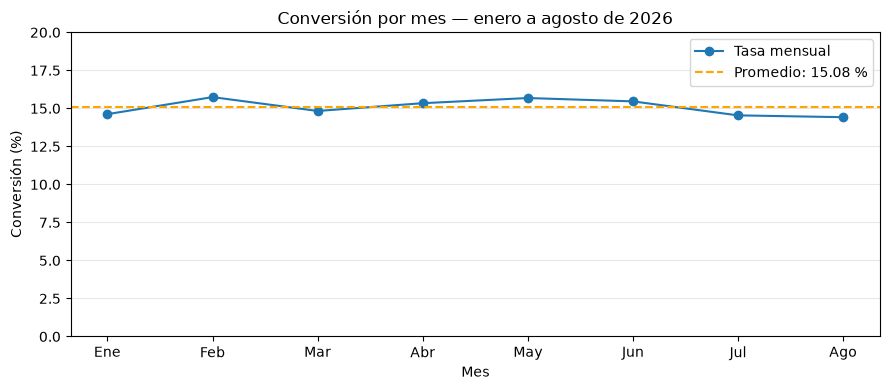

In [7]:
import matplotlib.pyplot as plt

meses = ["Ene", "Feb", "Mar", "Abr", "May", "Jun", "Jul", "Ago"]
promedio = desarrollo["objetivo"].mean() * 100

fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(
    meses,
    objetivo_por_mes["tasa_porcentaje"],
    marker="o",
    label="Tasa mensual",
)

ax.axhline(
    promedio,
    color="orange",
    linestyle="--",
    label=f"Promedio: {promedio:.2f} %",
)

ax.set(
    title="Conversión por mes — enero a agosto de 2026",
    xlabel="Mes",
    ylabel="Conversión (%)",
    ylim=(0, 20),
)

ax.grid(axis="y", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

In [8]:
inventario_eda = pd.DataFrame({
    "variable": desarrollo.columns,
    "tipo_pandas": desarrollo.dtypes.astype(str).to_numpy(),
    "valores_distintos": desarrollo.nunique().to_numpy(),
    "nulos": desarrollo.isna().sum().to_numpy(),
})

roles = {
    "id_cliente": "Identificador",
    "mes": "Temporal",
    "objetivo": "Objetivo",
}

inventario_eda["rol"] = (
    inventario_eda["variable"]
    .map(roles)
    .fillna("Predictor candidato")
)

# Incorporar el tipo indicado en la documentación oficial.
inventario_eda = inventario_eda.merge(
    metadata[["column_name", "type"]].rename(columns={
        "column_name": "variable",
        "type": "tipo_documentado",
    }),
    on="variable",
    how="left",
    validate="one_to_one",
)

display(inventario_eda)

,variable,tipo_pandas,valores_distintos,nulos,rol,tipo_documentado
0,id_cliente,int64,20708,0,Identificador,int
1,mes,int64,8,0,Temporal,int
2,edad,int64,50,0,Predictor candidato,int
3,ingresos,float64,20379,0,Predictor candidato,float
4,ratio_deuda_ingresos,float64,20670,0,Predictor candidato,float
5,antiguedad_cuenta_meses,int64,179,0,Predictor candidato,int
6,numero_productos,int64,5,0,Predictor candidato,int
7,saldo_promedio,float64,19329,0,Predictor candidato,float
8,dias_ultima_transaccion,int64,364,0,Predictor candidato,int
9,ocupacion,str,5,0,Predictor candidato,string


### Criterios comunes para comparar variables

Las funciones siguientes calculan tablas descriptivas y crean gráficos reutilizables; no preparan entradas de un modelo. Cada agrupación se obtiene una sola vez con enero–agosto y se aplica sin cambios a los ocho meses. Se mantienen los cortes ya usados para edad y antigüedad de cuenta. Para las otras variables continuas se emplean cuantiles con eliminación de límites duplicados; los empates pueden producir tamaños distintos. Productos, visitas web y día de pago se estudian por valor exacto.

Las tablas incluyen observaciones, conversiones y tasas. Los límites matemáticos se muestran con su cierre: el primer intervalo incluye ambos extremos y los restantes excluyen el inferior e incluyen el superior. Los mínimos y máximos observados no sustituyen esos límites. Las barras de conversión usan grupos como categorías: su ancho visual no representa la amplitud del intervalo. Los histogramas utilizan intervalos de igual amplitud.

La estabilidad se describe mediante mínimos, máximos y rangos mensuales, sin un umbral automático para declarar una variable estable. Una tasa ausente por falta de observaciones se conserva como `NaN`; nunca se convierte en cero. Los clientes únicos por grupo no siempre son sumables, porque un cliente puede cambiar de grupo. Las revisiones de texto no cambian las categorías originales.

El registro se inicializa únicamente al crear `desarrollo`. Volver a ejecutar esta celda de funciones conserva las entradas ya calculadas. Cada sección registra sus resultados; el cierre comprueba ausentes y adicionales y completa cualquier cálculo faltante con los grupos previos disponibles.


In [9]:
%matplotlib inline
from IPython.display import display, HTML
import unicodedata

numericas_eda = [
    'edad', 'ingresos', 'ratio_deuda_ingresos', 'antiguedad_cuenta_meses',
    'numero_productos', 'saldo_promedio', 'dias_ultima_transaccion',
    'antiguedad_direccion_meses', 'visitas_web_ultimos_90_dias',
    'distancia_sucursal_km', 'dia_preferido_pago', 'dias_ultima_interaccion',
]
categoricas_eda = ['ocupacion', 'region', 'canal_adquisicion', 'banda_riesgo',
                   'dispositivo_principal']
booleanas_eda = ['tiene_tarjeta_credito', 'activo_movil', 'es_nuevo_cliente',
                 'tiene_prestamo', 'tiene_seguro']
predictores_eda = numericas_eda + categoricas_eda + booleanas_eda
assert len(predictores_eda) == len(set(predictores_eda)) == 22
assert set(predictores_eda) == set(desarrollo.columns) - {'id_cliente', 'mes', 'objetivo'}
assert set(desarrollo['mes']) == set(range(202601, 202609))
meses_eda = sorted(desarrollo['mes'].unique())


def grupos_numericos(variable):
    """Límites únicos del desarrollo completo; nunca se recalculan por mes."""
    s = desarrollo[variable]
    if variable in ['numero_productos', 'visitas_web_ultimos_90_dias', 'dia_preferido_pago']:
        valores = sorted(s.dropna().unique())
        grupo = pd.Series(pd.Categorical(s, categories=valores, ordered=True), index=s.index)
        limites = pd.DataFrame({'grupo': valores, 'limite_inferior': valores,
                                'limite_superior': valores, 'cierre': 'valor exacto'})
    else:
        if variable == 'edad':
            bordes = np.array([-np.inf, 29, 39, 49, 59, np.inf])
            etiquetas = ['Hasta 29', '30–39', '40–49', '50–59', '60 o más']
        elif variable == 'antiguedad_cuenta_meses':
            bordes = np.array([-np.inf, 12, 36, 60, 120, np.inf])
            etiquetas = ['Hasta 12 meses', '13–36 meses', '37–60 meses',
                         '61–120 meses', 'Más de 120 meses']
        else:
            # duplicates='drop' permite empates sin forzar cinco grupos.
            _, bordes = pd.qcut(s.dropna(), q=5, retbins=True, duplicates='drop')
            if len(bordes) < 2:
                grupo = pd.Series(pd.Categorical(s, categories=sorted(s.unique())), index=s.index)
                limites = pd.DataFrame({'grupo': sorted(s.unique()),
                                        'limite_inferior': sorted(s.unique()),
                                        'limite_superior': sorted(s.unique()), 'cierre': 'valor exacto'})
                return grupo, limites
            etiquetas = [f'Q{i + 1}' for i in range(len(bordes) - 1)]
        grupo = pd.cut(s, bins=bordes, labels=etiquetas, include_lowest=True, right=True)
        limites = pd.DataFrame({'grupo': etiquetas, 'limite_inferior': bordes[:-1],
                                'limite_superior': bordes[1:],
                                'cierre': ['[inferior, superior]'] + ['(inferior, superior]'] * (len(etiquetas) - 1)})
    assert grupo.notna().all(), f'Valores sin grupo: {variable}'
    return grupo, limites


def registrar_analisis(variable, numerica=True, grupo_existente=None):
    s = desarrollo[variable]
    if grupo_existente is not None:
        # Conservar las asignaciones y etiquetas de la sección ya calculada.
        assert numerica, "Los grupos previos se usan para las numéricas."
        assert grupo_existente.index.equals(s.index), "Índices de grupos y desarrollo distintos."
        assert isinstance(grupo_existente.dtype, pd.CategoricalDtype)
        assert grupo_existente.notna().all(), "Hay filas sin grupo previo."
        grupo_referencia, limites = grupos_numericos(variable)
        assert grupo_existente.cat.codes.equals(grupo_referencia.cat.codes), "Los límites previos no corresponden a este desarrollo."
        grupo = grupo_existente.copy()
        # Los bordes se comprueban con el desarrollo; nunca reasignamos sus filas.
        limites = limites.copy()
        limites["grupo"] = list(grupo.cat.categories)
    elif numerica:
        grupo, limites = grupos_numericos(variable)
    else:
        categorias = sorted(s.dropna().unique())
        grupo = pd.Series(pd.Categorical(s, categories=categorias, ordered=True), index=s.index)
        # El marcador de ausentes es solo una etiqueta de visualización, no una imputación.
        if s.isna().any():
            grupo = grupo.cat.add_categories(['<AUSENTE>']).fillna('<AUSENTE>')
        limites = None
    tabla = desarrollo[['mes', 'id_cliente', 'objetivo', variable]].copy()
    tabla['grupo'] = grupo
    conversion = tabla.groupby('grupo', observed=False).agg(
        observaciones=('objetivo', 'size'), clientes_unicos=('id_cliente', 'nunique'),
        conversiones=('objetivo', 'sum'), tasa=('objetivo', 'mean'))
    conversion['porcentaje_observaciones'] = conversion['observaciones'] / len(tabla) * 100
    conversion['tasa_porcentaje'] = conversion['tasa'] * 100
    if numerica:
        extremos = tabla.groupby('grupo', observed=False)[variable].agg(
            minimo_observado='min', maximo_observado='max')
        conversion = conversion.join(extremos)
    mensual = tabla.groupby(['mes', 'grupo'], observed=False).agg(
        observaciones=('objetivo', 'size'), conversiones=('objetivo', 'sum'),
        tasa=('objetivo', 'mean'))
    tasas = mensual['tasa'].unstack('grupo').reindex(meses_eda) * 100
    conteos = mensual['observaciones'].unstack('grupo').reindex(meses_eda)
    conversiones = mensual['conversiones'].unstack('grupo').reindex(meses_eda)
    proporciones = conteos.div(desarrollo.groupby('mes').size(), axis=0) * 100
    estabilidad = pd.DataFrame({
        'observaciones_mes_min': conteos.min(), 'observaciones_mes_max': conteos.max(),
        'tasa_mes_min_pct': tasas.min(), 'tasa_mes_max_pct': tasas.max(),
        'rango_tasa_pp': tasas.max() - tasas.min(),
        'proporcion_mes_min_pct': proporciones.min(),
        'proporcion_mes_max_pct': proporciones.max(),
        'rango_proporcion_pp': proporciones.max() - proporciones.min(),
    })
    calidad = pd.Series({'nulos': s.isna().sum(), 'valores_distintos': s.nunique(),
                         'ceros': s.eq(0).sum() if numerica else np.nan,
                         'negativos': s.lt(0).sum() if numerica else np.nan}, name=variable)
    if numerica:
        calidad['observaciones_en_minimo'] = s.eq(s.min()).sum()
        calidad['observaciones_en_maximo'] = s.eq(s.max()).sum()
        if variable in ['numero_productos', 'visitas_web_ultimos_90_dias', 'dia_preferido_pago']:
            calidad['valores_no_enteros'] = s.dropna().mod(1).ne(0).sum()
        if variable == 'dia_preferido_pago':
            calidad['fuera_de_1_a_31'] = (~s.between(1, 31) & s.notna()).sum()
    r = dict(grupo=grupo, limites=limites, conversion=conversion, mensual=mensual,
             tasas=tasas, conteos=conteos, conversiones=conversiones,
             proporciones=proporciones, estabilidad=estabilidad, calidad=calidad)
    analisis_eda[variable] = r
    assert conversion['observaciones'].sum() == len(desarrollo)
    assert conversion['conversiones'].sum() == desarrollo['objetivo'].sum()
    assert conteos.sum(axis=1).eq(desarrollo.groupby('mes').size()).all()
    return r


def graficos_mensuales(variable):
    r = analisis_eda[variable]
    tasas = r['tasas'].copy()
    conteos = r['conteos'].copy()
    tasas.index = conteos.index = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago']
    ancho = 14 if len(tasas.columns) > 10 else 10
    fig, axes = plt.subplots(2, 1, figsize=(ancho, 7.5), constrained_layout=True)
    sns.heatmap(tasas, annot=True, fmt='.1f', cmap='YlOrRd', vmin=0,
                ax=axes[0], cbar_kws={'label': 'Conversión (%)'}, annot_kws={'size': 8})
    sns.heatmap(conteos, annot=True, fmt='d', cmap='Blues', vmin=0,
                ax=axes[1], cbar_kws={'label': 'Observaciones'}, annot_kws={'size': 8})
    axes[0].set_title(f'{variable}: conversión mensual por grupo fijo')
    axes[1].set_title('Tamaño de los mismos grupos: observaciones cliente-mes')
    for ax in axes:
        ax.set_xlabel('Grupo exploratorio / categoría')
        ax.set_ylabel('Mes de 2026')
        ax.tick_params(axis='x', rotation=45 if len(tasas.columns) > 10 else 0)
        ax.tick_params(axis='y', rotation=0)
    plt.show()


def completar_numerica(variable, nueva=False, grupo_existente=None):
    """Para las seis secciones previas muestra solamente lo que les faltaba."""
    r = registrar_analisis(variable, grupo_existente=grupo_existente)
    s = desarrollo[variable]
    if nueva:
        display(metadata.loc[metadata['column_name'].eq(variable)].T)
    if nueva or variable == 'numero_productos':
        display(s.describe(percentiles=[.01, .20, .25, .40, .50, .60, .75, .80, .99]).to_frame(variable))
    if nueva or variable in ['edad', 'numero_productos']:
        display(r['calidad'].to_frame('cantidad'))
    if nueva or variable in ['edad', 'antiguedad_cuenta_meses', 'numero_productos']:
        extremos = pd.DataFrame({'valor': [s.min(), s.max()],
                                'observaciones': [s.eq(s.min()).sum(), s.eq(s.max()).sum()]},
                                index=['Mínimo', 'Máximo'])
        extremos['porcentaje'] = extremos['observaciones'] / len(s) * 100
        display(extremos.round(3))
    # Se imprimen los bordes completos, no solo los extremos observados del grupo.
    with pd.option_context('display.precision', 15):
        display(r['limites'])
    if nueva:
        display(r['conversion'].drop(columns='tasa').round(3))
    if nueva or variable == 'numero_productos':
        fig, axes = plt.subplots(1, 2, figsize=(12 if s.nunique() <= 28 else 11, 4.5),
                                 constrained_layout=True)
        if variable in ['numero_productos', 'visitas_web_ultimos_90_dias', 'dia_preferido_pago']:
            frecuencias = s.value_counts().sort_index()
            axes[0].bar(frecuencias.index, frecuencias.values)
            axes[0].set_xticks(frecuencias.index[::1 if len(frecuencias) < 25 else 2])
        else:
            if variable in ['dias_ultima_transaccion', 'dias_ultima_interaccion']:
                bordes_hist = np.arange(.5, s.max() + 28.5, 28)
            elif variable == 'antiguedad_direccion_meses':
                bordes_hist = np.arange(.5, 253, 12)
            else:
                bordes_hist = np.linspace(s.min(), s.max(), 41)
            axes[0].hist(s, bins=bordes_hist, edgecolor='white')
        unidad_eje = {'dias_ultima_transaccion': 'Días desde la última transacción',
                     'dias_ultima_interaccion': 'Días desde la última interacción',
                     'antiguedad_direccion_meses': 'Antigüedad de dirección (meses)',
                     'distancia_sucursal_km': 'Distancia a sucursal (km)',
                     'visitas_web_ultimos_90_dias': 'Visitas web en los últimos 90 días',
                     'dia_preferido_pago': 'Día del mes',
                     'numero_productos': 'Productos activos'}
        axes[0].set(title=f'Distribución: {variable}', xlabel=unidad_eje.get(variable, 'Valor registrado'),
                    ylabel='Observaciones cliente-mes')
        tasas = r['conversion']['tasa_porcentaje']
        axes[1].bar(np.arange(len(tasas)), tasas.to_numpy())
        axes[1].set_xticks(np.arange(len(tasas)), [str(x) for x in tasas.index],
                          rotation=90 if len(tasas) > 10 else 0)
        axes[1].axhline(desarrollo['objetivo'].mean() * 100, color='darkorange',
                        linestyle='--', label='Tasa global de desarrollo')
        axes[1].set(title='Conversión por grupo / valor', xlabel='Grupo exploratorio',
                    ylabel='Conversión (%)', ylim=(0, max(20, tasas.max() * 1.15)))
        axes[1].legend(fontsize=8)
        plt.show()
    # Las tasas de las seis variables previas ya están visibles en sus celdas.
    if nueva:
        display(r['tasas'].round(2))
    if nueva or variable != 'numero_productos':
        display(r['conteos'])
    display(r['estabilidad'].round(3))
    if nueva:
        graficos_mensuales(variable)


def analizar_categorica(variable):
    r = registrar_analisis(variable, numerica=False)
    s = desarrollo[variable]
    display(metadata.loc[metadata['column_name'].eq(variable)].T)
    display(r['conversion'].drop(columns='tasa').round(3))
    if variable in booleanas_eda:
        control = pd.Series({'nulos': s.isna().sum(), 'tipo_pandas': str(s.dtype),
                             'fuera_de_True_False': (~s.isin([True, False]) & s.notna()).sum(),
                             'valores_no_booleanos_reales': s.dropna().map(lambda x: not isinstance(x, (bool, np.bool_))).sum()})
        display(control.to_frame('resultado'))
    else:
        originales = pd.Series(sorted(s.dropna().unique()), name='categoria_original')
        normalizadas = originales.map(lambda x: unicodedata.normalize('NFKC', str(x)).strip().casefold())
        revision = pd.DataFrame({'categoria_original': originales,
                                 'forma_para_revision': normalizadas,
                                 'espacios_en_extremos': originales.ne(originales.str.strip()),
                                 'vacia_tras_strip': originales.str.strip().eq(''),
                                 'colision_de_formas': normalizadas.duplicated(keep=False)})
        display(revision)
        print('Nulos:', s.isna().sum(), '| No hay catálogo oficial de categorías permitidas en metadata.')
    display(r['tasas'].round(2))
    display(r['conteos'])
    display(r['estabilidad'].round(3))
    fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
    etiquetas = [str(x) for x in r['conversion'].index]
    axes[0].barh(etiquetas, r['conversion']['observaciones'])
    axes[0].set(title=f'Frecuencias: {variable}', xlabel='Observaciones cliente-mes')
    axes[1].barh(etiquetas, r['conversion']['tasa_porcentaje'])
    axes[1].axvline(desarrollo['objetivo'].mean() * 100, color='darkorange', linestyle='--')
    axes[1].set(title='Conversión por categoría', xlabel='Conversión (%)',
                xlim=(0, max(20, r['conversion']['tasa_porcentaje'].max() * 1.15)))
    plt.show()
    graficos_mensuales(variable)


def completar_registros_eda():
    """Completar registros reales faltantes y comprobar los ya disponibles."""
    esperadas = set(predictores_eda)
    ausentes = sorted(esperadas - set(analisis_eda))
    adicionales = sorted(set(analisis_eda) - esperadas)
    print("Variables ausentes antes de completar:", ausentes)
    print("Variables adicionales:", adicionales)
    assert not adicionales, f"Hay claves ajenas a los predictores: {adicionales}"
    grupos_calculados = {
        "edad": edades["grupo_edad"],
        "ingresos": ingresos_eda["grupo_ingresos"],
        "ratio_deuda_ingresos": ratio_eda["grupo_ratio"],
        "antiguedad_cuenta_meses": antiguedad_eda["grupo_antiguedad"],
        "saldo_promedio": saldo_eda["grupo_saldo"],
    }
    for variable in predictores_eda:
        if variable not in analisis_eda:
            registrar_analisis(
                variable, numerica=variable in numericas_eda,
                grupo_existente=grupos_calculados.get(variable),
            )
    # Un registro anterior con etiquetas genéricas se actualiza con los grupos
    # originales de saldo, conservando todas las asignaciones cliente-mes.
    if not analisis_eda["saldo_promedio"]["grupo"].equals(saldo_eda["grupo_saldo"]):
        registrar_analisis("saldo_promedio", grupo_existente=saldo_eda["grupo_saldo"])
    r_saldo = analisis_eda["saldo_promedio"]
    pd.testing.assert_series_equal(r_saldo["grupo"], saldo_eda["grupo_saldo"])
    columnas_saldo = ["observaciones", "minimo_observado", "maximo_observado", "conversiones", "tasa"]
    conversion_original = conversion_por_saldo.rename(columns={
        "saldo_minimo": "minimo_observado", "saldo_maximo": "maximo_observado",
    })[columnas_saldo]
    pd.testing.assert_frame_equal(
        r_saldo["conversion"][columnas_saldo], conversion_original,
        check_names=False, check_exact=True,
    )
    pd.testing.assert_frame_equal(r_saldo["tasas"].round(2), tasas_saldo_mensuales, check_names=False)
    assert set(analisis_eda) == esperadas
    print("Registro completo:", len(analisis_eda), "variables; grupos y resultados de saldo conservados.")



### Análisis de edad

Preguntas:
- ¿Qué definición proporciona metadata?
- ¿Cuál es el rango observado?
- ¿Dónde se concentra la distribución?
- ¿Existen valores que requieren revisión?
- ¿Cómo se relaciona posteriormente con la conversión?

El análisis utiliza observaciones cliente-mes de enero–agosto.
Los clientes que aparecen en varios meses contribuyen varias veces.

,2
column_name,edad
description,Edad del cliente
type,int
notes,Variable numérica


,edad
count,80300.000000
mean,46.366451
std,14.331850
min,22.000000
1%,22.000000
25%,34.000000
50%,46.000000
75%,59.000000
99%,71.000000
max,71.000000


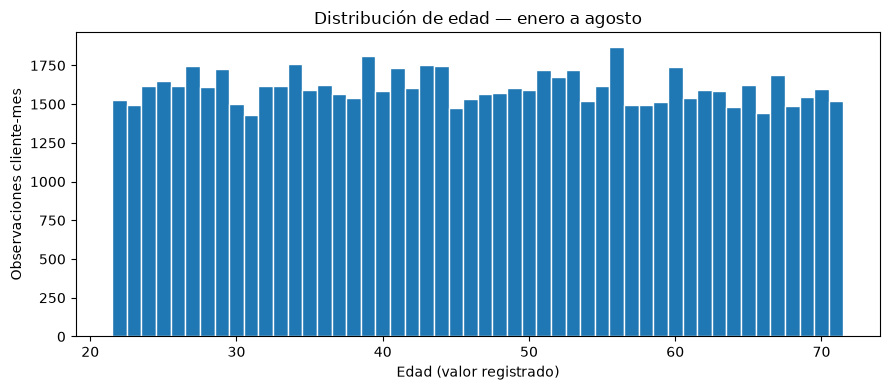

In [10]:
# Consultar la definición original.
display(
    metadata.loc[metadata["column_name"] == "edad"].T
)

# Resumen de la distribución.
resumen_edad = desarrollo["edad"].describe(
    percentiles=[0.01, 0.25, 0.50, 0.75, 0.99]
)

display(resumen_edad.to_frame("edad"))

# Visualizar la frecuencia de las edades.
fig, ax = plt.subplots(figsize=(9, 4))

ax.hist(
    desarrollo["edad"],
    bins=np.arange(
    desarrollo["edad"].min() - 0.5,
    desarrollo["edad"].max() + 1.5,
    1,
),
    edgecolor="white",
)

ax.set(
    title="Distribución de edad — enero a agosto",
    xlabel="Edad (valor registrado)",
    ylabel="Observaciones cliente-mes",
)

plt.tight_layout()
plt.show()

### Hallazgo 3: distribución de edad

La edad observada está entre 22 y 71, con media de 46,37
y mediana de 46. Los percentiles 25 y 75 son 34 y 59.

No se identifican edades evidentemente imposibles por su rango.
Estos límites son observados, no límites oficiales permitidos.

Se utiliza una barra por edad para evitar patrones visuales
producidos por intervalos que contienen distintas cantidades
de valores enteros.

La relación con conversión y su comportamiento mensual se revisan en las celdas siguientes.

In [11]:
edades = desarrollo[["edad", "objetivo"]].copy()

# Grupos exploratorios; todavía no son entradas del modelo.
edades["grupo_edad"] = pd.cut(
    edades["edad"],
    bins=[-np.inf, 29, 39, 49, 59, np.inf],
    labels=["Hasta 29", "30–39", "40–49", "50–59", "60 o más"],
)

conversion_por_edad = (
    edades.groupby("grupo_edad", observed=False)["objetivo"]
    .agg(observaciones="size", conversiones="sum", tasa="mean")
)

conversion_por_edad["tasa_porcentaje"] = (
    conversion_por_edad["tasa"] * 100
).round(2)

display(
    conversion_por_edad[
        ["observaciones", "conversiones", "tasa_porcentaje"]
    ]
)

,observaciones,conversiones,tasa_porcentaje
grupo_edad,,,
Hasta 29,12992,1873,14.42
30–39,16063,2451,15.26
40–49,16174,2433,15.04
50–59,16221,2460,15.17
60 o más,18850,2890,15.33


In [12]:
edad_por_mes = desarrollo[["mes", "edad", "objetivo"]].copy()

edad_por_mes["grupo_edad"] = pd.cut(
    edad_por_mes["edad"],
    bins=[-np.inf, 29, 39, 49, 59, np.inf],
    labels=["Hasta 29", "30–39", "40–49", "50–59", "60 o más"],
)

resumen_edad_mensual = (
    edad_por_mes.groupby(["mes", "grupo_edad"], observed=True)
    ["objetivo"]
    .agg(
        observaciones="size",
        conversiones="sum",
        tasa="mean",
    )
    .reset_index()
)

tasas_edad_mensuales = (
    resumen_edad_mensual
    .pivot(index="mes", columns="grupo_edad", values="tasa")
    .mul(100)
    .round(2)
)

display(tasas_edad_mensuales)

grupo_edad,Hasta 29,30–39,40–49,50–59,60 o más
mes,,,,,
202601,14.04,15.03,13.33,14.99,15.47
202602,14.15,16.12,16.19,16.46,15.52
202603,14.61,14.75,15.92,14.20,14.63
202604,15.85,14.54,15.35,15.42,15.60
202605,14.55,16.34,14.46,16.53,16.19
202606,13.92,16.44,15.60,15.08,15.88
202607,13.52,14.51,15.29,13.83,15.23
202608,14.73,14.26,14.24,14.82,14.13


#### Comprobaciones complementarias

Completamos las verificaciones ausentes y mostramos los límites exactos de los grupos y sus tamaños mensuales. El rango de tasas describe variación; el rango de proporciones distingue cambios de composición de cambios en el total de filas del mes. Conservamos las agrupaciones y resultados anteriores.

In [13]:
completar_numerica("edad")

,cantidad
nulos,0
valores_distintos,50
ceros,0
negativos,0
observaciones_en_minimo,1524
observaciones_en_maximo,1523


,valor,observaciones,porcentaje
Mínimo,22,1524,1.898
Máximo,71,1523,1.897


,grupo,limite_inferior,limite_superior,cierre
0,Hasta 29,-inf,29.0,"[inferior, superior]"
1,30–39,29.0,39.0,"(inferior, superior]"
2,40–49,39.0,49.0,"(inferior, superior]"
3,50–59,49.0,59.0,"(inferior, superior]"
4,60 o más,59.0,inf,"(inferior, superior]"


grupo,Hasta 29,30–39,40–49,50–59,60 o más
mes,,,,,
202601,1645,2082,2115,2088,2470
202602,1576,1942,2013,1975,2294
202603,1670,2041,2092,2070,2427
202604,1565,1885,1922,1959,2269
202605,1629,2032,1998,2057,2384
202606,1674,2104,2064,2096,2412
202607,1583,1951,1955,1959,2252
202608,1650,2026,2015,2017,2342


,observaciones_mes_min,observaciones_mes_max,tasa_mes_min_pct,tasa_mes_max_pct,rango_tasa_pp,proporcion_mes_min_pct,proporcion_mes_max_pct,rango_proporcion_pp
grupo,,,,,,,,
Hasta 29,1565,1674,13.519,15.847,2.328,15.817,16.418,0.601
30–39,1885,2104,14.265,16.445,2.180,19.635,20.329,0.693
40–49,1922,2115,13.333,16.195,2.861,19.782,20.541,0.759
50–59,1959,2096,13.834,16.529,2.695,20.070,20.406,0.337
60 o más,2252,2470,14.133,16.191,2.058,23.216,23.750,0.534


### Conclusión exploratoria de edad

En enero–agosto, la edad registrada va de 22 a 71 y no presenta
valores nulos. La conversión por grupo oscila entre 14,42 % y
15,33 % en el agregado, pero el orden entre grupos cambia por mes.

No se observa una relación creciente consistente entre edad y
conversión. Se conserva edad como variable numérica candidata;
su aporte se evaluará mediante validación temporal. Los grupos
se utilizaron únicamente para el análisis exploratorio.

La diferencia agregada entre 60 o más y hasta 29 es de 0,92 puntos porcentuales. Los grupos reúnen entre 12.992 y 18.850 observaciones; el menor conteo grupo-mes es 1.565. Sus proporciones mensuales varían como máximo 0,76 puntos porcentuales. La unidad de edad no figura explícitamente en metadata y debe confirmarse, junto con la fecha de medición y su disponibilidad al predecir.


### Análisis de `ingresos`

Revisamos ingresos anuales, su concentración en el mínimo y la conversión por quintiles. La moneda no está especificada. Todos los resultados exploratorios usan enero–agosto.

In [14]:
display(
    metadata.loc[metadata["column_name"] == "ingresos"].T
)

display(
    desarrollo["ingresos"]
    .describe(percentiles=[0.01, 0.25, 0.50, 0.75, 0.99])
    .to_frame(name="ingresos")
)

display(pd.Series({
    "nulos": desarrollo["ingresos"].isna().sum(),
    "ceros": desarrollo["ingresos"].eq(0).sum(),
    "negativos": desarrollo["ingresos"].lt(0).sum(),
}, name="cantidad"))

,3
column_name,ingresos
description,Ingresos anuales
type,float
notes,Variable numérica


,ingresos
count,80300.000000
mean,65165.820327
std,21790.673900
min,18000.000000
1%,18000.000000
25%,50125.508810
50%,64848.490657
75%,79752.701004
99%,116436.923972
max,145700.072671


nulos        0
ceros        0
negativos    0
Name: cantidad, dtype: int64

valor_minimo               18000.00
observaciones_en_minimo     1310.00
porcentaje_en_minimo           1.63
dtype: float64

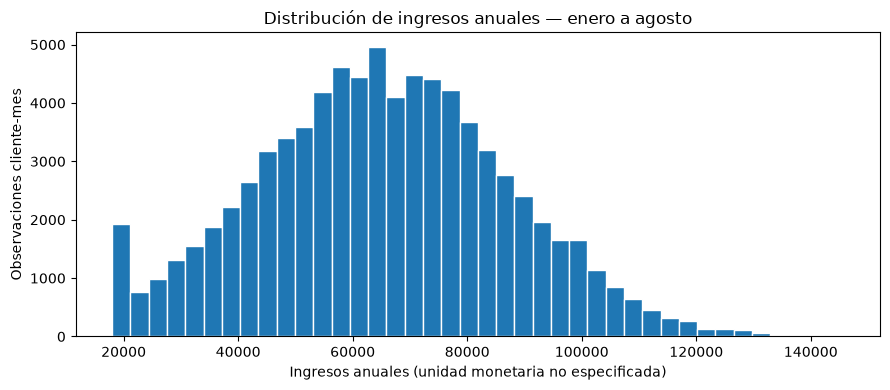

In [15]:
minimo_ingresos = desarrollo["ingresos"].min()
en_minimo = desarrollo["ingresos"].eq(minimo_ingresos)

display(pd.Series({
    "valor_minimo": minimo_ingresos,
    "observaciones_en_minimo": en_minimo.sum(),
    "porcentaje_en_minimo": round(en_minimo.mean() * 100, 2),
}))

fig, ax = plt.subplots(figsize=(9, 4))

ax.hist(desarrollo["ingresos"], bins=40, edgecolor="white")
ax.set_title("Distribución de ingresos anuales — enero a agosto")
ax.set_xlabel("Ingresos anuales (unidad monetaria no especificada)")
ax.set_ylabel("Observaciones cliente-mes")

plt.tight_layout()
plt.show()

In [16]:
ingresos_eda = desarrollo[["mes", "ingresos", "objetivo"]].copy()

ingresos_eda["grupo_ingresos"] = pd.qcut(
    ingresos_eda["ingresos"],
    q=5,
    labels=["Q1: bajos", "Q2", "Q3", "Q4", "Q5: altos"],
)

conversion_por_ingresos = (
    ingresos_eda.groupby("grupo_ingresos", observed=True)
    .agg(
        observaciones=("objetivo", "size"),
        ingreso_minimo=("ingresos", "min"),
        ingreso_maximo=("ingresos", "max"),
        conversiones=("objetivo", "sum"),
        tasa=("objetivo", "mean"),
    )
)

conversion_por_ingresos["tasa_porcentaje"] = (
    conversion_por_ingresos["tasa"] * 100
).round(2)

display(conversion_por_ingresos.drop(columns="tasa"))

,observaciones,ingreso_minimo,ingreso_maximo,conversiones,tasa_porcentaje
grupo_ingresos,,,,,
Q1: bajos,16060,18000.000000,46270.477451,2385,14.85
Q2,16065,46274.272887,59393.970499,2395,14.91
Q3,16057,59394.810532,70860.665276,2441,15.20
Q4,16061,70864.139698,83461.863849,2417,15.05
Q5: altos,16057,83462.270152,145700.072671,2469,15.38


In [17]:
tasas_ingresos_mensuales = (
    ingresos_eda
    .groupby(["mes", "grupo_ingresos"], observed=True)["objetivo"]
    .mean()
    .unstack("grupo_ingresos")
    .mul(100)
    .round(2)
)

display(tasas_ingresos_mensuales)


grupo_ingresos,Q1: bajos,Q2,Q3,Q4,Q5: altos
mes,,,,,
202601,14.63,14.77,14.72,14.33,14.66
202602,15.48,15.05,16.67,16.46,15.09
202603,13.85,15.93,15.48,13.54,15.31
202604,16.18,15.40,15.41,15.21,14.50
202605,15.60,14.95,15.15,16.05,16.67
202606,14.03,16.11,16.71,15.13,15.29
202607,15.29,13.24,13.95,13.70,16.45
202608,13.88,13.68,13.51,15.98,15.03


#### Comprobaciones complementarias

Completamos las verificaciones ausentes y mostramos los límites exactos de los grupos y sus tamaños mensuales. El rango de tasas describe variación; el rango de proporciones distingue cambios de composición de cambios en el total de filas del mes. Conservamos las agrupaciones y resultados anteriores.

In [18]:
completar_numerica("ingresos")

,grupo,limite_inferior,limite_superior,cierre
0,Q1,18000.000000000000000,46273.513800042135699,"[inferior, superior]"
1,Q2,46273.513800042135699,59393.970499366820150,"(inferior, superior]"
2,Q3,59393.970499366820150,70860.665276263694977,"(inferior, superior]"
3,Q4,70860.665276263694977,83461.863848763256101,"(inferior, superior]"
4,Q5,83461.863848763256101,145700.072671157773584,"(inferior, superior]"


grupo,Q1,Q2,Q3,Q4,Q5
mes,,,,,
202601,2098,2113,2058,2058,2073
202602,1951,1974,1944,1956,1975
202603,2065,2078,2048,2039,2070
202604,1947,1928,1901,1920,1904
202605,1994,2034,2013,2031,2028
202606,2053,2061,2094,2075,2067
202607,1956,1903,1942,1942,1957
202608,1996,1974,2057,2040,1983


,observaciones_mes_min,observaciones_mes_max,tasa_mes_min_pct,tasa_mes_max_pct,rango_tasa_pp,proporcion_mes_min_pct,proporcion_mes_max_pct,rango_proporcion_pp
grupo,,,,,,,,
Q1,1947,2098,13.850,16.179,2.329,19.743,20.281,0.539
Q2,1903,2113,13.242,16.109,2.866,19.619,20.317,0.699
Q3,1901,2094,13.515,16.714,3.200,19.788,20.468,0.679
Q4,1920,2075,13.536,16.462,2.926,19.788,20.299,0.510
Q5,1904,2073,14.496,16.667,2.171,19.731,20.175,0.444


### Conclusión exploratoria de ingresos

Los ingresos anuales no presentan nulos, ceros ni negativos en
enero–agosto. Se observan 1 310 registros en el mínimo de 18 000
(1,63 %); la documentación revisada no explica esa concentración.

La conversión agregada va de 14,85 % en Q1 a 15,38 % en Q5,
pero el orden entre grupos cambia por mes. No se observa una
relación creciente consistente.

Se conserva ingresos como variable numérica candidata, sin
recortar ni transformar por ahora. Su aporte al modelo se
evaluará mediante validación temporal.

La diferencia Q5−Q1 es de 0,53 puntos porcentuales. Los quintiles tienen entre 16.057 y 16.065 observaciones y al menos 1.901 por grupo-mes; sus proporciones varían como máximo 0,70 puntos porcentuales. Quedan pendientes la moneda, la definición de ingresos anuales (declarados, estimados o efectivamente percibidos), la fecha de actualización y la explicación del mínimo registrado.


### Análisis de `ratio_deuda_ingresos`

Examinamos la distribución del ratio y la conversión por quintiles, sin interpretar los cortes como umbrales de negocio. Todos los resultados exploratorios usan enero–agosto.

In [19]:
variable = "ratio_deuda_ingresos"

display(
    metadata.loc[metadata["column_name"] == variable].T
)

display(
    desarrollo[variable]
    .describe(percentiles=[0.01, 0.25, 0.50, 0.75, 0.99])
    .to_frame(name=variable)
)

display(pd.Series({
    "nulos": desarrollo[variable].isna().sum(),
    "ceros": desarrollo[variable].eq(0).sum(),
    "negativos": desarrollo[variable].lt(0).sum(),
}, name="cantidad"))

,4
column_name,ratio_deuda_ingresos
description,Ratio de deuda sobre ingresos
type,float
notes,Variable numérica


,ratio_deuda_ingresos
count,80300.000000
mean,0.328816
std,0.166598
min,0.020000
1%,0.044192
25%,0.201228
50%,0.309806
75%,0.437230
99%,0.771600
max,0.950000


nulos        0
ceros        0
negativos    0
Name: cantidad, dtype: int64

,valor,observaciones
Mínimo,0.02,112
Máximo,0.95,22


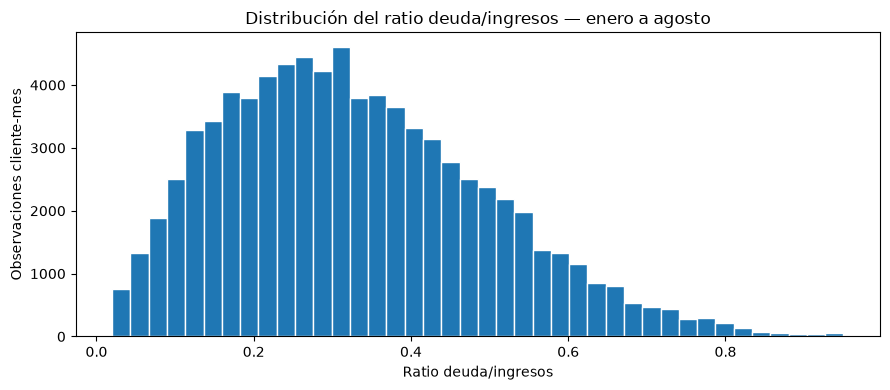

In [20]:
ratio = desarrollo["ratio_deuda_ingresos"]

display(pd.DataFrame({
    "valor": [ratio.min(), ratio.max()],
    "observaciones": [
        ratio.eq(ratio.min()).sum(),
        ratio.eq(ratio.max()).sum(),
    ],
}, index=["Mínimo", "Máximo"]))

fig, ax = plt.subplots(figsize=(9, 4))

ax.hist(ratio, bins=40, edgecolor="white")
ax.set_title("Distribución del ratio deuda/ingresos — enero a agosto")
ax.set_xlabel("Ratio deuda/ingresos")
ax.set_ylabel("Observaciones cliente-mes")

plt.tight_layout()
plt.show()

In [21]:
ratio_eda = desarrollo[
    ["mes", "ratio_deuda_ingresos", "objetivo"]
].copy()

ratio_eda["grupo_ratio"] = pd.qcut(
    ratio_eda["ratio_deuda_ingresos"],
    q=5,
    labels=["Q1: bajo", "Q2", "Q3", "Q4", "Q5: alto"],
)

conversion_por_ratio = (
    ratio_eda.groupby("grupo_ratio", observed=True)
    .agg(
        observaciones=("objetivo", "size"),
        ratio_minimo=("ratio_deuda_ingresos", "min"),
        ratio_maximo=("ratio_deuda_ingresos", "max"),
        conversiones=("objetivo", "sum"),
        tasa=("objetivo", "mean"),
    )
)

conversion_por_ratio["tasa_porcentaje"] = (
    conversion_por_ratio["tasa"] * 100
).round(2)

display(conversion_por_ratio.drop(columns="tasa"))

,observaciones,ratio_minimo,ratio_maximo,conversiones,tasa_porcentaje
grupo_ratio,,,,,
Q1: bajo,16061,0.020000,0.177098,2471,15.39
Q2,16059,0.177110,0.266853,2443,15.21
Q3,16062,0.266854,0.356321,2470,15.38
Q4,16064,0.356323,0.471584,2467,15.36
Q5: alto,16054,0.471651,0.950000,2256,14.05


In [22]:
tasas_ratio_mensuales = (
    ratio_eda
    .groupby(["mes", "grupo_ratio"], observed=True)["objetivo"]
    .mean()
    .unstack("grupo_ratio")
    .mul(100)
    .round(2)
)

display(tasas_ratio_mensuales)

grupo_ratio,Q1: bajo,Q2,Q3,Q4,Q5: alto
mes,,,,,
202601,15.35,14.49,13.96,14.64,14.70
202602,15.93,15.97,15.65,16.43,14.71
202603,14.76,15.83,14.79,15.05,13.66
202604,15.10,15.72,16.03,15.95,13.92
202605,16.11,15.54,16.36,15.26,15.16
202606,15.57,15.38,15.36,16.19,14.80
202607,15.26,15.20,15.98,15.08,11.22
202608,15.00,13.58,15.04,14.30,14.18


#### Comprobaciones complementarias

Completamos las verificaciones ausentes y mostramos los límites exactos de los grupos y sus tamaños mensuales. El rango de tasas describe variación; el rango de proporciones distingue cambios de composición de cambios en el total de filas del mes. Conservamos las agrupaciones y resultados anteriores.

In [23]:
completar_numerica("ratio_deuda_ingresos")

,grupo,limite_inferior,limite_superior,cierre
0,Q1,0.020000000000000,0.177097874338789,"[inferior, superior]"
1,Q2,0.177097874338789,0.266853159146786,"(inferior, superior]"
2,Q3,0.266853159146786,0.356320650978852,"(inferior, superior]"
3,Q4,0.356320650978852,0.471584085941578,"(inferior, superior]"
4,Q5,0.471584085941578,0.950000000000000,"(inferior, superior]"


grupo,Q1,Q2,Q3,Q4,Q5
mes,,,,,
202601,2058,2146,2099,2076,2021
202602,1933,2035,1975,1954,1903
202603,2066,2104,2062,2040,2028
202604,1921,1921,1928,1912,1918
202605,2049,1989,1993,2031,2038
202606,2088,2016,2070,2088,2088
202607,1946,1882,1953,1949,1970
202608,2000,1966,1982,2014,2088


,observaciones_mes_min,observaciones_mes_max,tasa_mes_min_pct,tasa_mes_max_pct,rango_tasa_pp,proporcion_mes_min_pct,proporcion_mes_max_pct,rango_proporcion_pp
grupo,,,,,,,,
Q1,1921,2088,14.763,16.105,1.343,19.724,20.287,0.563
Q2,1882,2146,13.581,15.971,2.390,19.402,20.765,1.363
Q3,1928,2099,13.959,16.357,2.398,19.721,20.183,0.461
Q4,1912,2088,14.300,16.428,2.128,19.806,20.174,0.368
Q5,1903,2088,11.218,15.162,3.944,19.418,20.776,1.358


### Conclusión exploratoria del ratio deuda/ingresos

En enero–agosto, el ratio va de 0,02 a 0,95, sin nulos,
ceros ni negativos. Su distribución presenta una cola hacia
los valores altos.

Q5 tiene una conversión agregada de 14,05 %, frente al
15,39 % de Q1. Q5 queda por debajo de Q1 en los ocho meses
y presenta la menor tasa entre los cinco grupos en seis meses.

Se conserva la variable numérica como candidata. El patrón
se evaluará mediante validación temporal; no se establece
un umbral de negocio ni se recortan valores.

La diferencia Q1−Q5, calculada antes de redondear, es de 1,33 puntos porcentuales. Hay entre 16.054 y 16.064 observaciones por quintil y al menos 1.882 por grupo-mes; Q5 varía entre 11,22 % y 15,16 %. Sus proporciones mensuales tienen un rango máximo de 1,36 puntos porcentuales. Falta precisar los componentes de deuda e ingresos, su horizonte de cálculo y la disponibilidad del ratio antes del evento.


### Análisis de `antiguedad_cuenta_meses`

Comparamos antigüedad de cuenta y conversión con intervalos fijos en meses. Los intervalos tienen distintas amplitudes; sus conteos describen tamaños de grupo. Todos los resultados exploratorios usan enero–agosto.

In [24]:
variable = "antiguedad_cuenta_meses"

display(
    metadata.loc[metadata["column_name"] == variable].T
)

display(
    desarrollo[variable]
    .describe(percentiles=[0.01, 0.25, 0.50, 0.75, 0.99])
    .to_frame(name=variable)
)

display(pd.Series({
    "nulos": desarrollo[variable].isna().sum(),
    "ceros": desarrollo[variable].eq(0).sum(),
    "negativos": desarrollo[variable].lt(0).sum(),
}, name="cantidad"))

,5
column_name,antiguedad_cuenta_meses
description,Antigüedad de la cuenta del cliente en meses
type,int
notes,Variable numérica


,antiguedad_cuenta_meses
count,80300.000000
mean,89.075529
std,51.577984
min,1.000000
1%,2.000000
25%,44.000000
50%,89.000000
75%,133.000000
99%,178.000000
max,179.000000


nulos        0
ceros        0
negativos    0
Name: cantidad, dtype: int64

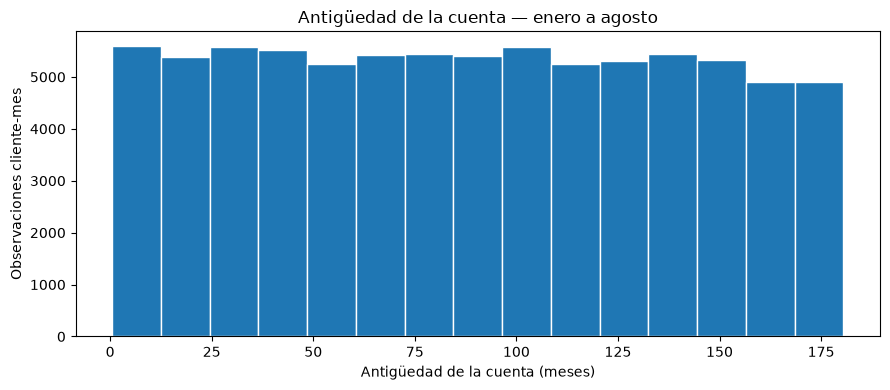

In [25]:
antiguedad = desarrollo["antiguedad_cuenta_meses"]

bordes = np.arange(
    0.5,
    antiguedad.max() + 12,
    12,
)

fig, ax = plt.subplots(figsize=(9, 4))

ax.hist(antiguedad, bins=bordes, edgecolor="white")
ax.set_title("Antigüedad de la cuenta — enero a agosto")
ax.set_xlabel("Antigüedad de la cuenta (meses)")
ax.set_ylabel("Observaciones cliente-mes")

plt.tight_layout()
plt.show()

In [26]:
antiguedad_eda = desarrollo[
    ["mes", "antiguedad_cuenta_meses", "objetivo"]
].copy()

antiguedad_eda["grupo_antiguedad"] = pd.cut(
    antiguedad_eda["antiguedad_cuenta_meses"],
    bins=[-np.inf, 12, 36, 60, 120, np.inf],
    labels=[
        "Hasta 12 meses",
        "13–36 meses",
        "37–60 meses",
        "61–120 meses",
        "Más de 120 meses",
    ],
)

conversion_por_antiguedad = (
    antiguedad_eda
    .groupby("grupo_antiguedad", observed=True)["objetivo"]
    .agg(
        observaciones="size",
        conversiones="sum",
        tasa="mean",
    )
)

conversion_por_antiguedad["tasa_porcentaje"] = (
    conversion_por_antiguedad["tasa"] * 100
).round(2)

display(conversion_por_antiguedad.drop(columns="tasa"))

,observaciones,conversiones,tasa_porcentaje
grupo_antiguedad,,,
Hasta 12 meses,5598,848,15.15
13–36 meses,10948,1577,14.40
37–60 meses,10767,1581,14.68
61–120 meses,27092,4061,14.99
Más de 120 meses,25895,4040,15.60


In [27]:
tasas_antiguedad_mensuales = (
    antiguedad_eda
    .groupby(["mes", "grupo_antiguedad"], observed=True)["objetivo"]
    .mean()
    .unstack("grupo_antiguedad")
    .mul(100)
    .round(2)
)

display(tasas_antiguedad_mensuales)

grupo_antiguedad,Hasta 12 meses,13–36 meses,37–60 meses,61–120 meses,Más de 120 meses
mes,,,,,
202601,15.17,14.19,15.49,14.05,14.91
202602,15.16,14.13,15.25,16.09,16.38
202603,15.05,15.37,13.39,14.24,15.73
202604,16.42,15.97,13.18,15.28,15.81
202605,16.15,14.21,15.46,15.96,16.00
202606,16.87,14.30,16.76,15.34,15.22
202607,12.93,14.38,13.47,14.42,15.53
202608,13.24,12.75,14.25,14.58,15.28


#### Comprobaciones complementarias

Completamos las verificaciones ausentes y mostramos los límites exactos de los grupos y sus tamaños mensuales. El rango de tasas describe variación; el rango de proporciones distingue cambios de composición de cambios en el total de filas del mes. Conservamos las agrupaciones y resultados anteriores.

In [28]:
completar_numerica("antiguedad_cuenta_meses")

,valor,observaciones,porcentaje
Mínimo,1,392,0.488
Máximo,179,452,0.563


,grupo,limite_inferior,limite_superior,cierre
0,Hasta 12 meses,-inf,12.0,"[inferior, superior]"
1,13–36 meses,12.0,36.0,"(inferior, superior]"
2,37–60 meses,36.0,60.0,"(inferior, superior]"
3,61–120 meses,60.0,120.0,"(inferior, superior]"
4,Más de 120 meses,120.0,inf,"(inferior, superior]"


grupo,Hasta 12 meses,13–36 meses,37–60 meses,61–120 meses,Más de 120 meses
mes,,,,,
202601,745,1374,1394,3494,3393
202602,686,1323,1279,3307,3205
202603,711,1412,1352,3468,3357
202604,664,1296,1290,3239,3111
202605,712,1358,1378,3439,3213
202606,735,1441,1414,3475,3285
202607,673,1356,1299,3274,3098
202608,672,1388,1361,3396,3233


,observaciones_mes_min,observaciones_mes_max,tasa_mes_min_pct,tasa_mes_max_pct,rango_tasa_pp,proporcion_mes_min_pct,proporcion_mes_max_pct,rango_proporcion_pp
grupo,,,,,,,,
Hasta 12 meses,664,745,12.927,16.871,3.944,6.687,7.163,0.477
13–36 meses,1296,1441,12.752,15.972,3.220,13.212,13.979,0.768
37–60 meses,1279,1414,13.178,16.761,3.583,13.051,13.662,0.611
61–120 meses,3239,3494,14.053,16.087,2.034,33.575,34.050,0.475
Más de 120 meses,3098,3393,14.913,16.381,1.468,31.739,32.704,0.965


### Conclusión exploratoria de antigüedad de la cuenta

En enero–agosto, la antigüedad va de 1 a 179 meses, con
mediana de 89 meses y sin nulos, ceros ni negativos.

La conversión agregada por grupo oscila entre 14,40 % y
15,60 %. Las cuentas de más de 120 meses presentan la mayor
tasa agregada y lideran en cuatro de los ocho meses.

El orden entre grupos cambia por mes. Se conserva la
antigüedad numérica como candidata, sin transformaciones;
su aporte se evaluará mediante validación temporal.

La amplitud agregada entre la mayor y menor tasa es de 1,20 puntos porcentuales. Hasta 12 meses reúne 5.598 observaciones (6,97 %) y entre 664 y 745 por mes; sus tasas van de 12,93 % a 16,87 %. La proporción mensual de cualquier grupo varía como máximo 0,97 puntos porcentuales. Falta confirmar el inicio del cómputo y la fecha de corte, además de la disponibilidad al predecir.


### Análisis de `numero_productos`

Analizamos cada cantidad real de productos activos: hay pocos valores distintos y no corresponde forzar quintiles. Todos los resultados exploratorios usan enero–agosto.

In [29]:
variable = "numero_productos"

display(
    metadata.loc[metadata["column_name"] == variable].T
)

frecuencias_productos = (
    desarrollo[variable]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis(variable)
    .to_frame(name="observaciones")
)

frecuencias_productos["porcentaje"] = (
    frecuencias_productos["observaciones"] / len(desarrollo) * 100
).round(2)

display(frecuencias_productos)

,6
column_name,numero_productos
description,Número de productos bancarios activos del cliente
type,int
notes,Variable numérica


,observaciones,porcentaje
numero_productos,,
1,36182,45.06
2,23468,29.23
3,12638,15.74
4,5336,6.65
5,2676,3.33


In [30]:
conversion_por_productos = (
    desarrollo.groupby("numero_productos")["objetivo"]
    .agg(
        observaciones="size",
        conversiones="sum",
        tasa="mean",
    )
)

conversion_por_productos["tasa_porcentaje"] = (
    conversion_por_productos["tasa"] * 100
).round(2)

display(conversion_por_productos.drop(columns="tasa"))

,observaciones,conversiones,tasa_porcentaje
numero_productos,,,
1,36182,4559,12.60
2,23468,3454,14.72
3,12638,2455,19.43
4,5336,1064,19.94
5,2676,575,21.49


In [31]:
resumen_productos_mensual = (
    desarrollo.groupby(["mes", "numero_productos"])["objetivo"]
    .agg(
        observaciones="size",
        conversiones="sum",
        tasa="mean",
    )
)

tasas_productos_mensuales = (
    resumen_productos_mensual["tasa"]
    .unstack("numero_productos")
    .mul(100)
    .round(2)
)

conteos_productos_mensuales = (
    resumen_productos_mensual["observaciones"]
    .unstack("numero_productos")
)

display(tasas_productos_mensuales)
display(conteos_productos_mensuales)

numero_productos,1,2,3,4,5
mes,,,,,
202601,11.36,13.99,19.10,21.18,21.78
202602,12.65,15.73,20.93,20.77,19.55
202603,12.44,15.04,18.96,18.50,17.20
202604,13.00,15.15,19.04,18.18,25.77
202605,13.24,14.85,20.09,21.63,24.53
202606,12.91,15.21,20.55,21.25,18.50
202607,12.35,14.14,18.33,19.93,23.00
202608,12.80,13.68,18.19,17.65,22.04


numero_productos,1,2,3,4,5
mes,,,,,
202601,4356,3037,1838,765,404
202602,4261,2873,1639,674,353
202603,4583,2999,1667,708,343
202604,4362,2778,1507,627,326
202605,4639,2895,1573,675,318
202606,4750,3031,1577,673,319
202607,4535,2872,1391,602,300
202608,4696,2983,1446,612,313


#### Comprobaciones complementarias

Completamos las verificaciones ausentes y mostramos los límites exactos de los grupos y sus tamaños mensuales. El rango de tasas describe variación; el rango de proporciones distingue cambios de composición de cambios en el total de filas del mes. Conservamos las agrupaciones y resultados anteriores.

,numero_productos
count,80300.000000
mean,1.939676
std,1.081700
min,1.000000
1%,1.000000
20%,1.000000
25%,1.000000
40%,1.000000
50%,2.000000
60%,2.000000


,cantidad
nulos,0
valores_distintos,5
ceros,0
negativos,0
observaciones_en_minimo,36182
observaciones_en_maximo,2676
valores_no_enteros,0


,valor,observaciones,porcentaje
Mínimo,1,36182,45.059
Máximo,5,2676,3.333


,grupo,limite_inferior,limite_superior,cierre
0,1,1,1,valor exacto
1,2,2,2,valor exacto
2,3,3,3,valor exacto
3,4,4,4,valor exacto
4,5,5,5,valor exacto


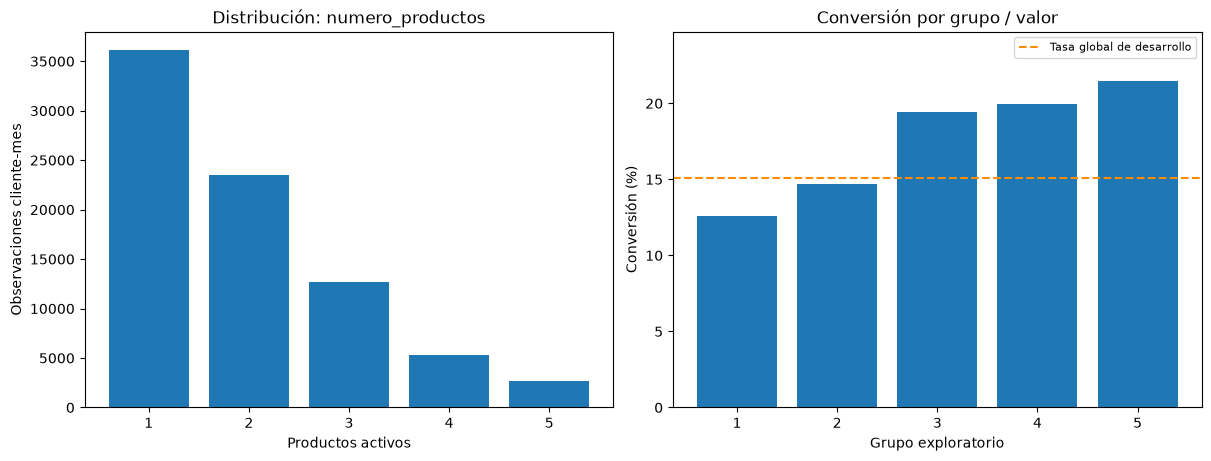

,observaciones_mes_min,observaciones_mes_max,tasa_mes_min_pct,tasa_mes_max_pct,rango_tasa_pp,proporcion_mes_min_pct,proporcion_mes_max_pct,rango_proporcion_pp
grupo,,,,,,,,
1,4261,4750,11.364,13.236,1.872,41.885,46.753,4.868
2,2778,3037,13.678,15.733,2.055,28.663,29.682,1.018
3,1391,1838,18.188,20.927,2.739,14.340,17.673,3.333
4,602,765,17.647,21.630,3.983,6.090,7.356,1.266
5,300,404,17.201,25.767,8.566,3.082,3.885,0.802


In [32]:
completar_numerica("numero_productos")

### Conclusión exploratoria del número de productos

En enero–agosto se observan entre 1 y 5 productos.
El 74,28 % de las observaciones corresponde a 1 o 2 productos.

La conversión agregada aumenta desde 12,60 % con un producto
hasta 21,49 % con cinco. En los ocho meses, los grupos con
3–5 productos superan a los de 1–2, aunque el aumento no es
estrictamente creciente dentro de cada mes.

Se conserva numero_productos como candidata. Su aporte se
evaluará mediante validación temporal. Queda pendiente
confirmar que su valor esté disponible al momento de predecir.

La diferencia entre cinco y un producto es de 8,89 puntos porcentuales. Cinco productos reúne 2.676 observaciones (3,33 %) y 300–404 por mes; su tasa mensual oscila entre 17,20 % y 25,77 %. La proporción con un producto varía de 41,88 % a 46,75 % (4,87 puntos porcentuales): el patrón de conversión convive con cambios de composición. Falta precisar qué productos se consideran activos y su fecha de corte.


### Análisis de `saldo_promedio`

Revisamos la distribución, los extremos y la conversión por quintiles. La moneda y el período del promedio siguen pendientes. Todos los resultados exploratorios usan enero–agosto.

In [33]:
variable = "saldo_promedio"

display(
    metadata.loc[metadata["column_name"] == variable].T
)

display(
    desarrollo[variable]
    .describe(percentiles=[0.01, 0.25, 0.50, 0.75, 0.99])
    .to_frame(name=variable)
)

display(pd.Series({
    "nulos": desarrollo[variable].isna().sum(),
    "ceros": desarrollo[variable].eq(0).sum(),
    "negativos": desarrollo[variable].lt(0).sum(),
}, name="cantidad"))

,7
column_name,saldo_promedio
description,Saldo promedio de la cuenta
type,float
notes,Variable numérica


,saldo_promedio
count,80300.000000
mean,26362.017452
std,16081.893553
min,300.000000
1%,300.000000
25%,14513.901875
50%,25767.603392
75%,37408.751650
99%,65575.102021
max,90000.000000


nulos        0
ceros        0
negativos    0
Name: cantidad, dtype: int64

,valor,observaciones,porcentaje
Mínimo,300.0,5491,6.84
Máximo,90000.0,1,0.00


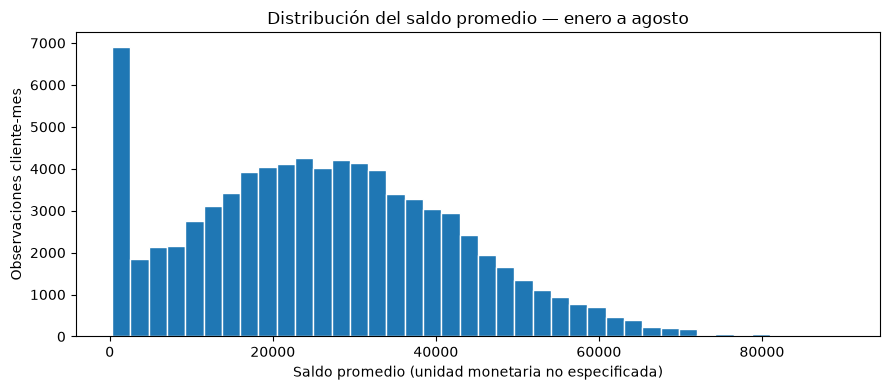

In [34]:
saldo = desarrollo["saldo_promedio"]

extremos_saldo = pd.DataFrame({
    "valor": [saldo.min(), saldo.max()],
    "observaciones": [
        saldo.eq(saldo.min()).sum(),
        saldo.eq(saldo.max()).sum(),
    ],
}, index=["Mínimo", "Máximo"])

extremos_saldo["porcentaje"] = (
    extremos_saldo["observaciones"] / len(desarrollo) * 100
).round(2)

display(extremos_saldo)

fig, ax = plt.subplots(figsize=(9, 4))

ax.hist(saldo, bins=40, edgecolor="white")
ax.set_title("Distribución del saldo promedio — enero a agosto")
ax.set_xlabel("Saldo promedio (unidad monetaria no especificada)")
ax.set_ylabel("Observaciones cliente-mes")

plt.tight_layout()
plt.show()

In [35]:
saldo_eda = desarrollo[["mes", "saldo_promedio", "objetivo"]].copy()

saldo_eda["grupo_saldo"] = pd.qcut(
    saldo_eda["saldo_promedio"],
    q=5,
    labels=["Q1: bajo", "Q2", "Q3", "Q4", "Q5: alto"],
)

conversion_por_saldo = (
    saldo_eda.groupby("grupo_saldo", observed=True)
    .agg(
        observaciones=("objetivo", "size"),
        saldo_minimo=("saldo_promedio", "min"),
        saldo_maximo=("saldo_promedio", "max"),
        conversiones=("objetivo", "sum"),
        tasa=("objetivo", "mean"),
    )
)

conversion_por_saldo["tasa_porcentaje"] = (
    conversion_por_saldo["tasa"] * 100
).round(2)

display(conversion_por_saldo.drop(columns="tasa"))

,observaciones,saldo_minimo,saldo_maximo,conversiones,tasa_porcentaje
grupo_saldo,,,,,
Q1: bajo,16060,300.000000,11763.818081,2406,14.98
Q2,16065,11765.332177,21459.663142,2338,14.55
Q3,16055,21459.681883,30080.387049,2349,14.63
Q4,16060,30080.664940,40194.634202,2483,15.46
Q5: alto,16060,40196.775740,90000.000000,2531,15.76


In [36]:
tasas_saldo_mensuales = (
    saldo_eda.groupby(
        ["mes", "grupo_saldo"],
        observed=True,
    )["objetivo"]
    .mean()
    .unstack("grupo_saldo")
    .mul(100)
    .round(2)
)

display(tasas_saldo_mensuales)

grupo_saldo,Q1: bajo,Q2,Q3,Q4,Q5: alto
mes,,,,,
202601,14.29,14.08,14.13,15.28,15.33
202602,16.33,14.32,16.12,16.16,15.78
202603,15.05,14.99,13.55,14.94,15.58
202604,14.69,15.80,13.50,16.06,16.67
202605,15.20,14.92,16.29,15.63,16.37
202606,15.20,15.01,15.45,16.47,15.16
202607,14.90,13.83,14.07,14.60,15.29
202608,14.24,13.51,13.86,14.55,15.96


#### Comprobaciones complementarias

Completamos las verificaciones ausentes y mostramos los límites exactos de los grupos y sus tamaños mensuales. El rango de tasas describe variación; el rango de proporciones distingue cambios de composición de cambios en el total de filas del mes. Conservamos las agrupaciones y resultados anteriores.

Para saldo se reutiliza exactamente `saldo_eda["grupo_saldo"]`, con sus etiquetas y asignaciones originales, al construir el registro completo de conversión, conteos, tasas, conversiones mensuales y estabilidad.


In [37]:
completar_numerica("saldo_promedio", grupo_existente=saldo_eda["grupo_saldo"])

,grupo,limite_inferior,limite_superior,cierre
0,Q1: bajo,300.000000000000000,11765.029358067266003,"[inferior, superior]"
1,Q2,11765.029358067266003,21459.663141542441736,"(inferior, superior]"
2,Q3,21459.663141542441736,30080.498205526233505,"(inferior, superior]"
3,Q4,30080.498205526233505,40195.062509625495295,"(inferior, superior]"
4,Q5: alto,40195.062509625495295,90000.000000000000000,"(inferior, superior]"


grupo,Q1: bajo,Q2,Q3,Q4,Q5: alto
mes,,,,,
202601,2093,2046,2066,2088,2107
202602,1966,1948,1966,1955,1965
202603,2040,2061,2045,2075,2079
202604,1906,1905,1933,1918,1938
202605,2020,2017,2063,2003,1997
202606,2059,2092,2065,2076,2058
202607,1946,1960,1933,1938,1923
202608,2030,2036,1984,2007,1993


,observaciones_mes_min,observaciones_mes_max,tasa_mes_min_pct,tasa_mes_max_pct,rango_tasa_pp,proporcion_mes_min_pct,proporcion_mes_max_pct,rango_proporcion_pp
grupo,,,,,,,,
Q1: bajo,1906,2093,14.236,16.328,2.091,19.806,20.199,0.393
Q2,1905,2092,13.507,15.801,2.294,19.673,20.259,0.586
Q3,1933,2066,13.502,16.287,2.785,19.741,20.426,0.684
Q4,1918,2088,14.549,16.474,1.925,19.832,20.146,0.314
Q5: alto,1923,2107,15.160,16.667,1.506,19.772,20.260,0.487


### Conclusión exploratoria del saldo promedio

En enero–agosto, el saldo promedio varía entre 300 y 90000.
El 6.84 % de las observaciones presenta un saldo de 300; esta
concentración se documenta sin asumir que constituye un error.

La conversión agregada varía entre 14.55 % y 15.76 %. El quintil
de mayor saldo presenta la mayor tasa en 6 de los 8 meses,
aunque no existe un aumento constante entre todos los quintiles.

Se conserva saldo_promedio como variable numérica candidata,
sin modificar sus extremos. Su aporte se evaluará mediante
validación temporal. Queda pendiente confirmar la moneda,
el período del promedio y su disponibilidad al predecir.

La amplitud agregada entre Q5 y Q2 es de 1,21 puntos porcentuales. Los quintiles contienen 16.055–16.065 observaciones y al menos 1.905 por grupo-mes; la proporción de cualquier quintil varía como máximo 0,68 puntos porcentuales. Q5−Q1 es positivo en seis meses, sin establecer una relación monotónica. La concentración en 300 requiere aclarar si existe un piso de registro; no se interpreta automáticamente como error.


### Análisis de `dias_ultima_transaccion`

Examinamos la recencia de la transacción: rango, distribución, conversión por grupos y comportamiento mensual. Los días son la unidad documentada. Todos los resultados exploratorios usan enero–agosto.

In [38]:
variable = "dias_ultima_transaccion"

display(
    metadata.loc[metadata["column_name"].eq(variable)]
)

display(
    desarrollo[variable].describe(
        percentiles=[0.01, 0.25, 0.50, 0.75, 0.99]
    )
)

display(
    pd.Series(
        {
            "nulos": desarrollo[variable].isna().sum(),
            "ceros": desarrollo[variable].eq(0).sum(),
            "negativos": desarrollo[variable].lt(0).sum(),
        },
        name=variable,
    )
)

,column_name,description,type,notes
8,dias_ultima_transaccion,Días desde la última transacción,int,Variable numérica


count    80300.000000
mean       189.050237
std        105.089339
min          1.000000
1%           4.000000
25%         99.000000
50%        192.000000
75%        281.000000
99%        361.000000
max        364.000000
Name: dias_ultima_transaccion, dtype: float64

nulos        0
ceros        0
negativos    0
Name: dias_ultima_transaccion, dtype: int64

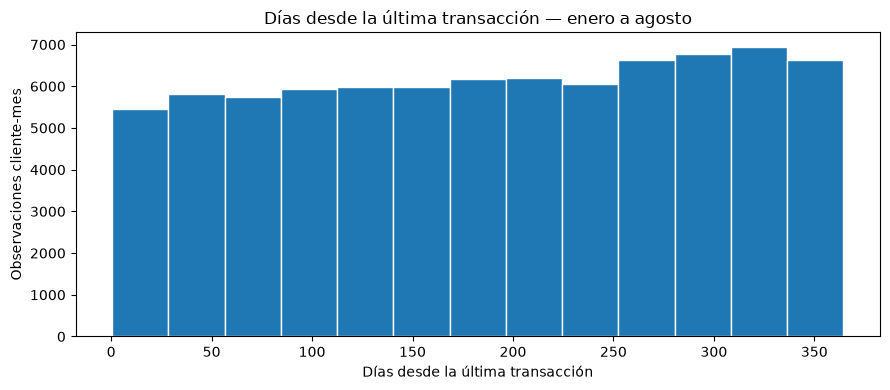

In [39]:
dias_transaccion = desarrollo["dias_ultima_transaccion"]

fig, ax = plt.subplots(figsize=(9, 4))

ax.hist(
    dias_transaccion,
    bins=np.arange(0.5, dias_transaccion.max() + 28.5, 28),
    edgecolor="white",
)

ax.set_title("Días desde la última transacción — enero a agosto")
ax.set_xlabel("Días desde la última transacción")
ax.set_ylabel("Observaciones cliente-mes")

plt.tight_layout()
plt.show()

#### Conversión y comportamiento mensual de `dias_ultima_transaccion`

El resumen y el histograma anteriores ya muestran rango y calidad. Ahora revisamos concentraciones en extremos, grupos fijos, diferencias de conversión y tamaños por mes.

,valor,observaciones,porcentaje
Mínimo,1,142,0.177
Máximo,364,260,0.324


,grupo,limite_inferior,limite_superior,cierre
0,Q1,1.0,80.0,"[inferior, superior]"
1,Q2,80.0,155.0,"(inferior, superior]"
2,Q3,155.0,228.0,"(inferior, superior]"
3,Q4,228.0,298.0,"(inferior, superior]"
4,Q5,298.0,364.0,"(inferior, superior]"


,observaciones,clientes_unicos,conversiones,porcentaje_observaciones,tasa_porcentaje,minimo_observado,maximo_observado
grupo,,,,,,,
Q1,16245,4552,2961,20.230,18.227,1,80
Q2,16027,4254,2618,19.959,16.335,81,155
Q3,15912,4089,2344,19.816,14.731,156,228
Q4,16096,3956,2149,20.045,13.351,229,298
Q5,16020,3857,2035,19.950,12.703,299,364


grupo,Q1,Q2,Q3,Q4,Q5
mes,,,,,
202601,16.61,15.71,14.89,13.14,12.38
202602,17.46,16.57,16.63,13.96,13.91
202603,18.67,16.25,14.43,12.75,11.72
202604,18.81,16.04,15.69,13.05,13.15
202605,18.02,18.14,14.42,14.26,13.65
202606,18.97,17.09,14.36,14.04,12.95
202607,18.97,15.92,13.48,12.80,11.79
202608,18.54,14.88,14.04,12.79,12.11


grupo,Q1,Q2,Q3,Q4,Q5
mes,,,,,
202601,2239,2151,2069,1987,1954
202602,2062,1998,1930,1891,1919
202603,2148,2098,2016,2016,2022
202604,1924,1933,1887,1924,1932
202605,1987,2018,1976,2068,2051
202606,2040,2042,2061,2122,2085
202607,1892,1865,1943,2016,1984
202608,1953,1922,2030,2072,2073


,observaciones_mes_min,observaciones_mes_max,tasa_mes_min_pct,tasa_mes_max_pct,rango_tasa_pp,proporcion_mes_min_pct,proporcion_mes_max_pct,rango_proporcion_pp
grupo,,,,,,,,
Q1,1892,2239,16.615,18.975,2.360,19.433,21.529,2.096
Q2,1865,2151,14.880,18.137,3.256,19.124,20.683,1.558
Q3,1887,2069,13.484,16.632,3.148,19.564,20.199,0.635
Q4,1891,2122,12.748,14.265,1.517,19.106,20.784,1.678
Q5,1919,2085,11.721,13.913,2.192,18.788,20.627,1.838


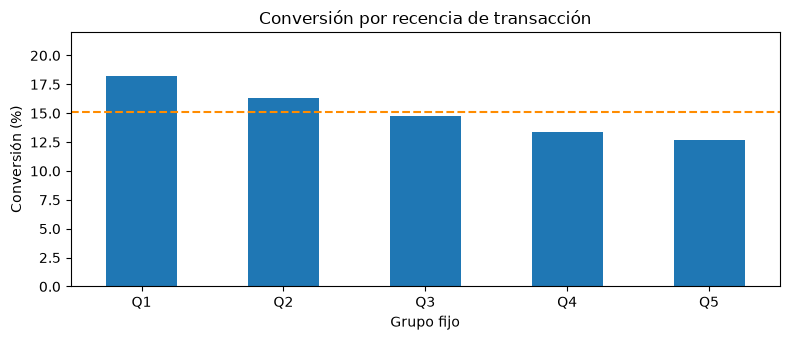

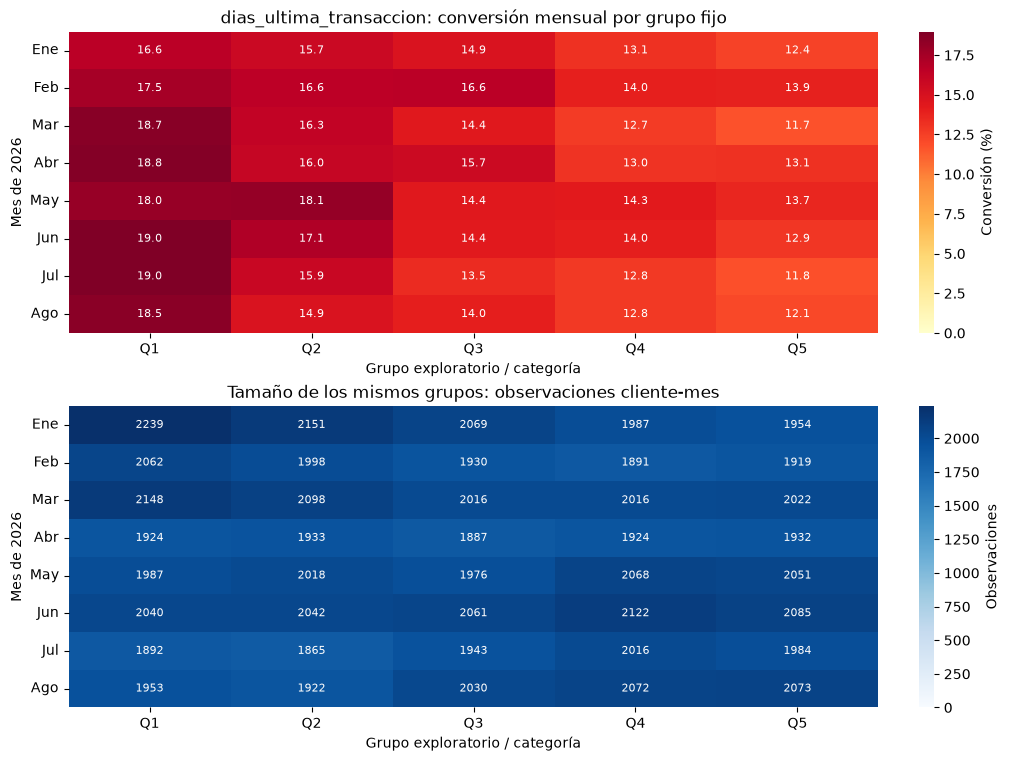

In [40]:
r_transaccion = registrar_analisis("dias_ultima_transaccion")
s = desarrollo["dias_ultima_transaccion"]
extremos_transaccion = pd.DataFrame({
    "valor": [s.min(), s.max()],
    "observaciones": [s.eq(s.min()).sum(), s.eq(s.max()).sum()],
}, index=["Mínimo", "Máximo"])
extremos_transaccion["porcentaje"] = extremos_transaccion["observaciones"] / len(s) * 100
display(extremos_transaccion.round(3))
display(r_transaccion["limites"])
display(r_transaccion["conversion"].drop(columns="tasa").round(3))
display(r_transaccion["tasas"].round(2))
display(r_transaccion["conteos"])
display(r_transaccion["estabilidad"].round(3))
fig, ax = plt.subplots(figsize=(8, 3.5))
r_transaccion["conversion"]["tasa_porcentaje"].plot.bar(ax=ax, rot=0)
ax.axhline(desarrollo["objetivo"].mean() * 100, color="darkorange", linestyle="--")
ax.set(title="Conversión por recencia de transacción", xlabel="Grupo fijo", ylabel="Conversión (%)", ylim=(0, 22))
plt.tight_layout()
plt.show()
graficos_mensuales("dias_ultima_transaccion")

### Conclusión exploratoria de `dias_ultima_transaccion`

Los días registrados van de 1 a 364, sin nulos, ceros ni negativos. Se corrigió el histograma previo: su último borde era 360,5 y omitía 914 observaciones de 361–364 días; ahora los intervalos de 28 días cubren todo el rango de 1–364 sin prolongar la última barra más allá del soporte observado. La mediana es 192 y los percentiles 25 y 75 se muestran en el resumen anterior. Los cinco grupos tienen 15.912–16.245 observaciones; los empates explican que no sean exactamente iguales.

La conversión disminuye en el agregado desde 18,23 % en 1–80 días hasta 12,70 % en 299–364 días: **5,52 puntos porcentuales**. El primer grupo supera al último en los ocho meses y el último tiene la menor tasa en siete; el descenso no es estrictamente ordenado entre todos los grupos de cada mes. Hay al menos 1.865 observaciones por grupo-mes y las proporciones varían como máximo 2,10 puntos porcentuales.

Se conserva la recencia como candidata sin imponer un umbral ni recortar valores. Falta confirmar qué transacciones se cuentan, la fecha de referencia y que ninguna operación posterior al instante de predicción intervenga en el cómputo. Su relación con la última interacción se examina en el cierre.

### Análisis de `antiguedad_direccion_meses`

Revisamos meses de antigüedad de dirección, distribución y conversión por cuantiles fijos, distinguiendo esta variable de antigüedad de cuenta. El bloque consulta metadata, calcula resumen, percentiles, calidad y límites de grupos; después muestra conversión y tamaños mensuales. Los mapas de calor usan los mismos grupos en los ocho meses; las tablas de estabilidad también muestran cambios de proporción dentro de cada mes.

,18
column_name,antiguedad_direccion_meses
description,Antigüedad de la dirección registrada en meses
type,int
notes,Variable numérica


,antiguedad_direccion_meses
count,80300.000000
mean,119.797186
std,68.794365
min,1.000000
1%,3.000000
20%,49.000000
25%,60.000000
40%,96.000000
50%,120.000000
60%,144.000000


,cantidad
nulos,0
valores_distintos,239
ceros,0
negativos,0
observaciones_en_minimo,334
observaciones_en_maximo,359


,valor,observaciones,porcentaje
Mínimo,1,334,0.416
Máximo,239,359,0.447


,grupo,limite_inferior,limite_superior,cierre
0,Q1,1.0,49.0,"[inferior, superior]"
1,Q2,49.0,96.0,"(inferior, superior]"
2,Q3,96.0,144.0,"(inferior, superior]"
3,Q4,144.0,191.0,"(inferior, superior]"
4,Q5,191.0,239.0,"(inferior, superior]"


,observaciones,clientes_unicos,conversiones,porcentaje_observaciones,tasa_porcentaje,minimo_observado,maximo_observado
grupo,,,,,,,
Q1,16311,4197,2438,20.313,14.947,1,49
Q2,16026,4146,2459,19.958,15.344,50,96
Q3,16024,4114,2399,19.955,14.971,97,144
Q4,16034,4096,2387,19.968,14.887,145,191
Q5,15905,4155,2424,19.807,15.240,192,239


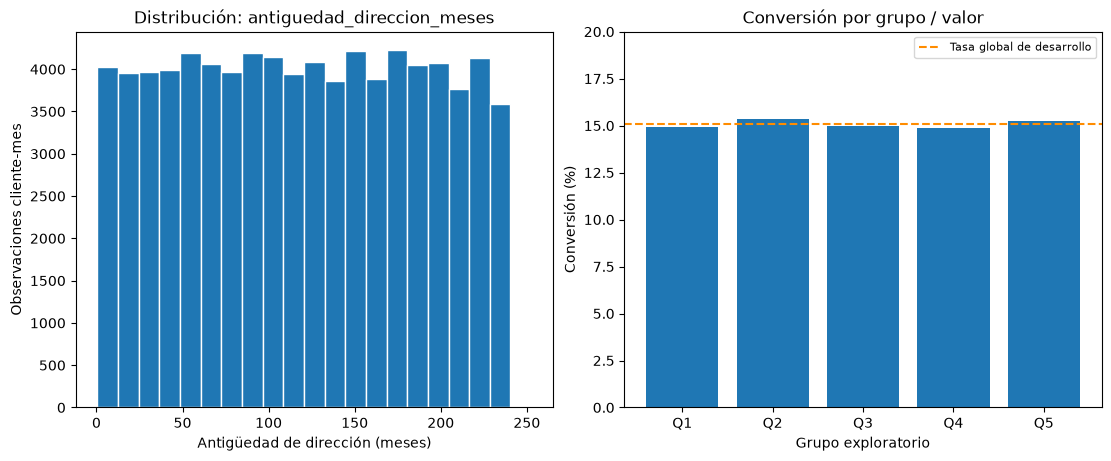

grupo,Q1,Q2,Q3,Q4,Q5
mes,,,,,
202601,14.01,15.42,14.62,14.24,14.83
202602,15.73,16.51,14.17,15.48,16.81
202603,14.62,14.86,15.45,14.39,14.80
202604,14.55,15.91,15.32,16.28,14.66
202605,16.77,15.50,16.49,14.03,15.61
202606,15.55,14.25,15.01,16.25,16.21
202607,13.52,15.49,14.93,14.03,14.72
202608,14.78,14.88,13.73,14.42,14.26


grupo,Q1,Q2,Q3,Q4,Q5
mes,,,,,
202601,2106,2114,2065,2058,2057
202602,2002,1981,1934,1938,1945
202603,2100,2052,2091,2050,2007
202604,1979,1904,1925,1923,1869
202605,2057,1987,2019,2038,1999
202606,2058,2056,2059,2098,2079
202607,1945,1950,1943,1932,1930
202608,2064,1982,1988,1997,2019


,observaciones_mes_min,observaciones_mes_max,tasa_mes_min_pct,tasa_mes_max_pct,rango_tasa_pp,proporcion_mes_min_pct,proporcion_mes_max_pct,rango_proporcion_pp
grupo,,,,,,,,
Q1,1945,2106,13.522,16.772,3.250,19.884,20.615,0.731
Q2,1904,2114,14.251,16.507,2.256,19.673,20.327,0.654
Q3,1925,2091,13.732,16.493,2.761,19.735,20.301,0.566
Q4,1923,2098,14.027,16.277,2.250,19.776,20.271,0.495
Q5,1869,2079,14.264,16.812,2.548,19.469,20.090,0.621


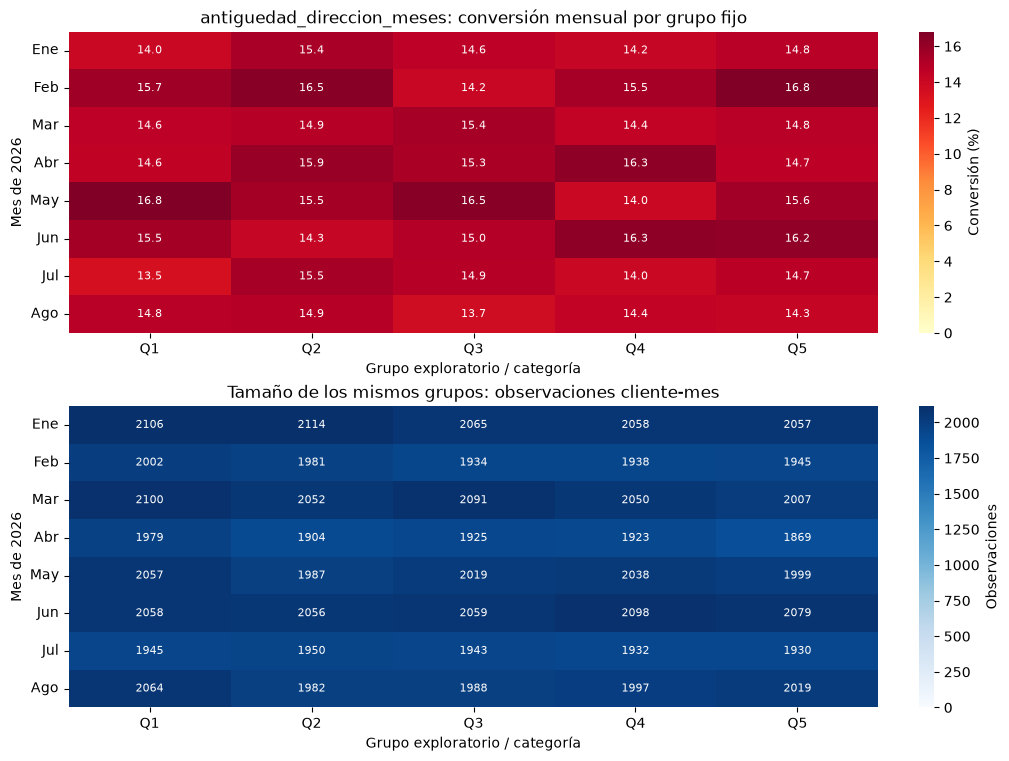

In [41]:
completar_numerica("antiguedad_direccion_meses", nueva=True)

### Conclusión exploratoria de `antiguedad_direccion_meses`

La antigüedad de dirección va de 1 a 239 meses, con mediana de 120; no hay nulos, ceros ni negativos. Los grupos tienen 15.905–16.311 observaciones y entre 1.869 y 2.114 por grupo-mes. Sus proporciones varían como máximo 0,73 puntos porcentuales.

Las tasas agregadas van de 14,89 % (145–191 meses) a 15,34 % (50–96 meses), una amplitud de **0,46 puntos porcentuales**. El grupo con mayor tasa agregada supera al de menor tasa en seis meses, pero cambian los grupos líderes y no aparece una relación creciente con la antigüedad. La variación mensual de Q1 es 13,52–16,77 %, mayor que la amplitud agregada entre quintiles.

Se conserva la variable numérica para evaluar su aporte posteriormente. Falta precisar si el tiempo corresponde a residencia, registro o última actualización de dirección, su fecha de corte y su disponibilidad antes de la conversión.

### Análisis de `visitas_web_ultimos_90_dias`

Estudiamos cada conteo entero observado, con atención a cero visitas y a los extremos poco frecuentes. No forzamos quintiles en un conteo con empates. El bloque consulta metadata, calcula resumen, percentiles, calidad y límites de grupos; después muestra conversión y tamaños mensuales. Los mapas de calor usan los mismos grupos en los ocho meses; las tablas de estabilidad también muestran cambios de proporción dentro de cada mes.

,19
column_name,visitas_web_ultimos_90_dias
description,Número de visitas web en los últimos 90 días
type,int
notes,Variable numérica


,visitas_web_ultimos_90_dias
count,80300.000000
mean,8.010872
std,2.811796
min,0.000000
1%,2.000000
20%,6.000000
25%,6.000000
40%,7.000000
50%,8.000000
60%,9.000000


,cantidad
nulos,0
valores_distintos,22
ceros,35
negativos,0
observaciones_en_minimo,35
observaciones_en_maximo,8
valores_no_enteros,0


,valor,observaciones,porcentaje
Mínimo,0,35,0.044
Máximo,21,8,0.010


,grupo,limite_inferior,limite_superior,cierre
0,0,0,0,valor exacto
1,1,1,1,valor exacto
2,2,2,2,valor exacto
3,3,3,3,valor exacto
4,4,4,4,valor exacto
5,5,5,5,valor exacto
6,6,6,6,valor exacto
7,7,7,7,valor exacto
8,8,8,8,valor exacto
9,9,9,9,valor exacto


,observaciones,clientes_unicos,conversiones,porcentaje_observaciones,tasa_porcentaje,minimo_observado,maximo_observado
grupo,,,,,,,
0,35,8,4,0.044,11.429,0,0
1,201,50,33,0.250,16.418,1,1
2,884,227,131,1.101,14.819,2,2
3,2121,574,344,2.641,16.219,3,3
4,4744,1245,747,5.908,15.746,4,4
5,7395,1879,1113,9.209,15.051,5,5
6,9197,2398,1423,11.453,15.472,6,6
7,11306,2920,1661,14.080,14.691,7,7
8,11617,2984,1747,14.467,15.038,8,8


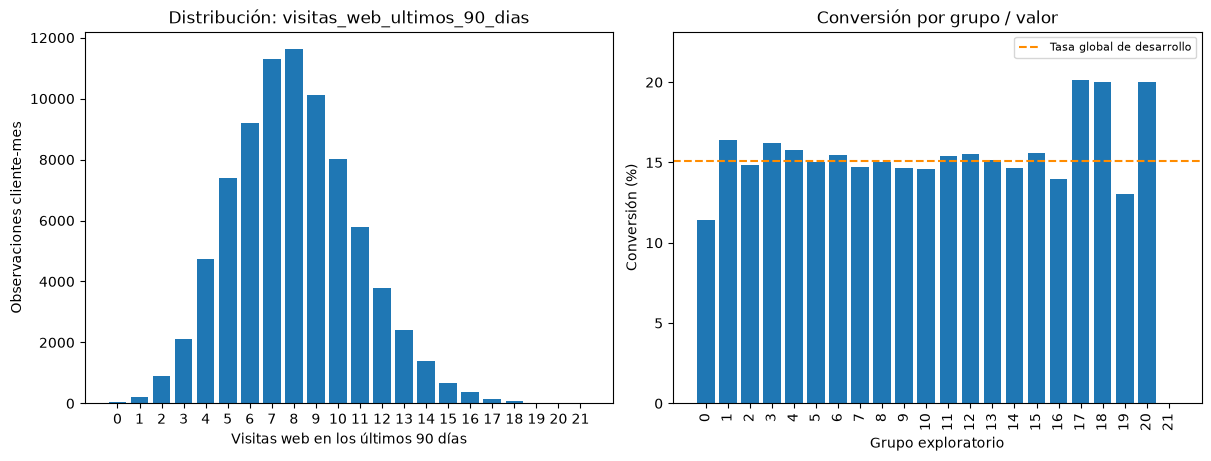

grupo,0,1,2,3,4,5,6,7,8,9,...,12,13,14,15,16,17,18,19,20,21
mes,,,,,,,,,,,,,,,,,,,,,
202601,0.0,4.17,22.76,16.13,17.39,13.40,15.19,14.23,14.82,14.86,...,16.70,12.35,16.18,11.24,15.22,28.00,50.00,0.00,0.0,0.0
202602,0.0,7.69,10.89,19.54,14.97,16.61,16.12,18.04,14.31,15.37,...,18.67,13.92,10.00,11.63,11.36,19.05,16.67,33.33,0.0,0.0
202603,0.0,17.24,15.18,14.61,15.00,14.72,15.42,13.45,16.08,14.52,...,14.82,18.87,14.69,14.13,12.50,16.67,22.22,0.00,0.0,0.0
202604,0.0,19.23,16.67,20.16,15.47,13.65,15.29,15.33,15.28,15.03,...,13.26,11.03,13.58,27.06,15.22,11.76,12.50,0.00,100.0,0.0
202605,40.0,11.11,11.01,14.17,15.56,16.53,16.47,14.91,15.71,15.95,...,16.88,15.71,15.52,11.84,14.00,17.65,0.00,0.00,NaN,0.0
202606,0.0,25.93,11.21,15.88,14.31,16.28,16.99,14.06,16.71,13.99,...,13.53,19.03,14.21,13.58,17.86,5.88,18.18,0.00,NaN,0.0
202607,20.0,28.57,17.12,13.08,17.07,14.42,14.22,13.68,12.99,14.01,...,14.98,17.19,15.52,16.67,18.37,15.00,11.11,0.00,NaN,0.0
202608,20.0,19.05,12.73,16.36,16.16,14.70,13.95,14.00,14.22,13.54,...,14.96,12.50,17.13,18.52,6.38,37.50,25.00,50.00,0.0,0.0


grupo,0,1,2,3,4,5,6,7,8,9,...,12,13,14,15,16,17,18,19,20,21
mes,,,,,,,,,,,,,,,,,,,,,
202601,2,24,123,279,621,955,1172,1448,1518,1279,...,515,324,173,89,46,25,10,3,1,1
202602,4,26,101,261,561,921,1104,1369,1426,1204,...,466,309,170,86,44,21,6,3,1,1
202603,5,29,112,267,600,958,1193,1405,1517,1281,...,479,318,177,92,48,18,9,2,1,1
202604,5,26,102,248,569,894,1105,1337,1407,1198,...,445,281,162,85,46,17,8,2,1,1
202605,5,27,109,254,604,956,1178,1415,1451,1273,...,474,312,174,76,50,17,9,3,0,1
202606,4,27,116,277,615,946,1201,1465,1478,1308,...,473,310,183,81,56,17,11,3,0,1
202607,5,21,111,260,580,867,1111,1403,1378,1249,...,454,285,174,78,49,20,9,3,0,1
202608,5,21,110,275,594,898,1133,1464,1442,1315,...,468,280,181,81,47,24,8,4,1,1


,observaciones_mes_min,observaciones_mes_max,tasa_mes_min_pct,tasa_mes_max_pct,rango_tasa_pp,proporcion_mes_min_pct,proporcion_mes_max_pct,rango_proporcion_pp
grupo,,,,,,,,
0,2,5,0.000,40.000,40.000,0.019,0.052,0.033
1,21,29,4.167,28.571,24.405,0.209,0.282,0.073
2,101,123,10.891,22.764,11.873,1.031,1.183,0.152
3,248,279,13.077,20.161,7.084,2.515,2.736,0.221
4,561,621,14.309,17.391,3.082,5.724,5.980,0.256
5,867,958,13.403,16.612,3.209,8.935,9.465,0.530
6,1104,1201,13.945,16.986,3.041,11.265,11.663,0.398
7,1337,1465,13.452,18.042,4.590,13.641,14.567,0.926
8,1378,1518,12.990,16.712,3.722,14.206,14.728,0.522


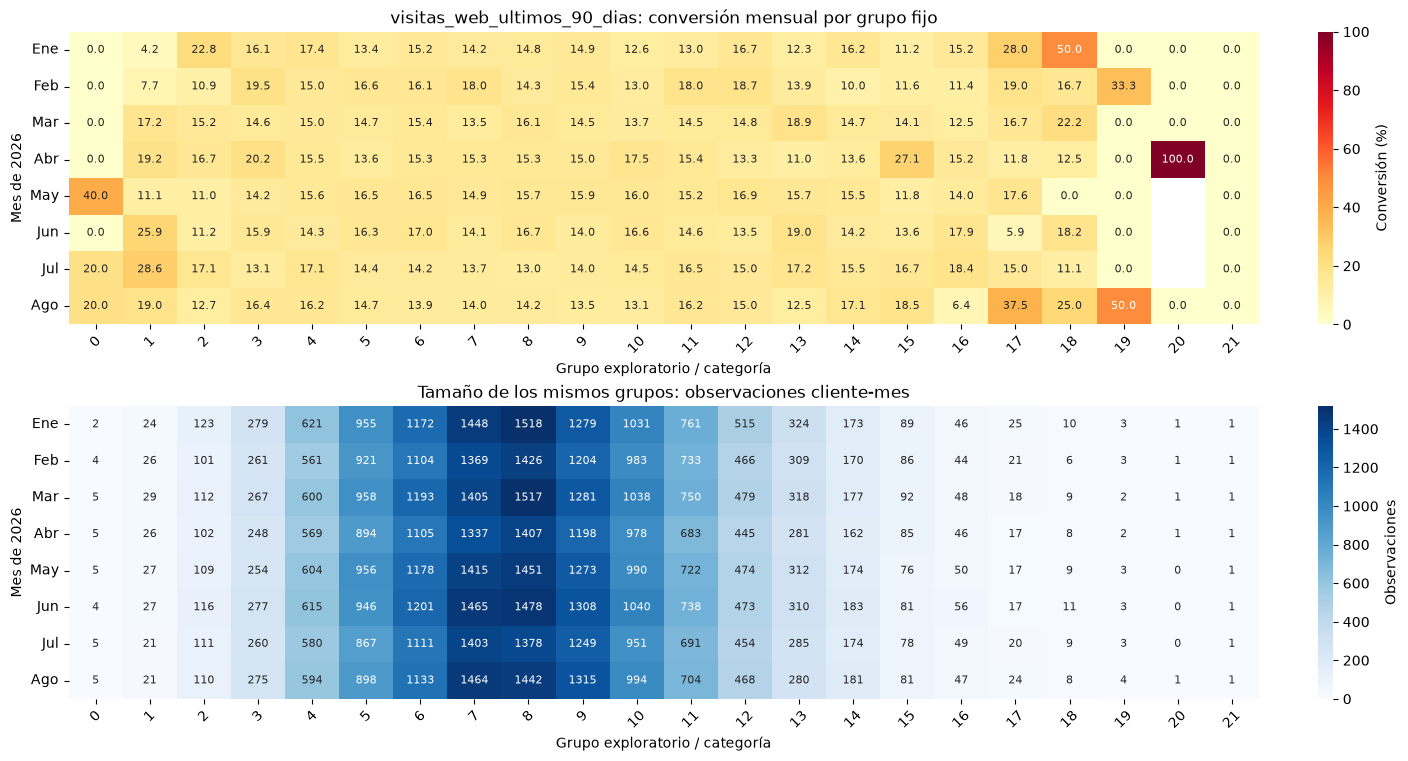

In [42]:
completar_numerica("visitas_web_ultimos_90_dias", nueva=True)

### Conclusión exploratoria de `visitas_web_ultimos_90_dias`

Se observan 22 cantidades enteras, de 0 a 21, sin nulos ni negativos. La mediana es 8; entre 5 y 11 visitas se concentran 63.409 observaciones (**78,97 %**). Cero visitas tiene 35 observaciones de solo 8 clientes. El valor 21 aparece en ocho filas de un único cliente, una por mes.

Entre 5 y 11 visitas, las tasas agregadas van de 14,62 % a 15,47 % (**0,86 puntos porcentuales**, antes de redondear); no se observa un aumento consistente con las visitas. En los extremos, 17 visitas presenta 20,13 % con 159 observaciones, mientras 21 tiene 0 % con ocho filas: esa diferencia de 20,13 puntos porcentuales no constituye evidencia robusta de ordenamiento. Con 20 visitas hay solo cinco filas y algunos meses carecen de observaciones; abril registra 100 % con una sola fila. Las proporciones del grupo modal (8) varían entre 14,21 % y 14,73 %, pero su tasa mensual entre 12,99 % y 16,71 %.

Se conserva el conteo sin eliminar ni unir automáticamente extremos. La exploración por valor evita cuantiles redundantes y permite ver los grupos pequeños. Falta confirmar qué cuenta como visita, la deduplicación de sesiones y que los 90 días terminen antes del momento de predicción.

### Análisis de `distancia_sucursal_km`

Revisamos distancia en kilómetros, cola derecha y concentraciones en extremos. El histograma tiene intervalos de igual amplitud; los quintiles se usan para comparar tasas. El bloque consulta metadata, calcula resumen, percentiles, calidad y límites de grupos; después muestra conversión y tamaños mensuales. Los mapas de calor usan los mismos grupos en los ocho meses; las tablas de estabilidad también muestran cambios de proporción dentro de cada mes.

,20
column_name,distancia_sucursal_km
description,Distancia aproximada a la sucursal más cercana
type,float
notes,Variable numérica


,distancia_sucursal_km
count,80300.000000
mean,10.158727
std,9.191011
min,0.212526
1%,1.165247
20%,3.787483
25%,4.317877
40%,6.142856
50%,7.476304
60%,9.133463


,cantidad
nulos,0
valores_distintos,20674
ceros,0
negativos,0
observaciones_en_minimo,3
observaciones_en_maximo,111


,valor,observaciones,porcentaje
Mínimo,0.213,3,0.004
Máximo,80.000,111,0.138


,grupo,limite_inferior,limite_superior,cierre
0,Q1,0.212525707633462,3.787482783221189,"[inferior, superior]"
1,Q2,3.787482783221189,6.142855752867429,"(inferior, superior]"
2,Q3,6.142855752867429,9.133462656710776,"(inferior, superior]"
3,Q4,9.133462656710776,14.496435593715805,"(inferior, superior]"
4,Q5,14.496435593715805,80.000000000000000,"(inferior, superior]"


,observaciones,clientes_unicos,conversiones,porcentaje_observaciones,tasa_porcentaje,minimo_observado,maximo_observado
grupo,,,,,,,
Q1,16064,4138,2422,20.005,15.077,0.213,3.787
Q2,16056,4177,2467,19.995,15.365,3.788,6.142
Q3,16063,4100,2338,20.004,14.555,6.144,9.133
Q4,16057,4164,2414,19.996,15.034,9.134,14.496
Q5,16060,4129,2466,20.000,15.355,14.497,80.000


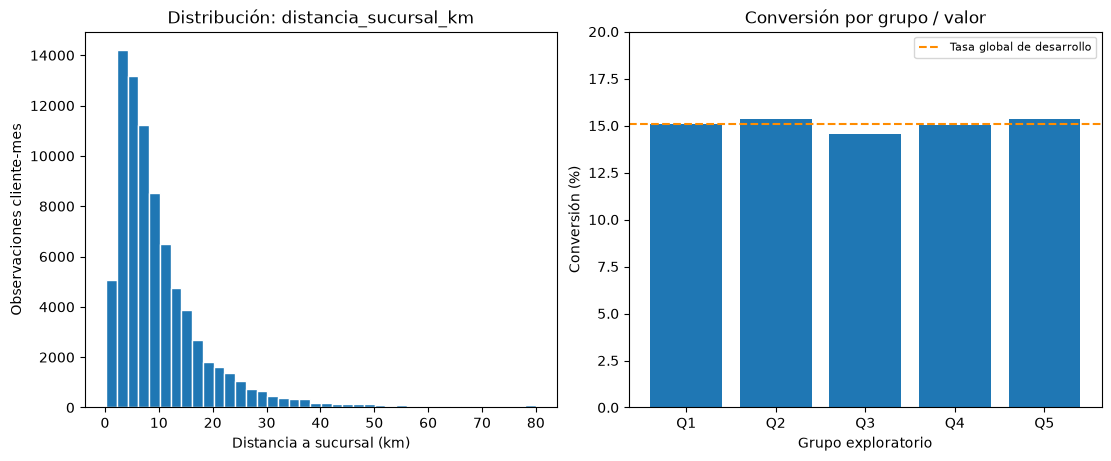

grupo,Q1,Q2,Q3,Q4,Q5
mes,,,,,
202601,14.75,15.12,14.09,13.73,15.38
202602,15.60,17.20,15.45,15.17,15.26
202603,16.03,15.48,13.80,14.10,14.70
202604,15.18,15.24,14.48,16.86,14.97
202605,14.77,15.36,15.59,16.13,16.56
202606,15.35,15.71,15.11,15.61,15.52
202607,14.16,14.74,13.92,15.56,14.30
202608,14.75,14.03,14.01,13.24,16.09


grupo,Q1,Q2,Q3,Q4,Q5
mes,,,,,
202601,2082,2129,2030,2039,2120
202602,1962,2012,1909,1945,1972
202603,2058,2067,2043,2071,2061
202604,1911,1916,1927,1922,1924
202605,2004,1999,2053,2015,2029
202606,2078,2037,2098,2088,2049
202607,1956,1907,1954,1960,1923
202608,2013,1989,2049,2017,1982


,observaciones_mes_min,observaciones_mes_max,tasa_mes_min_pct,tasa_mes_max_pct,rango_tasa_pp,proporcion_mes_min_pct,proporcion_mes_max_pct,rango_proporcion_pp
grupo,,,,,,,,
Q1,1911,2082,14.162,16.035,1.873,19.842,20.165,0.323
Q2,1907,2129,14.027,17.197,3.170,19.660,20.531,0.871
Q3,1909,2098,13.803,15.587,1.784,19.480,20.388,0.908
Q4,1922,2088,13.237,16.857,3.620,19.606,20.206,0.600
Q5,1923,2120,14.301,16.560,2.259,19.721,20.385,0.663


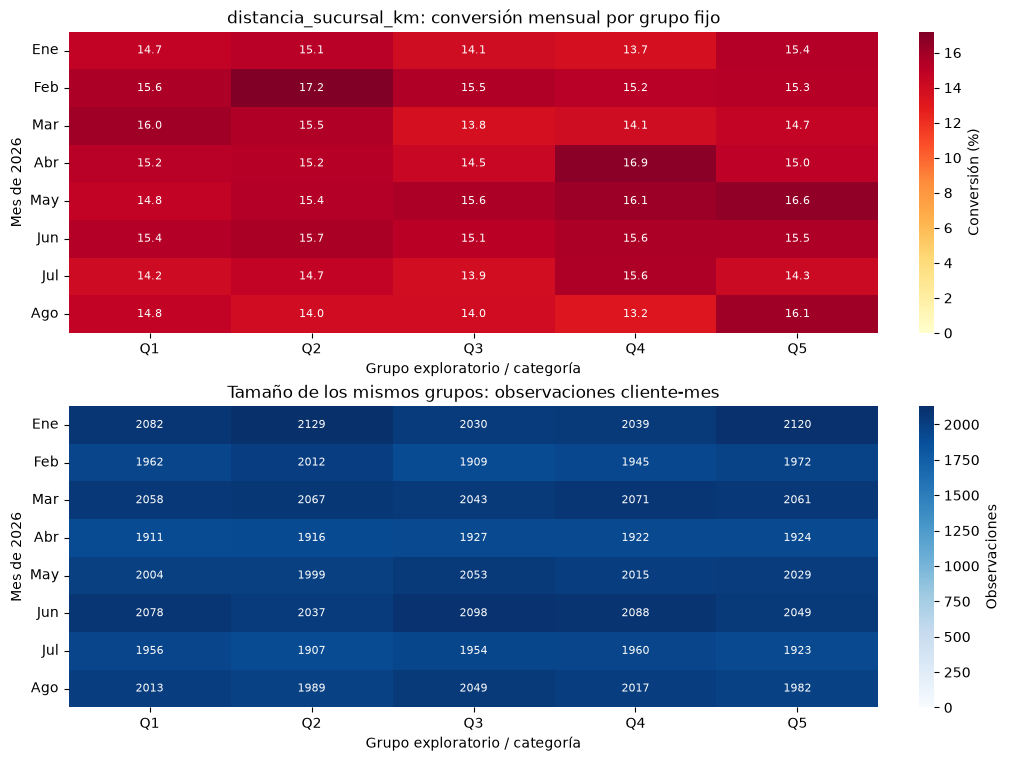

In [43]:
completar_numerica("distancia_sucursal_km", nueva=True)

### Conclusión exploratoria de `distancia_sucursal_km`

La distancia documentada en kilómetros va de 0,2125 a 80, con mediana de 7,48; no hay nulos, ceros ni negativos. La distribución tiene una cola derecha y 111 observaciones en 80 km (0,14 %), lo que requiere aclaración sin asumir un error.

Los quintiles reúnen 16.056–16.064 observaciones y al menos 1.907 por grupo-mes. Las tasas agregadas oscilan entre 14,56 % (Q3) y 15,37 % (Q2): **0,81 puntos porcentuales**. Q2 supera a Q3 en siete meses, pero el grupo líder cambia y no hay un gradiente monotónico por distancia. Las proporciones mensuales varían como máximo 0,91 puntos porcentuales; Q4 tiene tasas de 13,24–16,86 %.

Se conserva la distancia continua, sin recorte en 80 km ni transformaciones definitivas. Falta precisar cómo se estima la distancia (geográfica o recorrido), qué sucursales se consideran, la actualización del domicilio y si 80 corresponde a un límite del registro.

### Análisis de `dia_preferido_pago`

Comparamos por día exacto del mes, sin tratarlo automáticamente como una magnitud lineal ni agrupar días a partir del objetivo. El bloque consulta metadata, calcula resumen, percentiles, calidad y límites de grupos; después muestra conversión y tamaños mensuales. Los mapas de calor usan los mismos grupos en los ocho meses; las tablas de estabilidad también muestran cambios de proporción dentro de cada mes.

,22
column_name,dia_preferido_pago
description,Día preferido del mes para realizar pagos
type,int
notes,Variable numérica


,dia_preferido_pago
count,80300.000000
mean,14.522814
std,8.042095
min,1.000000
1%,1.000000
20%,6.000000
25%,8.000000
40%,12.000000
50%,14.000000
60%,17.000000


,cantidad
nulos,0
valores_distintos,28
ceros,0
negativos,0
observaciones_en_minimo,2879
observaciones_en_maximo,2739
valores_no_enteros,0
fuera_de_1_a_31,0


,valor,observaciones,porcentaje
Mínimo,1,2879,3.585
Máximo,28,2739,3.411


,grupo,limite_inferior,limite_superior,cierre
0,1,1,1,valor exacto
1,2,2,2,valor exacto
2,3,3,3,valor exacto
3,4,4,4,valor exacto
4,5,5,5,valor exacto
5,6,6,6,valor exacto
6,7,7,7,valor exacto
7,8,8,8,valor exacto
8,9,9,9,valor exacto
9,10,10,10,valor exacto


,observaciones,clientes_unicos,conversiones,porcentaje_observaciones,tasa_porcentaje,minimo_observado,maximo_observado
grupo,,,,,,,
1,2879,762,467,3.585,16.221,1,1
2,2879,746,434,3.585,15.075,2,2
3,2633,699,387,3.279,14.698,3,3
4,2873,734,420,3.578,14.619,4,4
5,2836,742,434,3.532,15.303,5,5
6,2988,761,453,3.721,15.161,6,6
7,2864,735,413,3.567,14.420,7,7
8,2708,710,402,3.372,14.845,8,8
9,2776,722,401,3.457,14.445,9,9


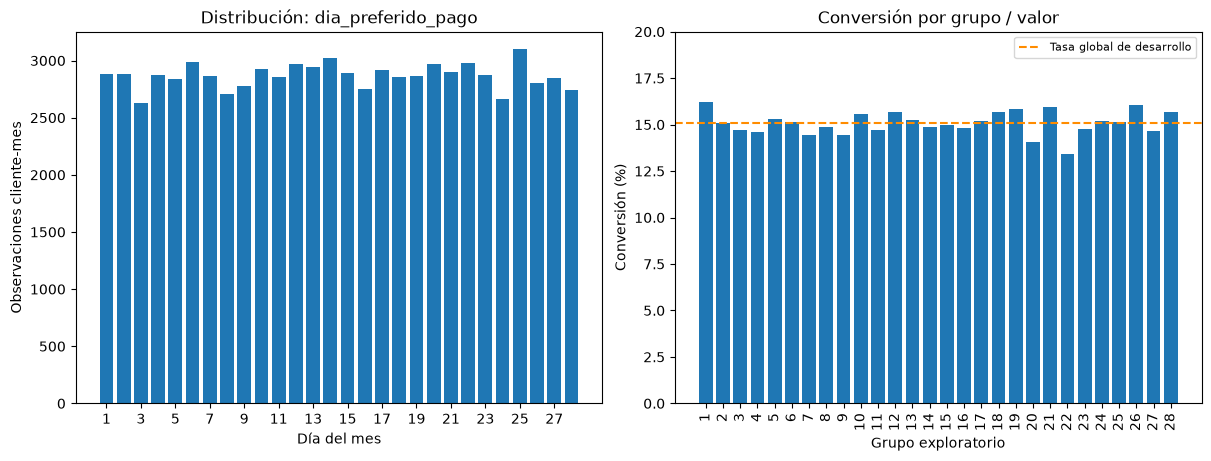

grupo,1,2,3,4,5,6,7,8,9,10,...,19,20,21,22,23,24,25,26,27,28
mes,,,,,,,,,,,,,,,,,,,,,
202601,15.66,15.24,15.74,13.28,17.50,12.59,15.36,17.31,11.11,16.94,...,13.12,12.30,13.88,13.24,13.39,16.16,15.72,16.54,14.56,19.37
202602,15.79,16.67,17.46,14.49,17.17,16.58,12.80,14.69,18.02,15.32,...,14.68,13.52,16.89,10.48,17.66,15.27,15.26,18.80,15.50,16.51
202603,16.54,15.78,12.69,14.82,14.75,17.14,16.22,13.41,14.20,16.35,...,17.33,15.65,15.71,11.20,14.05,14.78,15.80,14.57,12.93,15.82
202604,17.15,13.01,15.65,15.34,13.16,16.48,15.88,12.69,14.55,12.98,...,16.37,14.93,15.95,14.44,18.08,12.06,17.17,16.27,15.25,11.46
202605,20.61,18.31,15.87,14.09,15.08,15.45,15.45,17.38,15.25,16.58,...,17.60,14.02,16.34,15.03,12.82,19.15,12.73,14.66,13.88,14.85
202606,14.20,15.22,17.35,16.36,16.84,15.14,12.30,14.61,16.89,13.52,...,12.83,14.55,15.26,16.50,13.90,15.20,15.37,19.11,16.84,16.22
202607,13.73,12.32,12.62,16.95,15.82,12.25,13.46,15.29,13.98,16.35,...,13.95,12.67,19.42,15.83,14.25,14.15,15.13,13.58,12.18,16.76
202608,15.95,13.81,10.34,11.55,12.00,15.62,13.90,13.24,11.57,16.21,...,20.60,14.88,14.16,10.00,14.29,14.46,14.00,14.74,16.16,14.20


grupo,1,2,3,4,5,6,7,8,9,10,...,19,20,21,22,23,24,25,26,27,28
mes,,,,,,,,,,,,,,,,,,,,,
202601,396,374,343,354,360,397,358,335,351,366,...,381,374,389,355,366,365,407,381,371,351
202602,361,348,315,345,332,386,336,320,344,333,...,361,355,373,334,351,334,367,351,342,315
202603,381,374,323,371,366,385,370,328,345,373,...,375,377,382,366,370,345,386,357,348,335
202604,344,346,313,352,342,352,340,323,323,339,...,342,355,351,360,343,315,361,338,341,314
202605,359,366,334,369,358,369,356,351,354,386,...,358,378,361,386,351,329,377,348,353,357
202606,352,368,340,379,374,383,366,356,367,392,...,343,385,367,406,374,329,410,361,374,370
202607,335,341,317,348,354,351,364,340,329,373,...,337,363,345,379,351,311,390,324,353,352
202608,351,362,348,355,350,365,374,355,363,364,...,364,383,332,390,371,332,400,346,365,345


,observaciones_mes_min,observaciones_mes_max,tasa_mes_min_pct,tasa_mes_max_pct,rango_tasa_pp,proporcion_mes_min_pct,proporcion_mes_max_pct,rango_proporcion_pp
grupo,,,,,,,,
1,335,396,13.731,20.613,6.881,3.401,3.808,0.407
2,341,374,12.317,18.306,5.989,3.515,3.631,0.116
3,313,348,10.345,17.460,7.115,3.136,3.463,0.327
4,345,379,11.549,16.954,5.405,3.404,3.667,0.263
5,332,374,12.000,17.500,5.500,3.388,3.649,0.262
6,351,397,12.251,17.143,4.892,3.619,3.939,0.320
7,336,374,12.295,16.216,3.921,3.429,3.753,0.324
8,320,356,12.693,17.379,4.685,3.184,3.532,0.348
9,323,367,11.111,18.023,6.912,3.350,3.612,0.262


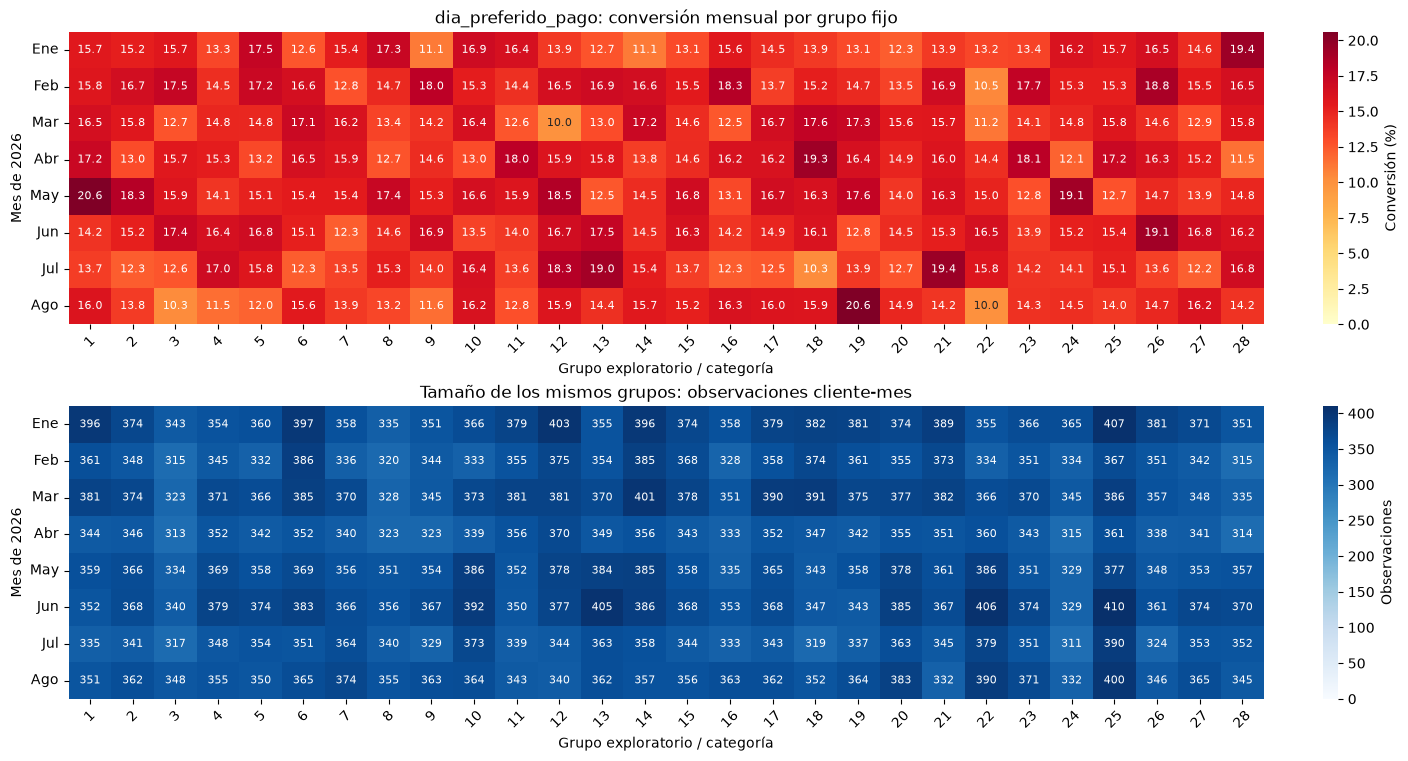

In [44]:
completar_numerica("dia_preferido_pago", nueva=True)

### Conclusión exploratoria de `dia_preferido_pago`

Hay 28 valores enteros observados, del 1 al 28, sin nulos, ceros, negativos ni valores fuera de 1–31. La ausencia de 29–31 es una característica del archivo, no una regla permitida documentada. Los días tienen 2.633–3.098 observaciones y 311–410 por mes; cada proporción diaria cambia como máximo 0,53 puntos porcentuales.

El día 1 presenta 16,22 % de conversión frente a 13,41 % del día 22, una amplitud de **2,81 puntos porcentuales**. El día 1 supera al 22 en seis meses, pero la categoría con mayor tasa cambia. Para el día 28 las tasas mensuales van de 11,46 % a 19,37 % con 314–370 filas por mes; estas oscilaciones son mayores que la diferencia agregada citada. No se establece una relación creciente ni un efecto específico de fin de mes.

Se conserva el valor registrado. Cualquier representación categórica o cíclica se evaluará en otra fase, sin adoptarla ahora. Falta confirmar si es preferencia declarada o conducta inferida, cómo se manejan meses de distinta duración y la razón de no observar 29–31.

### Análisis de `dias_ultima_interaccion`

Examinamos días desde la interacción y conversión por cuantiles fijos. Su relación con la recencia de transacción se revisa al final. El bloque consulta metadata, calcula resumen, percentiles, calidad y límites de grupos; después muestra conversión y tamaños mensuales. Los mapas de calor usan los mismos grupos en los ocho meses; las tablas de estabilidad también muestran cambios de proporción dentro de cada mes.

,13
column_name,dias_ultima_interaccion
description,Días desde la última interacción registrada co...
type,int
notes,Variable numérica


,dias_ultima_interaccion
count,80300.000000
mean,188.721880
std,105.113966
min,1.000000
1%,4.000000
20%,79.000000
25%,99.000000
40%,155.000000
50%,191.000000
60%,228.000000


,cantidad
nulos,0
valores_distintos,364
ceros,0
negativos,0
observaciones_en_minimo,141
observaciones_en_maximo,258


,valor,observaciones,porcentaje
Mínimo,1,141,0.176
Máximo,364,258,0.321


,grupo,limite_inferior,limite_superior,cierre
0,Q1,1.0,79.0,"[inferior, superior]"
1,Q2,79.0,155.0,"(inferior, superior]"
2,Q3,155.0,228.0,"(inferior, superior]"
3,Q4,228.0,298.0,"(inferior, superior]"
4,Q5,298.0,364.0,"(inferior, superior]"


,observaciones,clientes_unicos,conversiones,porcentaje_observaciones,tasa_porcentaje,minimo_observado,maximo_observado
grupo,,,,,,,
Q1,16099,7608,2802,20.049,17.405,1,79
Q2,16223,7478,2547,20.203,15.700,80,155
Q3,16015,7329,2417,19.944,15.092,156,228
Q4,15980,7163,2212,19.900,13.842,229,298
Q5,15983,7076,2129,19.904,13.320,299,364


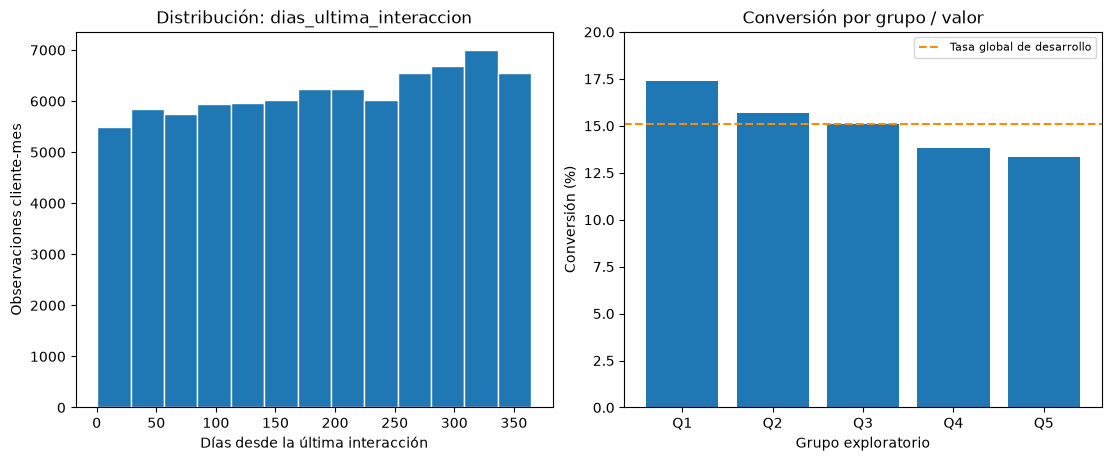

grupo,Q1,Q2,Q3,Q4,Q5
mes,,,,,
202601,16.48,15.87,14.89,13.14,12.38
202602,17.81,16.53,17.19,13.65,13.38
202603,18.10,16.06,13.76,13.34,12.55
202604,18.26,15.27,15.89,13.93,13.40
202605,18.25,16.56,14.58,14.51,14.59
202606,17.43,15.72,15.45,14.41,14.37
202607,16.84,15.63,13.93,13.67,12.68
202608,16.09,13.81,15.15,14.04,13.09


grupo,Q1,Q2,Q3,Q4,Q5
mes,,,,,
202601,2197,2193,2069,1987,1954
202602,2021,2021,1925,1912,1921
202603,2122,2173,2035,1994,1976
202604,1906,1939,1926,1888,1941
202605,1978,2029,2024,2013,2056
202606,2043,2035,2039,2124,2109
202607,1918,1907,1924,2011,1940
202608,1914,1926,2073,2051,2086


,observaciones_mes_min,observaciones_mes_max,tasa_mes_min_pct,tasa_mes_max_pct,rango_tasa_pp,proporcion_mes_min_pct,proporcion_mes_max_pct,rango_proporcion_pp
grupo,,,,,,,,
Q1,1906,2197,16.092,18.258,2.166,19.045,21.125,2.080
Q2,1907,2193,13.811,16.560,2.749,19.164,21.097,1.933
Q3,1924,2073,13.759,17.195,3.436,19.643,20.627,0.984
Q4,1888,2124,13.135,14.506,1.370,19.106,20.732,1.626
Q5,1921,2109,12.385,14.591,2.207,18.788,20.756,1.968


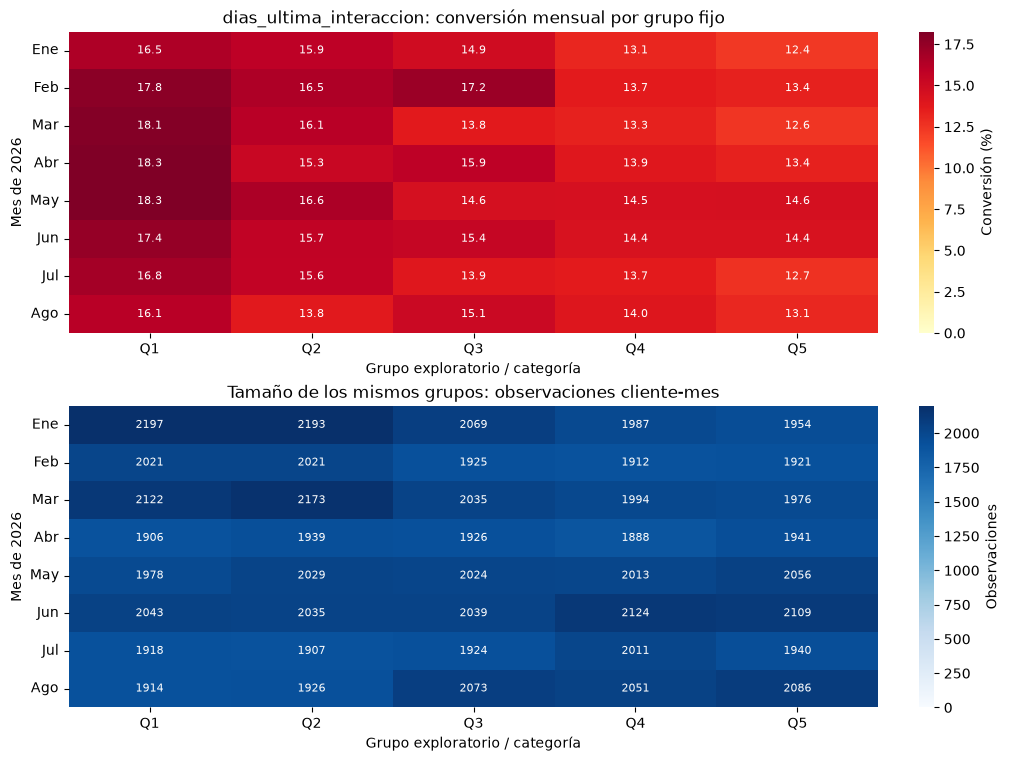

In [45]:
completar_numerica("dias_ultima_interaccion", nueva=True)

### Conclusión exploratoria de `dias_ultima_interaccion`

La última interacción está entre 1 y 364 días, con mediana de 191; no presenta nulos, ceros ni negativos. Los grupos contienen 15.980–16.223 observaciones y al menos 1.888 por grupo-mes.

La conversión agregada baja desde 17,40 % en 1–79 días a 13,32 % en 299–364 días: **4,08 puntos porcentuales**. El primer grupo supera al último en los ocho meses y el último es el de menor tasa en siete. El orden completo no es monotónico todos los meses. Q1 varía entre 16,09 % y 18,26 %; las proporciones de los grupos cambian como máximo 2,08 puntos porcentuales.

Se conserva provisionalmente junto con la recencia de transacción. La correlación y las coincidencias entre ambas requieren revisión específica en el cierre. Falta definir los canales y eventos que constituyen interacción, su fecha de referencia y la exclusión de actividades posteriores a la predicción.

### Análisis de `ocupacion`

Revisamos el vocabulario laboral realmente observado, su formato, frecuencias y conversión mensual. El bloque consulta metadata, muestra categorías, frecuencias y conversión; revisa inconsistencias sin corregirlas y compara tasas y tamaños mensuales. Los mapas de calor usan los mismos grupos en los ocho meses; las tablas de estabilidad también muestran cambios de proporción dentro de cada mes.

,9
column_name,ocupacion
description,Categoría laboral del cliente
type,string
notes,Variable categórica


,observaciones,clientes_unicos,conversiones,porcentaje_observaciones,tasa_porcentaje
grupo,,,,,
clerical,24123,6226,3649,30.041,15.127
manager,8229,2082,1152,10.248,13.999
manual,22280,5752,3350,27.746,15.036
professional,18228,4736,2803,22.700,15.377
self_employed,7440,1912,1153,9.265,15.497


,categoria_original,forma_para_revision,espacios_en_extremos,vacia_tras_strip,colision_de_formas
0,clerical,clerical,False,False,False
1,manager,manager,False,False,False
2,manual,manual,False,False,False
3,professional,professional,False,False,False
4,self_employed,self_employed,False,False,False


Nulos: 0 | No hay catálogo oficial de categorías permitidas en metadata.


grupo,clerical,manager,manual,professional,self_employed
mes,,,,,
202601,15.21,14.95,13.68,14.96,14.36
202602,15.34,14.55,16.51,16.15,15.03
202603,14.27,14.42,15.11,14.88,16.04
202604,15.39,14.42,14.69,15.46,17.85
202605,16.01,13.99,15.55,16.62,14.59
202606,16.14,14.47,15.16,15.47,15.22
202607,13.82,11.63,15.31,15.08,16.57
202608,14.78,13.57,14.34,14.43,14.43


grupo,clerical,manager,manual,professional,self_employed
mes,,,,,
202601,3097,1050,2865,2413,975
202602,2908,976,2726,2272,918
202603,3077,1033,2865,2346,979
202604,2878,964,2689,2167,902
202605,3067,1022,2797,2275,939
202606,3142,1085,2843,2321,959
202607,2930,1023,2691,2175,881
202608,3024,1076,2804,2259,887


,observaciones_mes_min,observaciones_mes_max,tasa_mes_min_pct,tasa_mes_max_pct,rango_tasa_pp,proporcion_mes_min_pct,proporcion_mes_max_pct,rango_proporcion_pp
grupo,,,,,,,,
clerical,2878,3142,13.823,16.136,2.314,29.673,30.366,0.693
manager,964,1085,11.632,14.952,3.320,9.959,10.706,0.747
manual,2689,2865,13.682,16.508,2.825,27.469,28.010,0.542
professional,2167,2413,14.431,16.615,2.184,22.423,23.202,0.779
self_employed,881,979,14.359,17.849,3.490,8.826,9.505,0.679


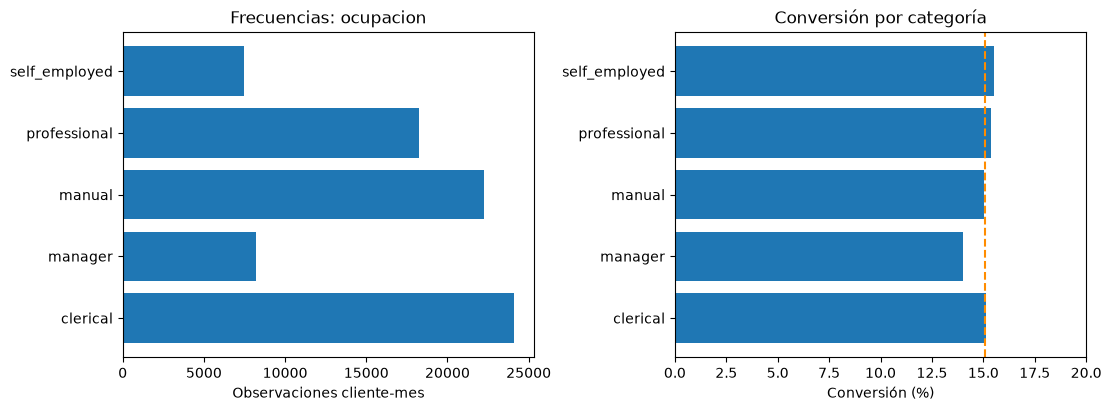

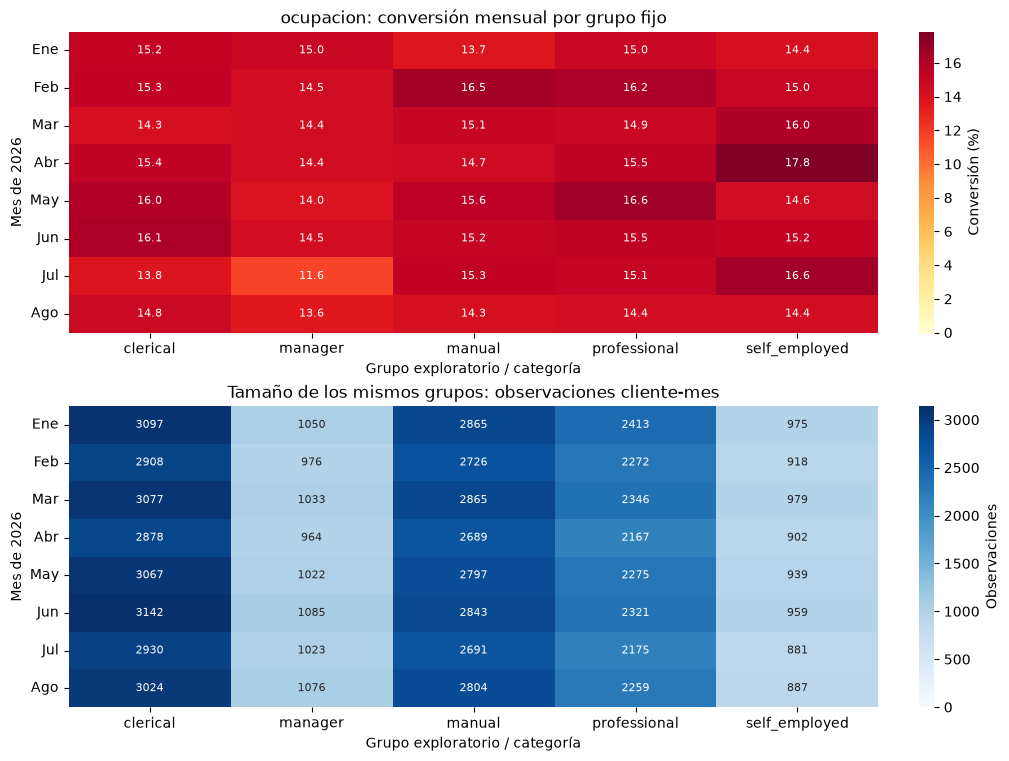

In [46]:
analizar_categorica("ocupacion")

### Conclusión exploratoria de `ocupacion`

Las cinco categorías reales son `clerical`, `manager`, `manual`, `professional` y `self_employed`; no aparecen nulos, textos vacíos, espacios extremos ni colisiones tras normalizar únicamente para revisión. `clerical` y `manual` suman 57,79 % de las observaciones.

`self_employed` tiene 15,50 % de conversión y `manager` 14,00 %: **1,50 puntos porcentuales**. La primera supera a la segunda en siete meses, aunque las categorías líderes cambian. La categoría más pequeña, `self_employed`, reúne 7.440 filas y 881–979 mensuales; sus tasas varían entre 14,36 % y 17,85 %. La proporción de cualquier categoría cambia como máximo 0,78 puntos porcentuales.

Se conserva la categoría original, sin traducir, fusionar ni asignar un orden numérico. Falta un catálogo oficial con la definición de cada ocupación y su fecha de actualización; los textos en inglés no permiten inferir una clasificación local específica.

### Análisis de `region`

Comparamos las etiquetas geográficas disponibles sin asignarles zonas no documentadas. El bloque consulta metadata, muestra categorías, frecuencias y conversión; revisa inconsistencias sin corregirlas y compara tasas y tamaños mensuales. Los mapas de calor usan los mismos grupos en los ocho meses; las tablas de estabilidad también muestran cambios de proporción dentro de cada mes.

,10
column_name,region
description,Región del cliente
type,string
notes,Variable categórica


,observaciones,clientes_unicos,conversiones,porcentaje_observaciones,tasa_porcentaje
grupo,,,,,
central,12086,3082,1782,15.051,14.744
east,14347,3694,2202,17.867,15.348
north,17611,4505,2641,21.932,14.996
south,16207,4177,2434,20.183,15.018
west,20049,5250,3048,24.968,15.203


,categoria_original,forma_para_revision,espacios_en_extremos,vacia_tras_strip,colision_de_formas
0,central,central,False,False,False
1,east,east,False,False,False
2,north,north,False,False,False
3,south,south,False,False,False
4,west,west,False,False,False


Nulos: 0 | No hay catálogo oficial de categorías permitidas en metadata.


grupo,central,east,north,south,west
mes,,,,,
202601,13.83,13.98,15.35,14.22,15.24
202602,15.70,15.62,15.11,15.50,16.63
202603,15.19,14.34,14.44,14.57,15.49
202604,15.61,15.65,15.28,14.87,15.40
202605,15.61,15.64,16.11,15.07,15.88
202606,15.26,16.06,14.84,16.45,14.88
202607,13.30,15.39,14.95,15.22,13.75
202608,13.39,16.18,13.86,14.22,14.42


grupo,central,east,north,south,west
mes,,,,,
202601,1562,1860,2332,2067,2579
202602,1497,1761,2157,1974,2411
202603,1600,1820,2244,2073,2563
202604,1473,1706,2114,1937,2370
202605,1512,1810,2222,2050,2506
202606,1520,1862,2264,2116,2588
202607,1421,1748,2114,1958,2459
202608,1501,1780,2164,2032,2573


,observaciones_mes_min,observaciones_mes_max,tasa_mes_min_pct,tasa_mes_max_pct,rango_tasa_pp,proporcion_mes_min_pct,proporcion_mes_max_pct,rango_proporcion_pp
grupo,,,,,,,,
central,1421,1600,13.300,15.698,2.398,14.649,15.534,0.884
east,1706,1862,13.978,16.180,2.201,17.670,18.021,0.351
north,2114,2332,13.863,16.112,2.248,21.532,22.423,0.891
south,1937,2116,14.222,16.446,2.224,19.875,20.444,0.569
west,2370,2588,13.745,16.632,2.887,24.602,25.602,1.000


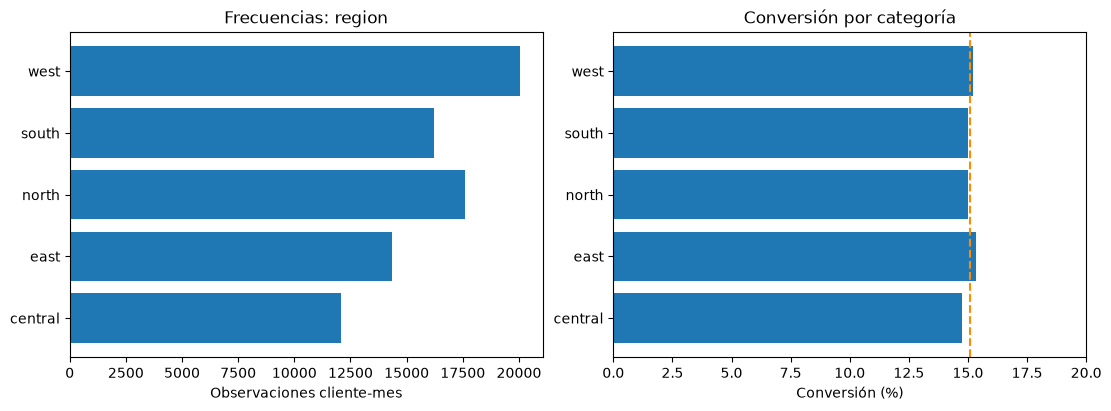

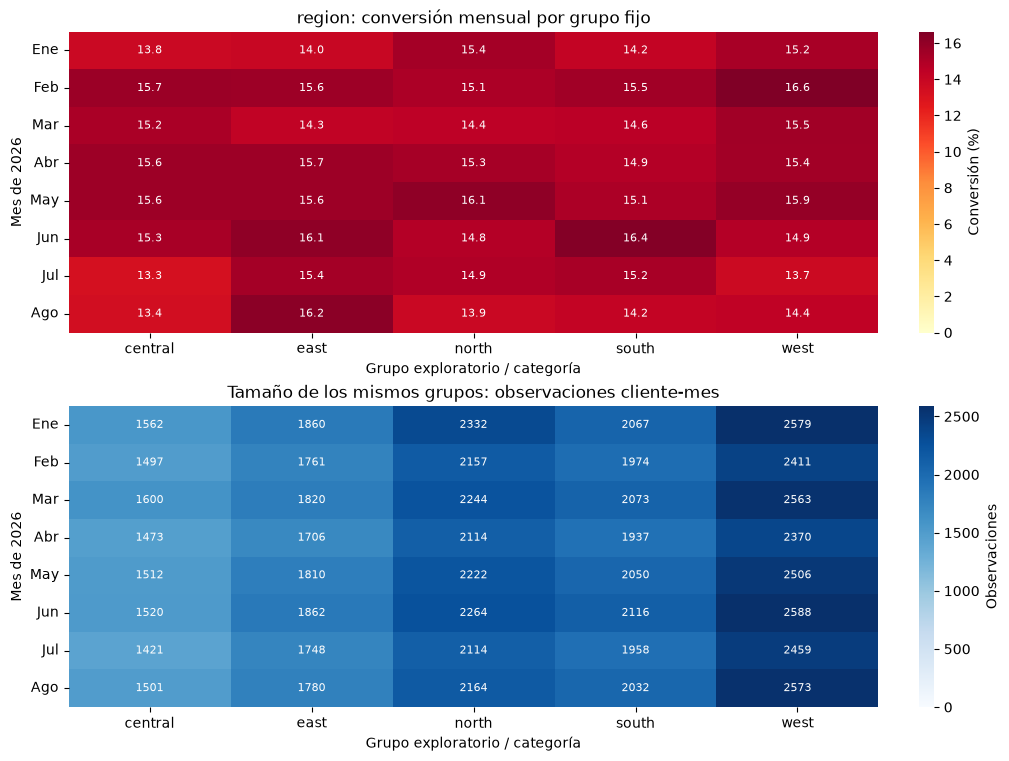

In [47]:
analizar_categorica("region")

### Conclusión exploratoria de `region`

Se observan `central`, `east`, `north`, `south` y `west`, sin nulos ni inconsistencias de formato en los controles realizados. `west` concentra 24,97 % y `central` 15,05 %. Las categorías tienen 12.086–20.049 filas y al menos 1.421 por categoría-mes.

La tasa agregada va de 14,74 % (`central`) a 15,35 % (`east`), una amplitud de **0,60 puntos porcentuales**. `east` supera a `central` en seis meses; el liderazgo cambia y `west` oscila entre 13,75 % y 16,63 %. Las proporciones mensuales cambian como máximo 1,00 punto porcentual.

Se conserva la región como categoría. Las etiquetas son genéricas: no se interpretan como departamentos ni zonas concretas del Perú. Quedan pendientes su definición geográfica, la fuente, la actualización y la disponibilidad a la fecha de corte.

### Análisis de `canal_adquisicion`

Estudiamos los canales de adquisición, sus tamaños y diferencias de tasas por mes. El bloque consulta metadata, muestra categorías, frecuencias y conversión; revisa inconsistencias sin corregirlas y compara tasas y tamaños mensuales. Los mapas de calor usan los mismos grupos en los ocho meses; las tablas de estabilidad también muestran cambios de proporción dentro de cada mes.

,11
column_name,canal_adquisicion
description,Canal por el que el cliente fue adquirido
type,string
notes,Variable categórica


,observaciones,clientes_unicos,conversiones,porcentaje_observaciones,tasa_porcentaje
grupo,,,,,
branch,12476,3148,1781,15.537,14.275
call_center,11886,3066,1846,14.802,15.531
mobile,21091,5501,3200,26.265,15.172
partner,8354,2093,1219,10.403,14.592
web,26493,6900,4061,32.993,15.329


,categoria_original,forma_para_revision,espacios_en_extremos,vacia_tras_strip,colision_de_formas
0,branch,branch,False,False,False
1,call_center,call_center,False,False,False
2,mobile,mobile,False,False,False
3,partner,partner,False,False,False
4,web,web,False,False,False


Nulos: 0 | No hay catálogo oficial de categorías permitidas en metadata.


grupo,branch,call_center,mobile,partner,web
mes,,,,,
202601,13.61,14.80,15.29,13.02,14.99
202602,15.13,16.83,15.21,14.84,16.26
202603,14.77,13.54,14.72,14.67,15.56
202604,15.30,15.80,15.43,15.82,14.93
202605,15.16,15.78,16.00,14.83,15.90
202606,14.70,15.23,15.25,14.91,16.25
202607,13.60,16.27,14.15,14.97,14.36
202608,11.92,16.15,15.31,13.72,14.31


grupo,branch,call_center,mobile,partner,web
mes,,,,,
202601,1594,1561,2728,1075,3442
202602,1533,1456,2558,1024,3229
202603,1625,1507,2684,1091,3393
202604,1503,1437,2488,1024,3148
202605,1557,1496,2657,1045,3345
202606,1605,1530,2708,1080,3427
202607,1507,1444,2551,1002,3196
202608,1552,1455,2717,1013,3313


,observaciones_mes_min,observaciones_mes_max,tasa_mes_min_pct,tasa_mes_max_pct,rango_tasa_pp,proporcion_mes_min_pct,proporcion_mes_max_pct,rango_proporcion_pp
grupo,,,,,,,,
branch,1503,1625,11.920,15.303,3.383,15.327,15.777,0.450
call_center,1437,1561,13.537,16.827,3.290,14.478,15.010,0.532
mobile,2488,2728,14.151,15.995,1.844,25.917,27.035,1.118
partner,1002,1091,13.023,15.820,2.797,10.080,10.667,0.587
web,3148,3442,14.307,16.259,1.952,32.792,33.119,0.327


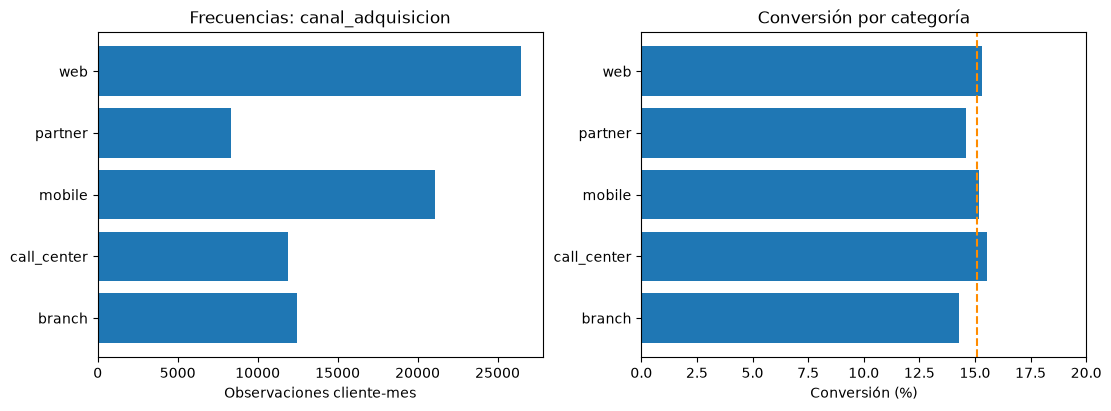

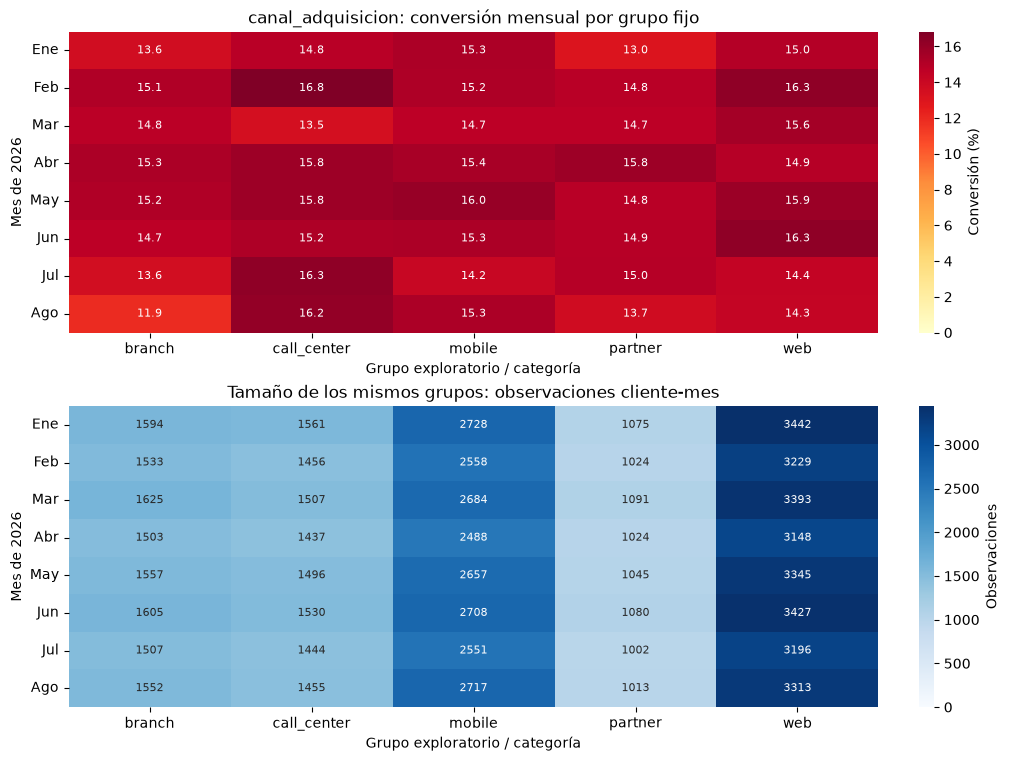

In [48]:
analizar_categorica("canal_adquisicion")

### Conclusión exploratoria de `canal_adquisicion`

Las categorías observadas son `branch`, `call_center`, `mobile`, `partner` y `web`, sin nulos ni variantes de formato detectadas. `web` tiene 32,99 % de las filas y `mobile` 26,27 %; `partner` es la menor, con 8.354 filas y 1.002–1.091 por mes.

`call_center` registra 15,53 % de conversión frente a 14,28 % de `branch`: **1,26 puntos porcentuales**. La diferencia conserva su signo en siete meses, con inversión en marzo. En agosto `branch` baja a 11,92 % mientras `call_center` llega a 16,15 %; el orden de todos los canales no se mantiene. Las proporciones varían como máximo 1,12 puntos porcentuales.

Se conserva el canal original; no se equipara adquisición con canal de interacción actual. Falta aclarar si corresponde al primer contacto, al alta o a una atribución actualizada, y cómo se definen los socios (`partner`).

### Análisis de `banda_riesgo`

Revisamos bandas de riesgo, sus tasas y cambios de composición, sin decidir una codificación definitiva. El bloque consulta metadata, muestra categorías, frecuencias y conversión; revisa inconsistencias sin corregirlas y compara tasas y tamaños mensuales. Los mapas de calor usan los mismos grupos en los ocho meses; las tablas de estabilidad también muestran cambios de proporción dentro de cada mes.

,12
column_name,banda_riesgo
description,Segmento de riesgo del cliente
type,string
notes,Variable categórica


,observaciones,clientes_unicos,conversiones,porcentaje_observaciones,tasa_porcentaje
grupo,,,,,
high,16040,3466,1374,19.975,8.566
low,38392,10891,7179,47.811,18.699
medium,25868,6351,3554,32.214,13.739


,categoria_original,forma_para_revision,espacios_en_extremos,vacia_tras_strip,colision_de_formas
0,high,high,False,False,False
1,low,low,False,False,False
2,medium,medium,False,False,False


Nulos: 0 | No hay catálogo oficial de categorías permitidas en metadata.


grupo,high,low,medium
mes,,,
202601,8.69,17.68,12.84
202602,8.71,19.60,13.75
202603,8.26,18.34,13.24
202604,8.90,19.21,13.62
202605,8.99,19.64,14.13
202606,9.74,18.99,14.11
202607,7.87,18.27,13.86
202608,7.47,17.93,14.36


grupo,high,low,medium
mes,,,
202601,1783,5362,3255
202602,1791,4888,3121
202603,1924,5075,3301
202604,1911,4575,3114
202605,2069,4782,3249
202606,2166,4797,3387
202607,2135,4390,3175
202608,2261,4523,3266


,observaciones_mes_min,observaciones_mes_max,tasa_mes_min_pct,tasa_mes_max_pct,rango_tasa_pp,proporcion_mes_min_pct,proporcion_mes_max_pct,rango_proporcion_pp
grupo,,,,,,,,
high,1783,2261,7.475,9.741,2.267,17.144,22.498,5.353
low,4390,5362,17.680,19.636,1.956,45.005,51.558,6.553
medium,3114,3387,12.842,14.360,1.518,31.298,32.732,1.434


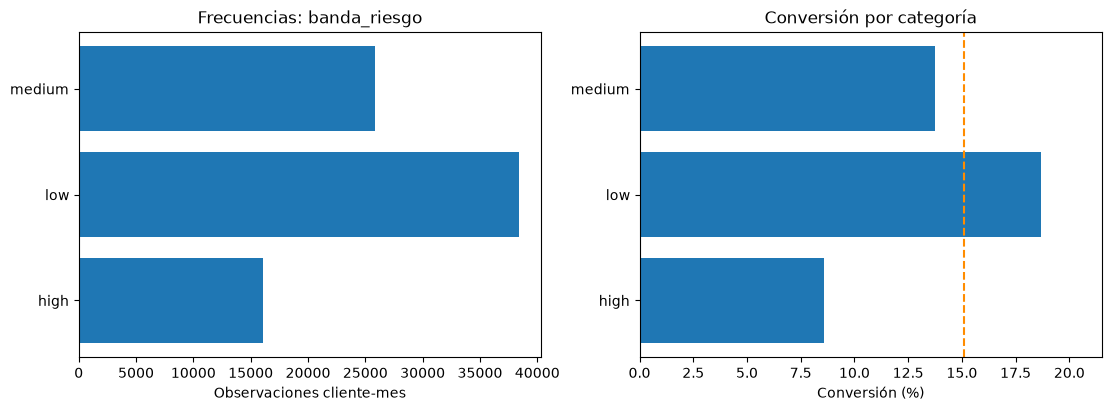

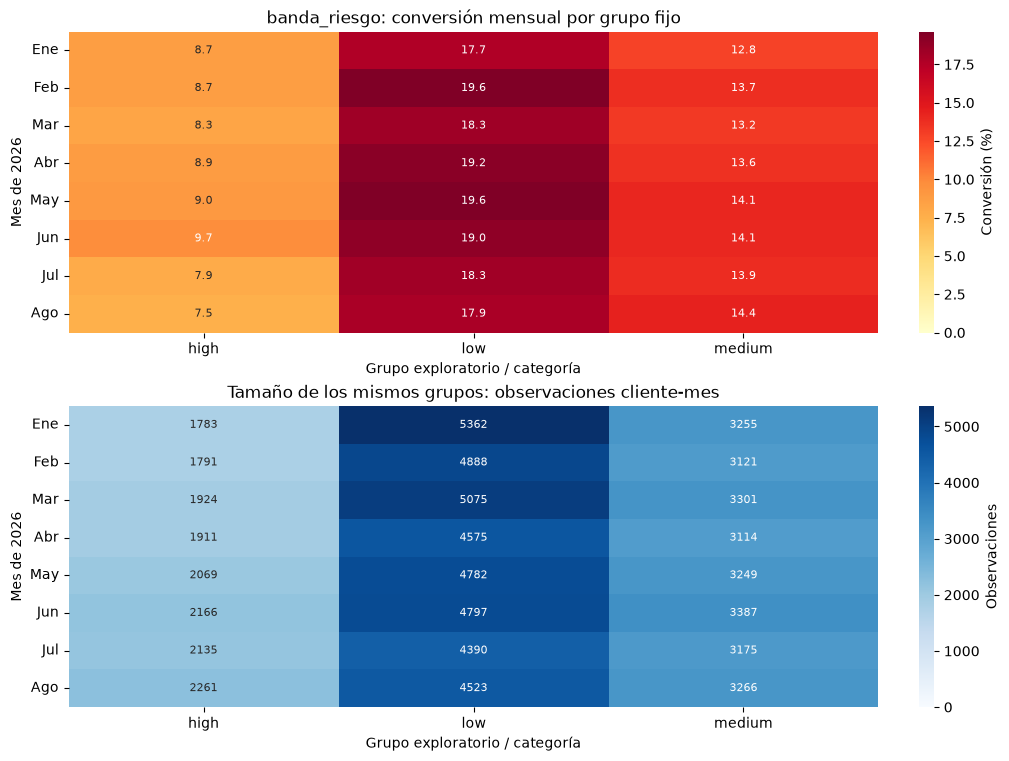

In [49]:
analizar_categorica("banda_riesgo")

### Conclusión exploratoria de `banda_riesgo`

Las bandas reales son `high`, `low` y `medium`, sin nulos ni problemas de formato detectados. `low` concentra 47,81 % del desarrollo, `medium` 32,21 % y `high` 19,98 %. Incluso la banda menor contiene 16.040 filas y 1.783–2.261 por mes.

La conversión es 18,70 % en `low`, 13,74 % en `medium` y 8,57 % en `high`: `low`−`high` equivale a **10,13 puntos porcentuales**. El orden `low` > `medium` > `high` se mantiene en los ocho meses. Sin embargo, la proporción de `low` va de 51,56 % en enero a 45,00 % en agosto (6,55 puntos porcentuales de rango), y la de `high` de 17,14 % a 22,50 % (5,35 puntos). El orden consistente de tasas no implica composición constante.

Se conserva como candidata con una duda documental prioritaria: qué riesgo mide, cómo se calcula, sus umbrales y su fecha de actualización. Debe comprobarse que la banda esté disponible antes del evento y no se derive del objetivo ni de información futura. No se impone una codificación ordinal definitiva.

### Análisis de `dispositivo_principal`

Comparamos las categorías de dispositivo, prestando atención a la categoría menor y a su variación mensual. El bloque consulta metadata, muestra categorías, frecuencias y conversión; revisa inconsistencias sin corregirlas y compara tasas y tamaños mensuales. Los mapas de calor usan los mismos grupos en los ocho meses; las tablas de estabilidad también muestran cambios de proporción dentro de cada mes.

,21
column_name,dispositivo_principal
description,Dispositivo principal registrado
type,string
notes,Variable categórica


,observaciones,clientes_unicos,conversiones,porcentaje_observaciones,tasa_porcentaje
grupo,,,,,
android,33756,8733,5136,42.037,15.215
ios,25663,6586,3864,31.959,15.057
otro,4587,1209,670,5.712,14.606
web,16294,4180,2437,20.291,14.956


,categoria_original,forma_para_revision,espacios_en_extremos,vacia_tras_strip,colision_de_formas
0,android,android,False,False,False
1,ios,ios,False,False,False
2,otro,otro,False,False,False
3,web,web,False,False,False


Nulos: 0 | No hay catálogo oficial de categorías permitidas en metadata.


grupo,android,ios,otro,web
mes,,,,
202601,14.57,14.56,18.36,13.79
202602,16.06,15.71,15.72,15.16
202603,14.39,14.21,13.78,16.94
202604,15.67,15.50,13.81,14.83
202605,15.46,15.80,16.84,15.63
202606,15.88,15.21,14.75,15.18
202607,14.59,15.36,12.26,13.80
202608,15.15,14.16,11.35,14.22


grupo,android,ios,otro,web
mes,,,,
202601,4387,3311,599,2103
202602,4129,3119,547,2005
202603,4316,3293,566,2125
202604,4040,3096,536,1928
202605,4229,3260,570,2041
202606,4358,3320,590,2082
202607,4058,3093,571,1978
202608,4239,3171,608,2032


,observaciones_mes_min,observaciones_mes_max,tasa_mes_min_pct,tasa_mes_max_pct,rango_tasa_pp,proporcion_mes_min_pct,proporcion_mes_max_pct,rango_proporcion_pp
grupo,,,,,,,,
android,4040,4387,14.388,16.057,1.669,41.835,42.183,0.348
ios,3093,3320,14.160,15.798,1.638,31.552,32.277,0.725
otro,536,608,11.349,18.364,7.015,5.495,6.050,0.555
web,1928,2125,13.790,16.941,3.151,20.083,20.631,0.548


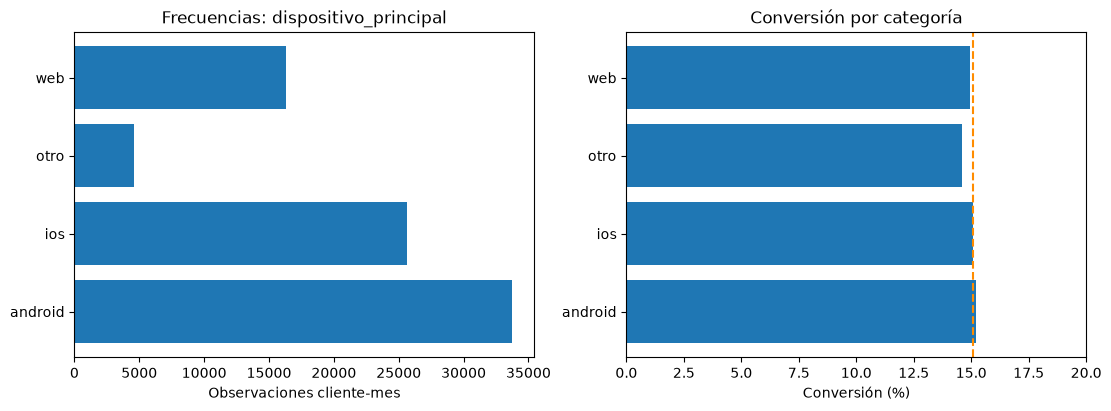

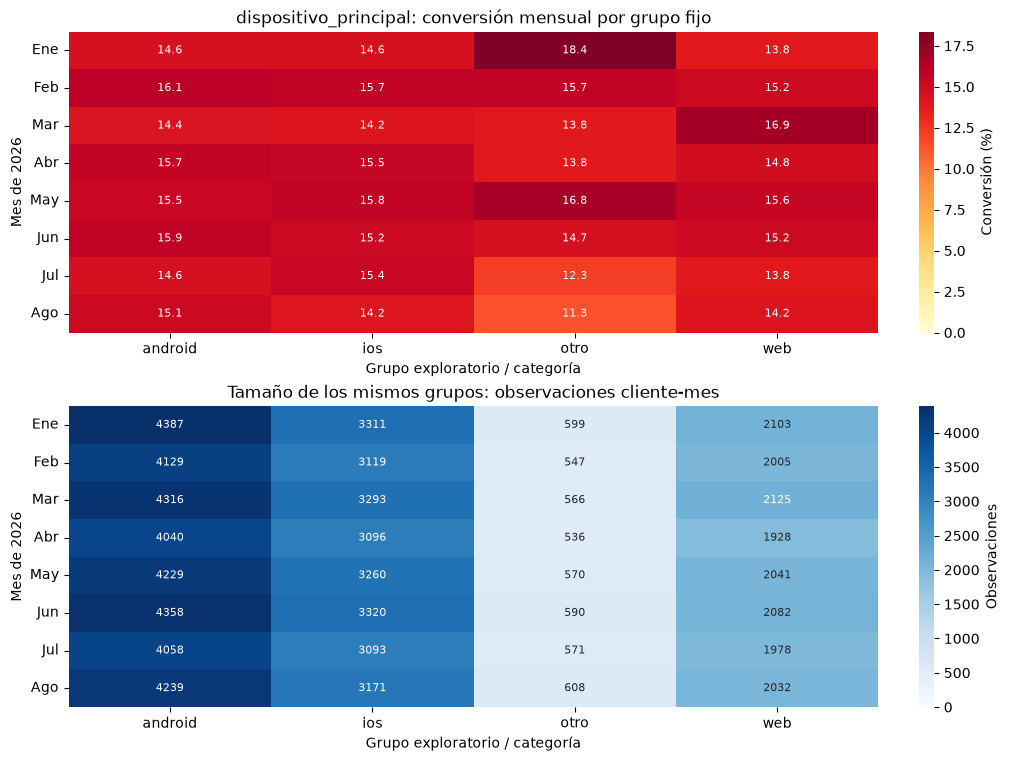

In [50]:
analizar_categorica("dispositivo_principal")

### Conclusión exploratoria de `dispositivo_principal`

Se observan `android`, `ios`, `otro` y `web`, sin nulos ni inconsistencias de formato detectadas. Android e iOS suman 74,00 % de las observaciones; `otro` tiene 4.587 filas (5,71 %), con 536–608 por mes.

La tasa agregada es 15,22 % en `android` y 14,61 % en `otro`: **0,61 puntos porcentuales**. Android supera a otro en seis meses, pero el orden cambia. `otro` oscila de 18,36 % en enero a 11,35 % en agosto (7,02 puntos porcentuales); sus tamaños son menores que los de las plataformas principales. Las proporciones de las categorías varían como máximo 0,73 puntos porcentuales.

Se conservan las cuatro categorías, incluida `otro`. Falta definir cómo se elige el dispositivo principal, el período observado y qué agrupa `otro`; `web` no identifica por sí solo un sistema operativo y requiere aclaración.

### Análisis de `tiene_tarjeta_credito`

Comprobamos booleanos reales y comparamos conversión según tenencia de tarjeta. El bloque consulta metadata, muestra categorías, frecuencias y conversión; revisa inconsistencias sin corregirlas y compara tasas y tamaños mensuales. Los mapas de calor usan los mismos grupos en los ocho meses; las tablas de estabilidad también muestran cambios de proporción dentro de cada mes.

,14
column_name,tiene_tarjeta_credito
description,Indica si el cliente tiene tarjeta de crédito
type,boolean
notes,Flag binaria


,observaciones,clientes_unicos,conversiones,porcentaje_observaciones,tasa_porcentaje
grupo,,,,,
False,20655,5113,2884,25.722,13.963
True,59645,15595,9223,74.278,15.463


,resultado
nulos,0
tipo_pandas,bool
fuera_de_True_False,0
valores_no_booleanos_reales,0


grupo,False,True
mes,,
202601,12.86,15.21
202602,14.05,16.31
202603,13.19,15.39
202604,13.61,15.96
202605,14.91,15.95
202606,14.88,15.67
202607,13.65,14.85
202608,14.50,14.39


grupo,False,True
mes,,
202601,2590,7810
202602,2462,7338
202603,2646,7654
202604,2499,7101
202605,2622,7478
202606,2709,7641
202607,2520,7180
202608,2607,7443


,observaciones_mes_min,observaciones_mes_max,tasa_mes_min_pct,tasa_mes_max_pct,rango_tasa_pp,proporcion_mes_min_pct,proporcion_mes_max_pct,rango_proporcion_pp
grupo,,,,,,,,
False,2462,2709,12.857,14.912,2.055,24.904,26.174,1.27
True,7101,7810,14.389,16.312,1.923,73.826,75.096,1.27


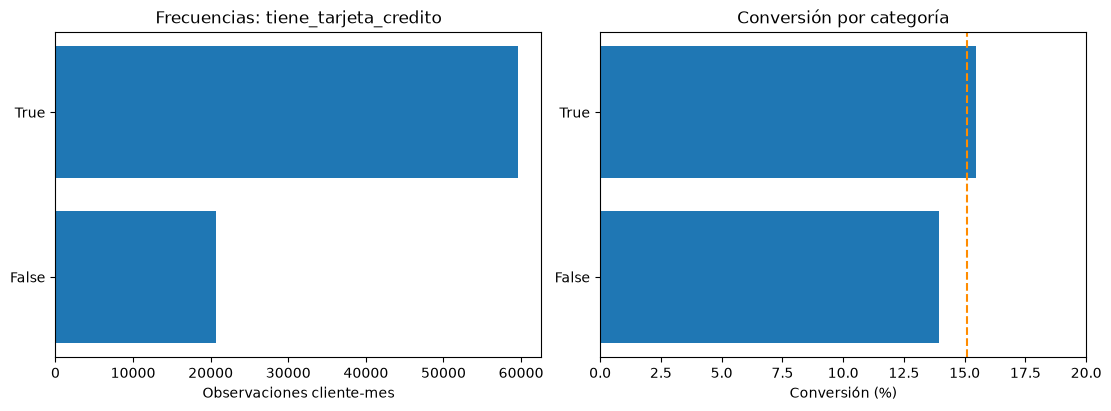

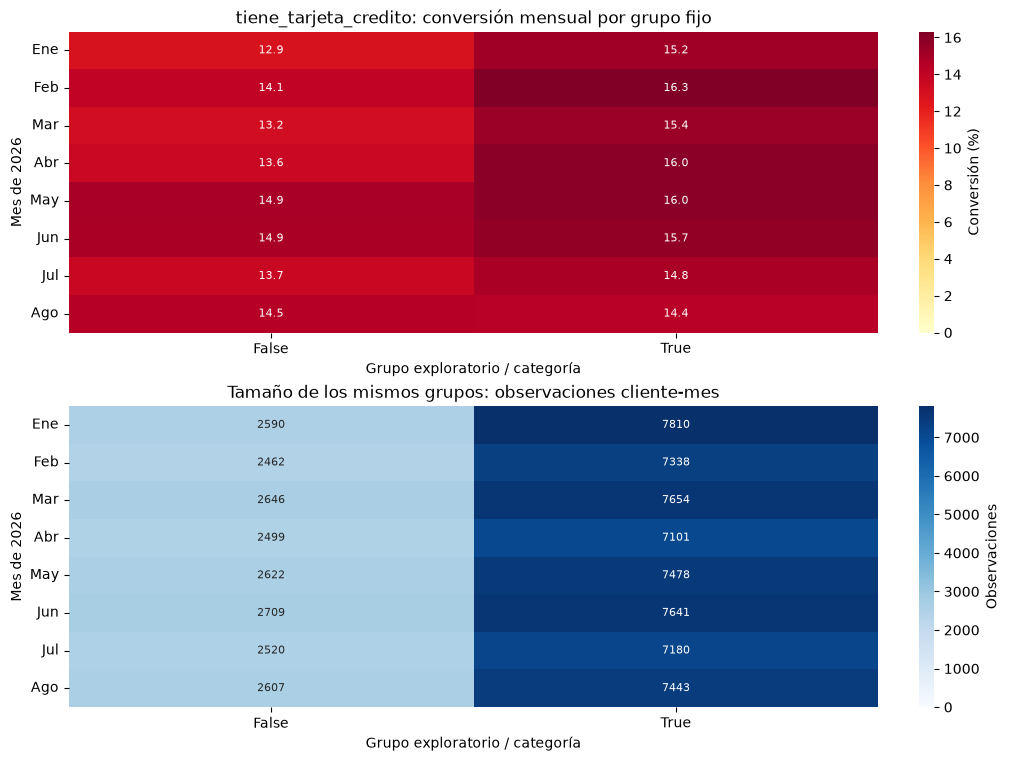

In [51]:
analizar_categorica("tiene_tarjeta_credito")

### Conclusión exploratoria de `tiene_tarjeta_credito`

Los únicos valores son booleanos reales `False` y `True`, sin nulos ni valores ajenos. True reúne 59.645 filas (74,28 %) y False 20.655 (25,72 %); el grupo menor tiene 2.462–2.709 observaciones mensuales.

Con tarjeta se registra 15,46 % de conversión frente a 13,96 % sin tarjeta: **1,50 puntos porcentuales**. True supera a False en siete meses; en agosto las tasas se invierten levemente (14,39 % frente a 14,50 %). La proporción True oscila entre 73,83 % y 75,10 %, un rango de 1,27 puntos.

Se conserva el indicador original, sin atribuir un efecto causal a la tenencia. Falta aclarar si la tarjeta debe estar activa o solo contratada y comprobar el estado anterior al evento; también debe definirse la conversión para descartar que coincida con el alta del propio producto.

### Análisis de `activo_movil`

Comparamos actividad móvil, proporciones y tasas por mes, dejando pendiente la definición de actividad. El bloque consulta metadata, muestra categorías, frecuencias y conversión; revisa inconsistencias sin corregirlas y compara tasas y tamaños mensuales. Los mapas de calor usan los mismos grupos en los ocho meses; las tablas de estabilidad también muestran cambios de proporción dentro de cada mes.

,15
column_name,activo_movil
description,Indica si el cliente está activo en la app móvil
type,boolean
notes,Flag binaria


,observaciones,clientes_unicos,conversiones,porcentaje_observaciones,tasa_porcentaje
grupo,,,,,
False,27380,6758,3696,34.097,13.499
True,52920,13950,8411,65.903,15.894


,resultado
nulos,0
tipo_pandas,bool
fuera_de_True_False,0
valores_no_booleanos_reales,0


grupo,False,True
mes,,
202601,12.51,15.63
202602,13.77,16.72
202603,13.11,15.70
202604,13.68,16.21
202605,13.62,16.77
202606,14.63,15.91
202607,14.31,14.66
202608,12.31,15.54


grupo,False,True
mes,,
202601,3342,7058
202602,3246,6554
202603,3470,6830
202604,3275,6325
202605,3487,6613
202606,3643,6707
202607,3425,6275
202608,3492,6558


,observaciones_mes_min,observaciones_mes_max,tasa_mes_min_pct,tasa_mes_max_pct,rango_tasa_pp,proporcion_mes_min_pct,proporcion_mes_max_pct,rango_proporcion_pp
grupo,,,,,,,,
False,3246,3643,12.314,14.631,2.317,32.135,35.309,3.175
True,6275,7058,14.661,16.770,2.109,64.691,67.865,3.175


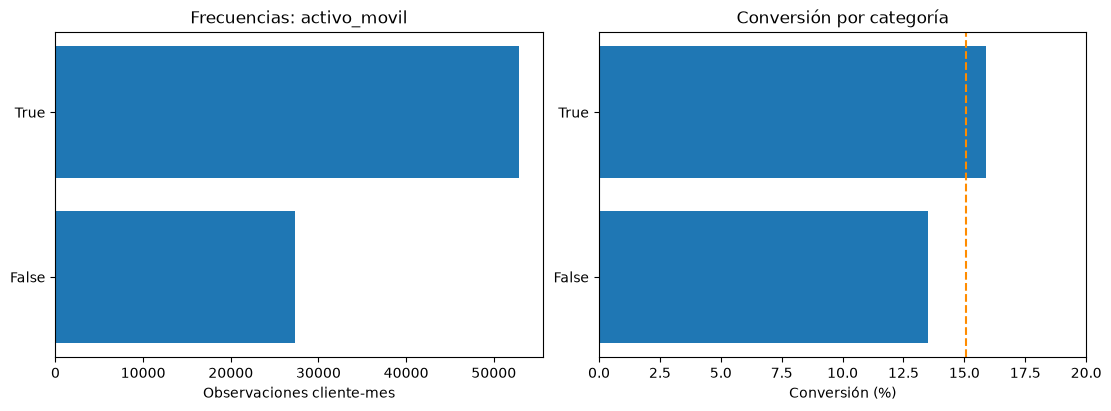

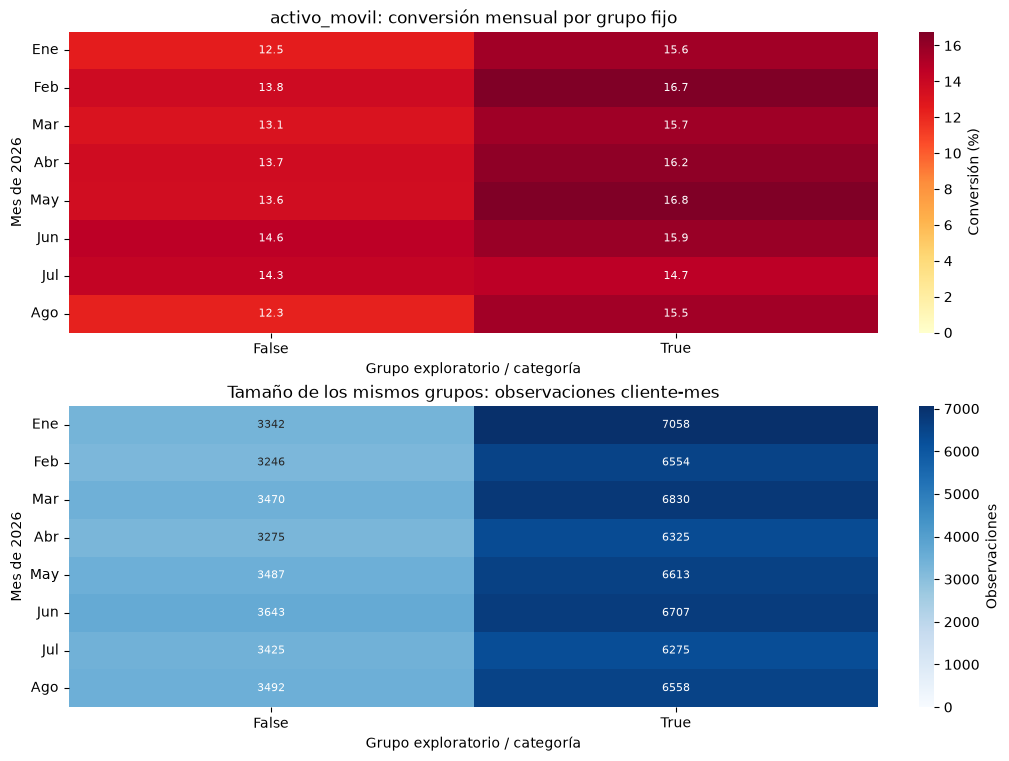

In [52]:
analizar_categorica("activo_movil")

### Conclusión exploratoria de `activo_movil`

La variable contiene únicamente True y False reales, sin nulos ni inconsistencias. True agrupa 52.920 observaciones (65,90 %) y False 27.380 (34,10 %); este último tiene 3.246–3.643 filas mensuales.

La conversión es 15,89 % con actividad móvil y 13,50 % sin ella: **2,39 puntos porcentuales**, calculados sin redondear previamente. True supera a False en los ocho meses, pero la brecha es menor en julio (14,66 % frente a 14,31 %). La proporción True va de 64,69 % a 67,87 % (3,18 puntos porcentuales).

Se conserva como candidata. Falta definir qué actividad y ventana convierten a un cliente en activo, si hay retraso de actualización y si el indicador se calcula antes de la conversión. El patrón no establece que activar la app cause conversión.

### Análisis de `es_nuevo_cliente`

Examinamos la bandera de nuevo cliente sin inferir un umbral de antigüedad. El bloque consulta metadata, muestra categorías, frecuencias y conversión; revisa inconsistencias sin corregirlas y compara tasas y tamaños mensuales. Los mapas de calor usan los mismos grupos en los ocho meses; las tablas de estabilidad también muestran cambios de proporción dentro de cada mes.

,16
column_name,es_nuevo_cliente
description,Indica si el cliente es nuevo
type,boolean
notes,Flag binaria


,observaciones,clientes_unicos,conversiones,porcentaje_observaciones,tasa_porcentaje
grupo,,,,,
False,64892,16755,9834,80.812,15.154
True,15408,3953,2273,19.188,14.752


,resultado
nulos,0
tipo_pandas,bool
fuera_de_True_False,0
valores_no_booleanos_reales,0


grupo,False,True
mes,,
202601,14.69,14.35
202602,15.81,15.46
202603,14.82,14.84
202604,15.67,13.96
202605,15.69,15.66
202606,15.52,15.21
202607,14.53,14.56
202608,14.53,13.93


grupo,False,True
mes,,
202601,8442,1958
202602,7950,1850
202603,8339,1961
202604,7781,1819
202605,8133,1967
202606,8331,2019
202607,7818,1882
202608,8098,1952


,observaciones_mes_min,observaciones_mes_max,tasa_mes_min_pct,tasa_mes_max_pct,rango_tasa_pp,proporcion_mes_min_pct,proporcion_mes_max_pct,rango_proporcion_pp
grupo,,,,,,,,
False,7781,8442,14.531,15.811,1.281,80.493,81.173,0.68
True,1819,2019,13.934,15.658,1.724,18.827,19.507,0.68


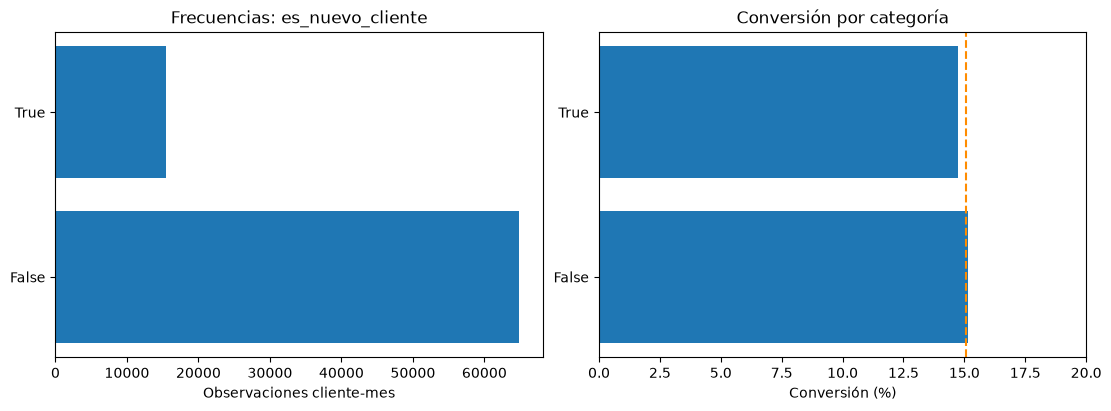

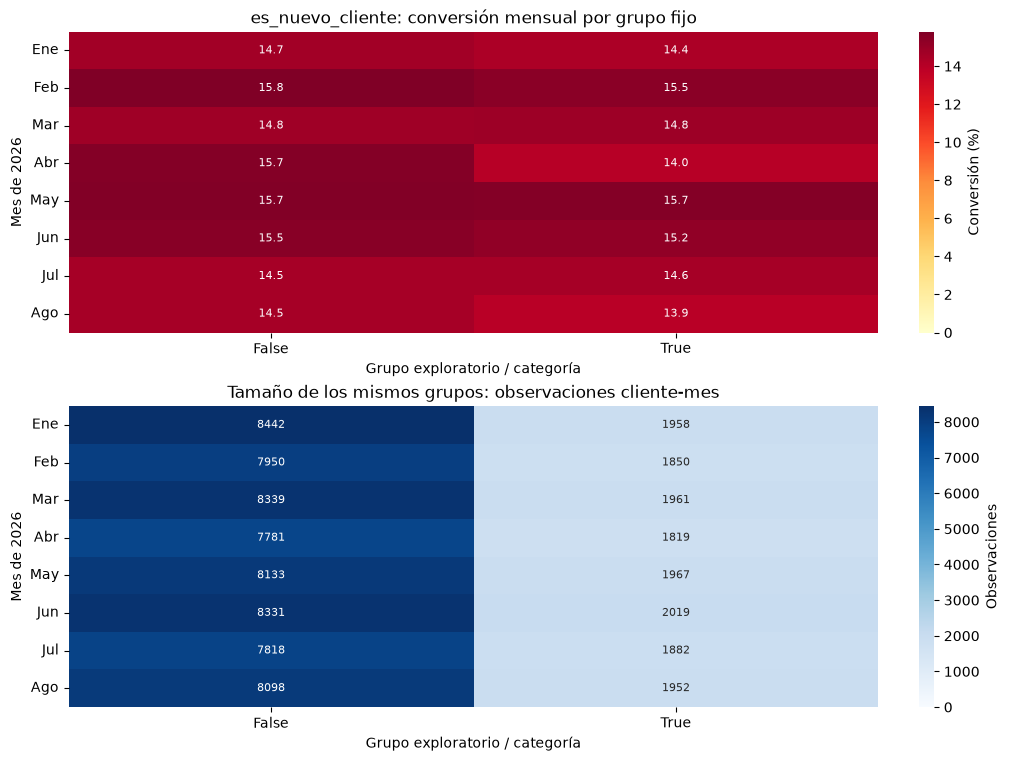

In [53]:
analizar_categorica("es_nuevo_cliente")

### Conclusión exploratoria de `es_nuevo_cliente`

Hay solo True y False reales, sin nulos ni valores inconsistentes. True aparece en 15.408 filas (19,19 %) y False en 64.892; el grupo True tiene 1.819–2.019 filas por mes.

Los nuevos tienen 14,75 % de conversión frente a 15,15 % de los no nuevos: **0,40 puntos porcentuales menos**. False supera a True en seis meses, con inversiones pequeñas en marzo y julio. La proporción de nuevos se mueve entre 18,83 % y 19,51 % (0,68 puntos), y su tasa mensual entre 13,93 % y 15,66 %.

Se conserva la bandera. No se deduce un umbral de antigüedad ni se sustituye por antigüedad de cuenta. Falta definir qué significa nuevo, cuánto dura ese estado y su fecha de cálculo; la posible relación semántica con antigüedad se deberá comprobar documentalmente.

### Análisis de `tiene_prestamo`

Comparamos la bandera de préstamo activo y comprobamos si el orden de tasas se mantiene mes a mes. El bloque consulta metadata, muestra categorías, frecuencias y conversión; revisa inconsistencias sin corregirlas y compara tasas y tamaños mensuales. Los mapas de calor usan los mismos grupos en los ocho meses; las tablas de estabilidad también muestran cambios de proporción dentro de cada mes.

,17
column_name,tiene_prestamo
description,Indica si el cliente tiene un préstamo activo
type,boolean
notes,Flag binaria


,observaciones,clientes_unicos,conversiones,porcentaje_observaciones,tasa_porcentaje
grupo,,,,,
False,44634,11517,6778,55.584,15.186
True,35666,9191,5329,44.416,14.941


,resultado
nulos,0
tipo_pandas,bool
fuera_de_True_False,0
valores_no_booleanos_reales,0


grupo,False,True
mes,,
202601,15.13,13.98
202602,15.03,16.65
202603,14.91,14.72
202604,15.90,14.65
202605,15.61,15.77
202606,15.44,15.49
202607,15.02,13.93
202608,14.47,14.35


grupo,False,True
mes,,
202601,5837,4563
202602,5457,4343
202603,5776,4524
202604,5346,4254
202605,5585,4515
202606,5720,4630
202607,5372,4328
202608,5541,4509


,observaciones_mes_min,observaciones_mes_max,tasa_mes_min_pct,tasa_mes_max_pct,rango_tasa_pp,proporcion_mes_min_pct,proporcion_mes_max_pct,rango_proporcion_pp
grupo,,,,,,,,
False,5346,5837,14.474,15.900,1.426,55.134,56.125,0.991
True,4254,4630,13.933,16.647,2.715,43.875,44.866,0.991


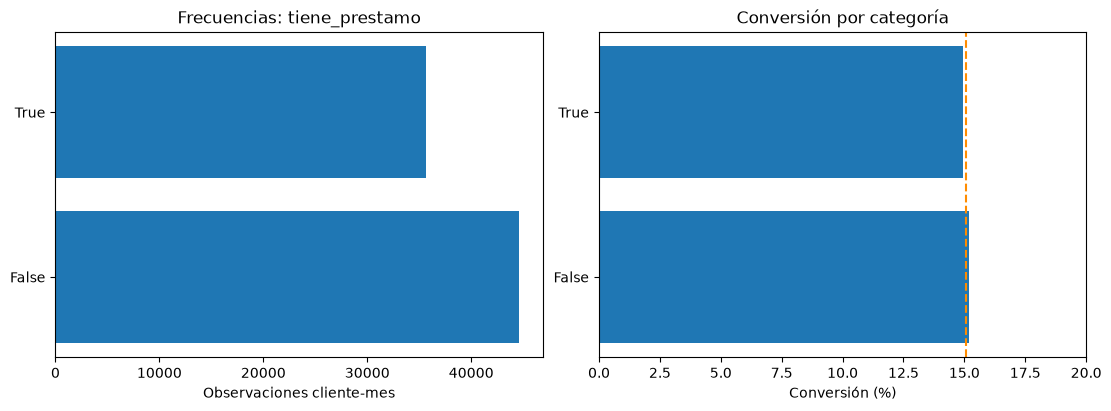

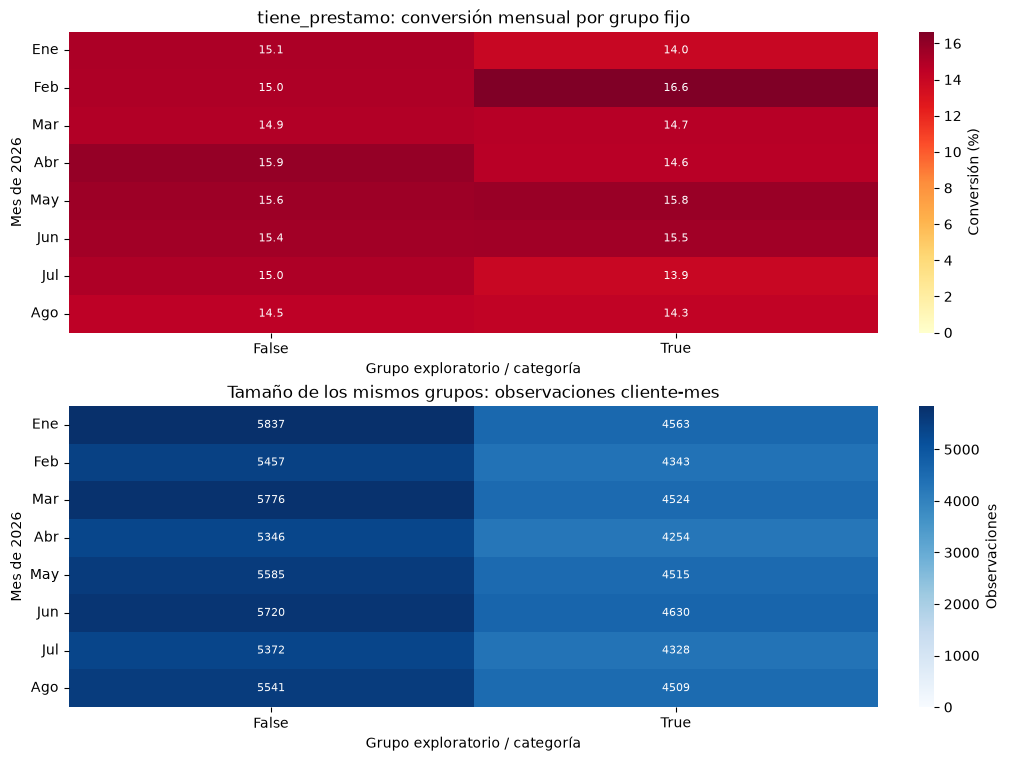

In [54]:
analizar_categorica("tiene_prestamo")

### Conclusión exploratoria de `tiene_prestamo`

Se observan únicamente booleanos reales, sin nulos ni valores ajenos. True concentra 35.666 filas (44,42 %) y False 44.634; el grupo True tiene 4.254–4.630 observaciones mensuales.

La conversión es 14,94 % con préstamo y 15,19 % sin él: **0,24 puntos porcentuales menos** al calcular la diferencia sin redondear tasas. False supera a True en cinco meses; febrero, mayo y junio invierten el orden. Las tasas de True van de 13,93 % a 16,65 %, mientras su proporción mensual va de 43,87 % a 44,87 % (0,99 puntos de rango).

Se conserva el indicador sin concluir ausencia de utilidad predictiva por la diferencia agregada pequeña. Falta precisar qué préstamos están incluidos, cómo se define activo, el instante del estado y si la conversión puede ser la contratación de ese mismo producto.

### Análisis de `tiene_seguro`

Comparamos tenencia de seguro, tamaños y tasas, incluso cuando la diferencia agregada es pequeña. El bloque consulta metadata, muestra categorías, frecuencias y conversión; revisa inconsistencias sin corregirlas y compara tasas y tamaños mensuales. Los mapas de calor usan los mismos grupos en los ocho meses; las tablas de estabilidad también muestran cambios de proporción dentro de cada mes.

,23
column_name,tiene_seguro
description,Indica si el cliente tiene un seguro contratado
type,boolean
notes,Flag binaria


,observaciones,clientes_unicos,conversiones,porcentaje_observaciones,tasa_porcentaje
grupo,,,,,
False,49584,12789,7496,61.748,15.118
True,30716,7919,4611,38.252,15.012


,resultado
nulos,0
tipo_pandas,bool
fuera_de_True_False,0
valores_no_booleanos_reales,0


grupo,False,True
mes,,
202601,14.57,14.71
202602,15.91,15.47
202603,14.39,15.54
202604,15.24,15.52
202605,16.35,14.60
202606,15.88,14.79
202607,14.27,14.96
202608,14.33,14.57


grupo,False,True
mes,,
202601,6430,3970
202602,6070,3730
202603,6381,3919
202604,5972,3628
202605,6244,3856
202606,6380,3970
202607,5929,3771
202608,6178,3872


,observaciones_mes_min,observaciones_mes_max,tasa_mes_min_pct,tasa_mes_max_pct,rango_tasa_pp,proporcion_mes_min_pct,proporcion_mes_max_pct,rango_proporcion_pp
grupo,,,,,,,,
False,5929,6430,14.269,16.352,2.083,61.124,62.208,1.085
True,3628,3970,14.566,15.540,0.974,37.792,38.876,1.085


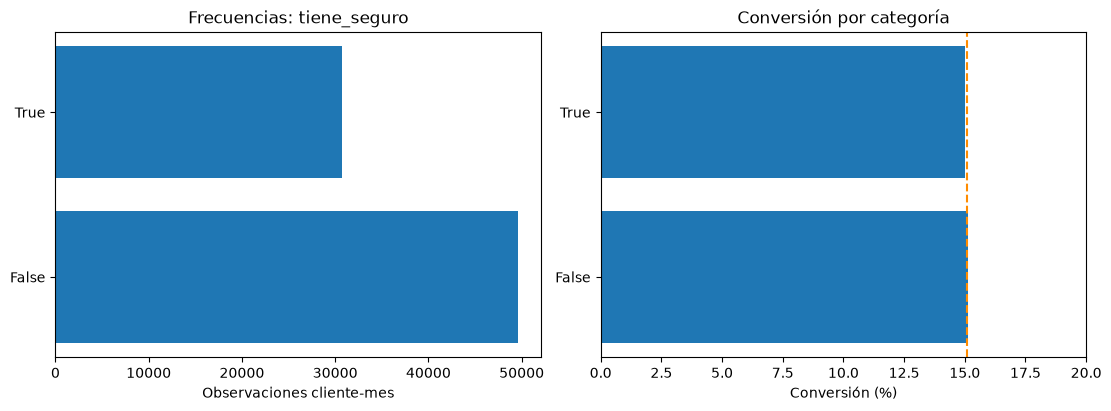

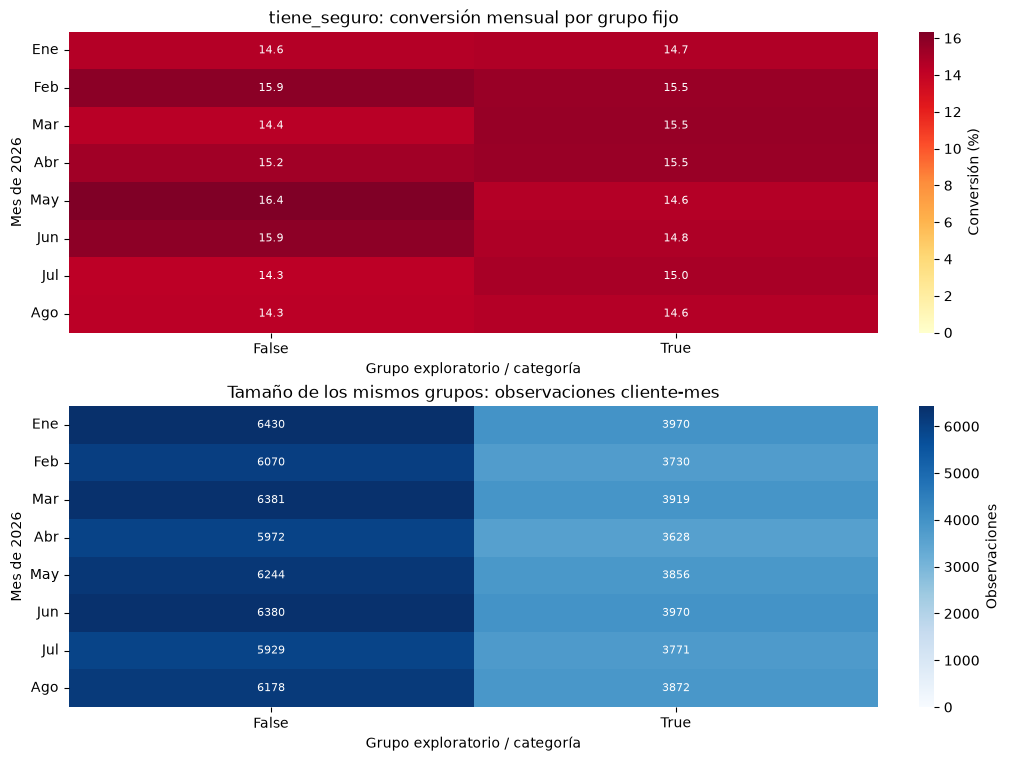

In [55]:
analizar_categorica("tiene_seguro")

### Conclusión exploratoria de `tiene_seguro`

Los valores son True y False reales y no hay nulos ni inconsistencias. True reúne 30.716 filas (38,25 %) y False 49.584; el grupo True tiene 3.628–3.970 observaciones por mes.

Las tasas son 15,01 % con seguro y 15,12 % sin seguro, una diferencia de **0,11 puntos porcentuales**. A pesar de esa diferencia agregada, True supera a False en cinco meses. La tasa mensual de True varía entre 14,57 % y 15,54 %, mientras la de False entre 14,27 % y 16,35 %; las proporciones cambian como máximo 1,09 puntos porcentuales.

Se conserva la bandera: la proximidad de tasas no prueba redundancia ni falta de aporte condicional. Falta documentar qué seguros incluye, si la tenencia exige vigencia, la fecha del estado y su relación con el evento de conversión.

### Relaciones entre predictores numéricos

Calculamos **Spearman** para describir asociaciones monotónicas mediante rangos y **Pearson** como complemento para relaciones lineales. Se incluyen las 12 variables numéricas y se excluyen `id_cliente`, `mes` y `objetivo`, así como las booleanas y categóricas. Los empates se manejan mediante rangos promedio en Spearman.

Estas correlaciones se calculan sobre observaciones cliente-mes de enero–agosto, no sobre clientes independientes. No se calculan p-valores ni se infiere significancia. La ausencia de correlación lineal o monotónica no descarta relaciones no lineales, interacciones ni redundancia entre una numérica y una categoría. El día de pago es discreto: su correlación por rangos describe el código diario y no prueba una geometría temporal o cíclica.

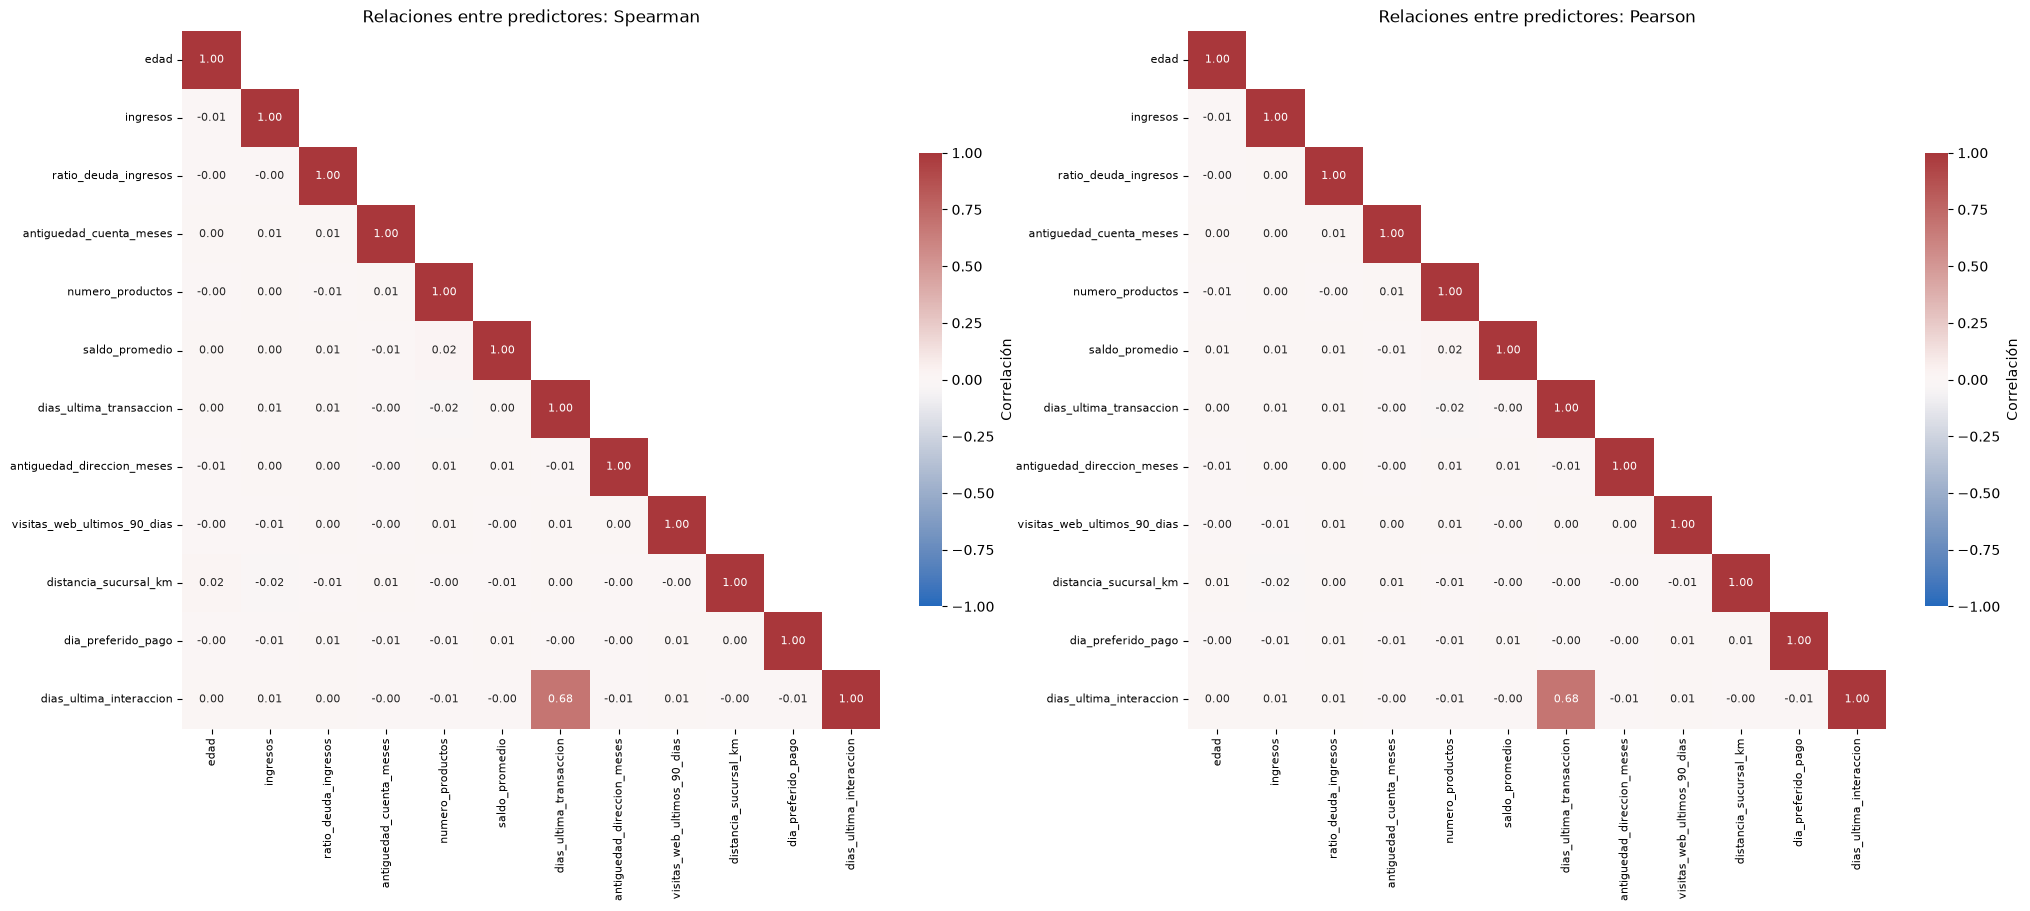

,variable_1,variable_2,spearman,pearson,abs_spearman
55,dias_ultima_transaccion,dias_ultima_interaccion,0.6844,0.6845,0.6844
38,numero_productos,saldo_promedio,0.0247,0.0200,0.0247
18,ingresos,distancia_sucursal_km,-0.0174,-0.0219,0.0174
8,edad,distancia_sucursal_km,0.0169,0.0115,0.0169
39,numero_productos,dias_ultima_transaccion,-0.0169,-0.0160,0.0169
44,numero_productos,dias_ultima_interaccion,-0.0147,-0.0134,0.0147
21,ratio_deuda_ingresos,antiguedad_cuenta_meses,0.0136,0.0136,0.0136
51,dias_ultima_transaccion,antiguedad_direccion_meses,-0.0131,-0.0129,0.0131
61,visitas_web_ultimos_90_dias,dia_preferido_pago,0.0131,0.0103,0.0131
30,antiguedad_cuenta_meses,numero_productos,0.0120,0.0121,0.0120


,observaciones,valores_iguales,porcentaje_iguales,spearman
mes,,,,
202601,10400,10400,100.0000,1.0000
202602,9800,8912,90.9388,0.9068
202603,10300,8435,81.8932,0.8077
202604,9600,6991,72.8229,0.7313
202605,10100,6433,63.6931,0.6387
202606,10350,5659,54.6763,0.5585
202607,9700,4429,45.6598,0.4460
202608,10050,3672,36.5373,0.3670


Coincidencias en el desarrollo: 54931
Máximo |Spearman| de los otros pares: 0.02472530522718215


In [56]:
correlacion_spearman = desarrollo[numericas_eda].corr(method="spearman")
correlacion_pearson = desarrollo[numericas_eda].corr(method="pearson")
assert list(correlacion_spearman.columns) == numericas_eda
fig, axes = plt.subplots(1, 2, figsize=(20, 9), constrained_layout=True)
mascara = np.triu(np.ones((len(numericas_eda), len(numericas_eda)), dtype=bool), k=1)
for ax, matriz, titulo in zip(axes, [correlacion_spearman, correlacion_pearson], ["Spearman", "Pearson"]):
    sns.heatmap(matriz, mask=mascara, annot=True, fmt=".2f", vmin=-1, vmax=1,
                center=0, cmap="vlag", square=True, ax=ax, annot_kws={"size": 8},
                cbar_kws={"shrink": .65, "label": "Correlación"})
    ax.set_title(f"Relaciones entre predictores: {titulo}")
    ax.tick_params(axis="x", rotation=90, labelsize=8)
    ax.tick_params(axis="y", rotation=0, labelsize=8)
plt.show()
pares_correlacion = pd.DataFrame([
    {"variable_1": a, "variable_2": b,
     "spearman": correlacion_spearman.loc[a, b],
     "pearson": correlacion_pearson.loc[a, b]}
    for i, a in enumerate(numericas_eda) for b in numericas_eda[i + 1:]
])
pares_correlacion["abs_spearman"] = pares_correlacion["spearman"].abs()
pares_correlacion = pares_correlacion.sort_values("abs_spearman", ascending=False)
display(pares_correlacion.head(10).round(4))

# Revisar la coincidencia y su evolución usando solo el desarrollo.
filas_recencia = []
for mes, bloque in desarrollo.groupby("mes"):
    iguales = bloque["dias_ultima_transaccion"].eq(bloque["dias_ultima_interaccion"])
    filas_recencia.append({
        "mes": mes, "observaciones": len(bloque), "valores_iguales": iguales.sum(),
        "porcentaje_iguales": iguales.mean() * 100,
        "spearman": bloque[["dias_ultima_transaccion", "dias_ultima_interaccion"]].corr(method="spearman").iloc[0, 1],
    })
revision_recencias = pd.DataFrame(filas_recencia).set_index("mes")
display(revision_recencias.round(4))
print("Coincidencias en el desarrollo:", desarrollo["dias_ultima_transaccion"].eq(desarrollo["dias_ultima_interaccion"]).sum())
print("Máximo |Spearman| de los otros pares:", pares_correlacion.iloc[1:]["abs_spearman"].max())

### Posibles redundancias y dudas de origen

La relación más alta corresponde a `dias_ultima_transaccion` y `dias_ultima_interaccion`: **Spearman 0,6844 y Pearson 0,6845**. Coinciden exactamente en **54.931 de 80.300 filas (68,41 %)**. En enero las dos columnas son idénticas y Spearman es 1; la correlación disminuye hasta 0,3670 en agosto. Esta evolución requiere confirmar cómo se generan o actualizan ambas medidas. No se explica como un comportamiento del cliente sin evidencia adicional.

Se mantienen ambas candidatas: hay solapamiento, pero no duplicación total en todo el desarrollo. En fases posteriores se deberá comparar su aporte conjunto y separado bajo los cortes temporales ya definidos, una vez aclaradas su procedencia y disponibilidad. La correlación por sí sola no autoriza descartarlas.

El mayor |Spearman| entre los demás pares es aproximadamente 0,0247 (`numero_productos` y `saldo_promedio`); no se observa redundancia monotónica fuerte entre esas otras numéricas. Esto no descarta dependencias no lineales ni relaciones semánticas como `es_nuevo_cliente` con antigüedad de cuenta, o tenencias de productos con `numero_productos`, que no están representadas en esta matriz.

### Resumen de las 22 variables predictoras

La tabla integra los hallazgos específicos con medidas calculadas de tamaños y variación mensual. **pp** significa puntos porcentuales. No se ordenan variables por importancia predictiva ni se descartan por diferencias pequeñas. Todas las decisiones son provisionales y condicionadas a confirmar la disponibilidad anterior al evento. Las dudas de cada fila se suman a esa comprobación común y a la definición exacta de conversión.

En la versión guardada, el resumen se ejecutó como In[54] y la verificación como In[55], mientras el registro complementario de saldo se ejecutó después, como In[74]. Al reconstruir las llamadas anteriores al resumen faltaba únicamente `saldo_promedio`: había 21 registros y ninguna clave adicional. Las tablas de saldo por sí solas no añadían esa entrada. Ahora el cierre completa los registros reales faltantes y comprueba que saldo coincida con sus grupos y tablas originales; no elimina las verificaciones.


In [57]:
from IPython.display import HTML, display

hallazgos_eda = {'edad': '22–71; tasas por grupo 14,42–15,33 %; diferencia extrema 0,92 pp.', 'ingresos': 'Mínimo 18.000 en 1,63 %; diferencia Q5−Q1 0,53 pp.', 'ratio_deuda_ingresos': '0,02–0,95; Q1 supera Q5 por 1,33 pp.', 'antiguedad_cuenta_meses': '1–179 meses; >120 lidera agregado; amplitud 1,20 pp.', 'numero_productos': '1–5; 74,28 % con 1–2; diferencia 5−1 de 8,89 pp.', 'saldo_promedio': '300–90.000; 6,84 % en 300; amplitud Q5−Q2 de 1,21 pp.', 'dias_ultima_transaccion': '1–364 días; diferencia Q1−Q5 de 5,52 pp.', 'antiguedad_direccion_meses': '1–239 meses; amplitud 0,46 pp; sin gradiente creciente.', 'visitas_web_ultimos_90_dias': '0–21; 78,97 % en 5–11; extremos con pocos clientes.', 'distancia_sucursal_km': '0,2125–80 km; 111 filas en 80; amplitud 0,81 pp.', 'dia_preferido_pago': '1–28; sin 29–31; amplitud agregada 2,81 pp.', 'dias_ultima_interaccion': '1–364 días; diferencia Q1−Q5 de 4,08 pp; solapamiento con transacción.', 'ocupacion': '5 categorías; self_employed−manager 1,50 pp.', 'region': '5 categorías; east−central 0,60 pp; geografía sin especificar.', 'canal_adquisicion': '5 categorías; call_center−branch 1,26 pp.', 'banda_riesgo': '3 bandas; low−high 10,13 pp; composición cambiante.', 'dispositivo_principal': '4 categorías; otro 5,71 %; android−otro 0,61 pp.', 'tiene_tarjeta_credito': 'True 74,28 %; diferencia True−False 1,50 pp.', 'activo_movil': 'True 65,90 %; diferencia True−False 2,39 pp.', 'es_nuevo_cliente': 'True 19,19 %; diferencia False−True 0,40 pp.', 'tiene_prestamo': 'True 44,42 %; diferencia False−True 0,24 pp.', 'tiene_seguro': 'True 38,25 %; diferencia False−True 0,11 pp.'}
lectura_mensual_eda = {'edad': 'Orden de tasas cambia.', 'ingresos': 'Orden cambia; Q5>Q1 en 6/8.', 'ratio_deuda_ingresos': 'Q1>Q5 en 8/8; Q5 mínimo en 6/8.', 'antiguedad_cuenta_meses': '>120 lidera en 4/8.', 'numero_productos': '3–5 supera 1–2 en 8/8; cambia composición.', 'saldo_promedio': 'Q5 lidera en 6/8; orden completo cambia.', 'dias_ultima_transaccion': 'Q1>Q5 en 8/8; no siempre orden completo.', 'antiguedad_direccion_meses': 'Q2>Q4 en 6/8; líderes cambian.', 'visitas_web_ultimos_90_dias': 'Tasas extremas fluctuantes; valor 20 ausente en 3 meses.', 'distancia_sucursal_km': 'Q2>Q3 en 7/8; líderes cambian.', 'dia_preferido_pago': 'Líder diario cambia; día 1>22 en 6/8.', 'dias_ultima_interaccion': 'Q1>Q5 en 8/8; relación con transacción cambia.', 'ocupacion': 'self_employed>manager en 7/8.', 'region': 'east>central en 6/8; líderes cambian.', 'canal_adquisicion': 'call_center>branch en 7/8; inversión en marzo.', 'banda_riesgo': 'low>medium>high en 8/8; proporciones cambian.', 'dispositivo_principal': 'android>otro en 6/8; otro oscila 11,35–18,36 %.', 'tiene_tarjeta_credito': 'True>False en 7/8; inversión en agosto.', 'activo_movil': 'True>False en 8/8; brecha menor en julio.', 'es_nuevo_cliente': 'False>True en 6/8; inversiones leves.', 'tiene_prestamo': 'False>True en 5/8; signo cambia.', 'tiene_seguro': 'True>False en 5/8; signo cambia.'}
dudas_eda = {'edad': 'Unidad, fecha de medición y actualización.', 'ingresos': 'Moneda, definición anual, actualización y mínimo.', 'ratio_deuda_ingresos': 'Componentes y horizonte del ratio.', 'antiguedad_cuenta_meses': 'Inicio del cómputo y corte.', 'numero_productos': 'Catálogo de productos y criterio de activo.', 'saldo_promedio': 'Moneda, período del promedio y posible piso en 300.', 'dias_ultima_transaccion': 'Transacciones incluidas y fecha de referencia.', 'antiguedad_direccion_meses': 'Residencia, registro o última actualización.', 'visitas_web_ultimos_90_dias': 'Definición de visita/sesión y cierre de ventana.', 'distancia_sucursal_km': 'Método de distancia, sucursales y posible tope en 80.', 'dia_preferido_pago': 'Origen de preferencia y ausencia de 29–31.', 'dias_ultima_interaccion': 'Canales/eventos incluidos y origen de coincidencias.', 'ocupacion': 'Catálogo y definición de las cinco ocupaciones.', 'region': 'Definición geográfica y fuente.', 'canal_adquisicion': 'Evento de adquisición y atribución; partner.', 'banda_riesgo': 'Riesgo, cálculo, umbrales y posible información futura.', 'dispositivo_principal': 'Ventana y criterio de principal; otro y web.', 'tiene_tarjeta_credito': 'Tenencia vs. actividad y relación con objetivo.', 'activo_movil': 'Actividad, ventana y retraso de actualización.', 'es_nuevo_cliente': 'Umbral de nuevo y duración del estado.', 'tiene_prestamo': 'Préstamos incluidos, criterio activo y relación con objetivo.', 'tiene_seguro': 'Seguros incluidos, vigencia y relación con objetivo.'}
decisiones_eda = {'edad': 'Conservar candidata sin transformación definitiva.', 'ingresos': 'Conservar candidata sin transformación definitiva.', 'ratio_deuda_ingresos': 'Conservar candidata sin transformación definitiva.', 'antiguedad_cuenta_meses': 'Conservar candidata sin transformación definitiva.', 'numero_productos': 'Conservar conteo; no convertir grupos EDA en entradas.', 'saldo_promedio': 'Conservar candidata sin transformación definitiva.', 'dias_ultima_transaccion': 'Conservar; revisar aporte conjunto con interacción.', 'antiguedad_direccion_meses': 'Conservar candidata sin transformación definitiva.', 'visitas_web_ultimos_90_dias': 'Conservar conteo y extremos; no agrupar automáticamente.', 'distancia_sucursal_km': 'Conservar candidata sin transformación definitiva.', 'dia_preferido_pago': 'Conservar; evaluar representación en fase posterior.', 'dias_ultima_interaccion': 'Conservar; revisar origen y aporte con transacción.', 'ocupacion': 'Conservar candidata sin transformación definitiva.', 'region': 'Conservar candidata sin transformación definitiva.', 'canal_adquisicion': 'Conservar candidata sin transformación definitiva.', 'banda_riesgo': 'Conservar candidata; aclarar cálculo antes de modelar.', 'dispositivo_principal': 'Conservar cuatro categorías, incluida otro.', 'tiene_tarjeta_credito': 'Conservar candidata sin transformación definitiva.', 'activo_movil': 'Conservar candidata sin transformación definitiva.', 'es_nuevo_cliente': 'Conservar candidata sin transformación definitiva.', 'tiene_prestamo': 'Conservar candidata sin transformación definitiva.', 'tiene_seguro': 'Conservar candidata sin transformación definitiva.'}
# Completar entradas faltantes a partir de los grupos y datos reales.
completar_registros_eda()

filas_resumen_eda = []
for variable in predictores_eda:
    r = analisis_eda[variable]
    estabilidad = r["estabilidad"]
    lectura = lectura_mensual_eda[variable]
    lectura += f" Rango máx. proporción: {estabilidad['rango_proporcion_pp'].max():.2f} pp; rango máx. tasa: {estabilidad['rango_tasa_pp'].max():.2f} pp."
    filas_resumen_eda.append({
        "variable": variable,
        "tipo": "Numérica" if variable in numericas_eda else "Categórica" if variable in categoricas_eda else "Booleana",
        "hallazgos_principales": hallazgos_eda[variable],
        "estabilidad_mensual": lectura,
        "menor_grupo_mes": int(r["conteos"].min().min()),
        "decision_provisional": decisiones_eda[variable],
        "dudas_pendientes": dudas_eda[variable] + " Confirmar disponibilidad antes de predecir.",
    })
resumen_fase4 = pd.DataFrame(filas_resumen_eda)
assert len(resumen_fase4) == 22
estilo_resumen = "<style>.resumen-fase4 td, .resumen-fase4 th {white-space:normal; text-align:left; min-width:110px; max-width:260px; padding:7px; vertical-align:top;} .resumen-fase4 {border-collapse:collapse;}</style>"
display(HTML(estilo_resumen + resumen_fase4.to_html(index=False, classes="resumen-fase4", escape=True)))

Variables ausentes antes de completar: []
Variables adicionales: []
Registro completo: 22 variables; grupos y resultados de saldo conservados.


variable,tipo,hallazgos_principales,estabilidad_mensual,menor_grupo_mes,decision_provisional,dudas_pendientes
edad,Numérica,"22–71; tasas por grupo 14,42–15,33 %; diferencia extrema 0,92 pp.",Orden de tasas cambia. Rango máx. proporción: 0.76 pp; rango máx. tasa: 2.86 pp.,1565,Conservar candidata sin transformación definitiva.,"Unidad, fecha de medición y actualización. Confirmar disponibilidad antes de predecir."
ingresos,Numérica,"Mínimo 18.000 en 1,63 %; diferencia Q5−Q1 0,53 pp.",Orden cambia; Q5>Q1 en 6/8. Rango máx. proporción: 0.70 pp; rango máx. tasa: 3.20 pp.,1901,Conservar candidata sin transformación definitiva.,"Moneda, definición anual, actualización y mínimo. Confirmar disponibilidad antes de predecir."
ratio_deuda_ingresos,Numérica,"0,02–0,95; Q1 supera Q5 por 1,33 pp.",Q1>Q5 en 8/8; Q5 mínimo en 6/8. Rango máx. proporción: 1.36 pp; rango máx. tasa: 3.94 pp.,1882,Conservar candidata sin transformación definitiva.,Componentes y horizonte del ratio. Confirmar disponibilidad antes de predecir.
antiguedad_cuenta_meses,Numérica,"1–179 meses; >120 lidera agregado; amplitud 1,20 pp.",>120 lidera en 4/8. Rango máx. proporción: 0.96 pp; rango máx. tasa: 3.94 pp.,664,Conservar candidata sin transformación definitiva.,Inicio del cómputo y corte. Confirmar disponibilidad antes de predecir.
numero_productos,Numérica,"1–5; 74,28 % con 1–2; diferencia 5−1 de 8,89 pp.",3–5 supera 1–2 en 8/8; cambia composición. Rango máx. proporción: 4.87 pp; rango máx. tasa: 8.57 pp.,300,Conservar conteo; no convertir grupos EDA en entradas.,Catálogo de productos y criterio de activo. Confirmar disponibilidad antes de predecir.
saldo_promedio,Numérica,"300–90.000; 6,84 % en 300; amplitud Q5−Q2 de 1,21 pp.",Q5 lidera en 6/8; orden completo cambia. Rango máx. proporción: 0.68 pp; rango máx. tasa: 2.78 pp.,1905,Conservar candidata sin transformación definitiva.,"Moneda, período del promedio y posible piso en 300. Confirmar disponibilidad antes de predecir."
dias_ultima_transaccion,Numérica,"1–364 días; diferencia Q1−Q5 de 5,52 pp.",Q1>Q5 en 8/8; no siempre orden completo. Rango máx. proporción: 2.10 pp; rango máx. tasa: 3.26 pp.,1865,Conservar; revisar aporte conjunto con interacción.,Transacciones incluidas y fecha de referencia. Confirmar disponibilidad antes de predecir.
antiguedad_direccion_meses,Numérica,"1–239 meses; amplitud 0,46 pp; sin gradiente creciente.",Q2>Q4 en 6/8; líderes cambian. Rango máx. proporción: 0.73 pp; rango máx. tasa: 3.25 pp.,1869,Conservar candidata sin transformación definitiva.,"Residencia, registro o última actualización. Confirmar disponibilidad antes de predecir."
visitas_web_ultimos_90_dias,Numérica,"0–21; 78,97 % en 5–11; extremos con pocos clientes.",Tasas extremas fluctuantes; valor 20 ausente en 3 meses. Rango máx. proporción: 0.93 pp; rango máx. tasa: 100.00 pp.,0,Conservar conteo y extremos; no agrupar automáticamente.,Definición de visita/sesión y cierre de ventana. Confirmar disponibilidad antes de predecir.
distancia_sucursal_km,Numérica,"0,2125–80 km; 111 filas en 80; amplitud 0,81 pp.",Q2>Q3 en 7/8; líderes cambian. Rango máx. proporción: 0.91 pp; rango máx. tasa: 3.62 pp.,1907,Conservar candidata sin transformación definitiva.,"Método de distancia, sucursales y posible tope en 80. Confirmar disponibilidad antes de predecir."


### Conclusión general de la fase 4

El EDA queda circunscrito a **80.300 observaciones cliente-mes de 20.708 clientes**, de enero a agosto de 2026, con **15,08 % de positivos**. Las 22 variables tienen secciones y conclusiones; no se detectan nulos en el desarrollo ni inconsistencias de formato en las categorías y booleanas revisadas. Las concentraciones en mínimos, el máximo de distancia y la ausencia de días 29–31 quedan documentadas, sin corregirse por su apariencia.

Los contrastes descriptivos más marcados son banda de riesgo (10,13 pp entre low y high), número de productos (8,89 pp entre cinco y uno), recencia de transacción (5,52 pp entre el primer y último grupo) y recencia de interacción (4,08 pp). También hay una diferencia de 2,39 pp asociada a actividad móvil. Sus comparaciones extremas conservan el signo en los ocho meses, aunque el orden de todos los grupos no siempre se mantiene y la composición de riesgo, productos y actividad móvil cambia. Esto constituye evidencia exploratoria para evaluar, no una clasificación definitiva de importancia.

En edad, ingresos, antigüedades, saldo, distancia y varias categorías o banderas, las diferencias agregadas son menores o los órdenes mensuales cambian. No se descartan: las relaciones condicionales y no lineales no se determinan mediante tablas univariadas. En visitas web, tasas extremas como 0 % o 100 % corresponden a muy pocas filas y a clientes repetidos; no se usan para elegir cortes o eliminar valores.

La redundancia entre las dos recencias merece atención: son idénticas en enero y su correlación decrece a lo largo del desarrollo. Antes del modelado debe aclararse su origen, además de la definición exacta de conversión, las monedas, ventanas, fechas de corte, catálogos y disponibilidad temporal de todos los predictores. La salida de clientes tras la primera conversión, descrita en metadata, también puede cambiar la composición mensual; no se adjudican los cambios a una causa sin evaluarla.

Las conclusiones son descriptivas y ponderan observaciones, no personas únicas. No se han demostrado causalidad, significancia estadística ni capacidad predictiva incremental. No se aplican imputación, escalado, codificación definitiva, balanceo, recorte, selección automática, entrenamiento o entrega de predicciones.

En las siguientes fases se deberán resolver las dudas de disponibilidad, construir la preparación que corresponda y evaluar cada hipótesis con los cortes enero–agosto→septiembre, enero–septiembre→octubre y enero–octubre→noviembre. Las transformaciones que aprendan de datos se ajustarán dentro de cada entrenamiento. Los meses posteriores no han intervenido en los grupos, transformaciones exploratorias ni decisiones de esta fase.

### Verificación de cobertura y alcance

Comprobamos que cada predictor esté registrado, que todas las tablas utilicen el mismo desarrollo y que conteos y conversiones reconciliados correspondan al total original. También verificamos que las agrupaciones previas se mantengan. La ejecución completa y los archivos originales se comprueban adicionalmente desde un kernel limpio y mediante hashes, fuera del repositorio.

Antes de los assert se comprueban y completan los registros faltantes con datos de enero–agosto. Se mantienen los assert de cobertura y reconciliación y se verifica también la igualdad exacta de la serie de grupos de saldo.


In [58]:
completar_registros_eda()

assert set(analisis_eda) == set(predictores_eda)
assert set(resumen_fase4["variable"]) == set(predictores_eda)
assert desarrollo.shape == (80300, 25)
assert desarrollo["id_cliente"].nunique() == 20708
assert desarrollo["objetivo"].sum() == 12107
assert set(desarrollo["mes"]) == set(range(202601, 202609))
for variable, r in analisis_eda.items():
    assert r["conversion"]["observaciones"].sum() == 80300
    assert r["conversion"]["conversiones"].sum() == 12107
    assert list(r["tasas"].index) == meses_eda
    assert r["conteos"].sum(axis=1).eq(objetivo_por_mes["observaciones"]).all()
    assert r["conversiones"].sum(axis=1).eq(objetivo_por_mes["conversiones"]).all()
for variable, serie_previa in [
    ("edad", edades["grupo_edad"]),
    ("ingresos", ingresos_eda["grupo_ingresos"]),
    ("ratio_deuda_ingresos", ratio_eda["grupo_ratio"]),
    ("antiguedad_cuenta_meses", antiguedad_eda["grupo_antiguedad"]),
    ("saldo_promedio", saldo_eda["grupo_saldo"]),
]:
    assert analisis_eda[variable]["grupo"].cat.codes.equals(serie_previa.cat.codes)
pd.testing.assert_series_equal(analisis_eda["saldo_promedio"]["grupo"], saldo_eda["grupo_saldo"])
print("Ausentes finales:", sorted(set(predictores_eda) - set(analisis_eda)))
print("Adicionales finales:", sorted(set(analisis_eda) - set(predictores_eda)))
print("Cobertura: 22 predictores = 12 numéricas + 5 categóricas + 5 booleanas.")
print("EDA: enero–agosto de 2026; grupos previos conservados; conteos y conversiones reconciliados.")
print("No se entrenaron modelos ni se generaron predicciones.")
print("Intérprete de ejecución:", sys.executable)

Variables ausentes antes de completar: []
Variables adicionales: []
Registro completo: 22 variables; grupos y resultados de saldo conservados.
Ausentes finales: []
Adicionales finales: []
Cobertura: 22 predictores = 12 numéricas + 5 categóricas + 5 booleanas.
EDA: enero–agosto de 2026; grupos previos conservados; conteos y conversiones reconciliados.
No se entrenaron modelos ni se generaron predicciones.
Intérprete de ejecución: C:\Users\Laptop de la familia\Datathon-BCP\.venv\Scripts\python.exe
